# Website Traffic Có Chuyển Thành Doanh Thu Không?

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

traffic_path = Path("data/interim/web_traffic.csv")
sales_path = Path("data/interim/sales.csv")
orders_path = Path("data/interim/orders.csv")

if not traffic_path.exists():
    traffic_path = Path("..") / traffic_path
    sales_path = Path("..") / sales_path
    orders_path = Path("..") / orders_path

traffic = pd.read_csv(traffic_path)
sales = pd.read_csv(sales_path)
orders = pd.read_csv(orders_path, usecols=["order_date", "order_status"])

traffic["date"] = pd.to_datetime(traffic["date"])
sales["Date"] = pd.to_datetime(sales["Date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])

valid_statuses = ["paid", "shipped", "delivered", "returned"]
valid_orders = orders[orders["order_status"].isin(valid_statuses)].copy()

monthly_traffic = (
    traffic
    .assign(month=traffic["date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        avg_bounce_rate=("bounce_rate", "mean")
    )
)

monthly_sales = (
    sales
    .assign(month=sales["Date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(revenue=("Revenue", "sum"), cogs=("COGS", "sum"))
)

monthly_orders = (
    valid_orders
    .assign(month=valid_orders["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(valid_orders=("order_status", "count"))
)

traffic_sales = (
    monthly_traffic
    .merge(monthly_sales, on="month", how="inner", validate="one_to_one")
    .merge(monthly_orders, on="month", how="left", validate="one_to_one")
)

traffic_sales["valid_orders"] = traffic_sales["valid_orders"].fillna(0)
traffic_sales["conversion_rate"] = traffic_sales["valid_orders"] / traffic_sales["sessions"] * 100
traffic_sales["revenue_per_session"] = traffic_sales["revenue"] / traffic_sales["sessions"]
traffic_sales["profit"] = traffic_sales["revenue"] - traffic_sales["cogs"]

traffic_sales[["month", "sessions", "valid_orders", "conversion_rate", "revenue", "revenue_per_session"]].head()


,month,sessions,valid_orders,conversion_rate,revenue,revenue_per_session
0,2013-01-01,295006,3297,1.117604,9.130868e+07,309.514644
1,2013-02-01,416896,4169,1.000010,1.097831e+08,263.334592
2,2013-03-01,622174,5902,0.948609,1.518347e+08,244.038898
3,2013-04-01,814380,7935,0.974361,1.989269e+08,244.267949
4,2013-05-01,816540,7472,0.915081,2.005001e+08,245.548423


## Chart 1: Tăng trưởng doanh thu đến từ traffic hay conversion?

Biểu đồ này so sánh 3 chỉ số theo tháng: doanh thu, số phiên truy cập và tỷ lệ chuyển đổi (`valid_orders / sessions`).
Các chỉ số được chuẩn hóa về dạng index, với tháng đầu tiên bằng 100, để so sánh xu hướng trên cùng một trục.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

traffic_path = Path("data/interim/web_traffic.csv")
sales_path = Path("data/interim/sales.csv")
orders_path = Path("data/interim/orders.csv")

if not traffic_path.exists():
    traffic_path = Path("..") / traffic_path
    sales_path = Path("..") / sales_path
    orders_path = Path("..") / orders_path

traffic = pd.read_csv(traffic_path, usecols=["date", "sessions"])
sales = pd.read_csv(sales_path, usecols=["Date", "Revenue"])
orders = pd.read_csv(orders_path, usecols=["order_date", "order_status"])

traffic["date"] = pd.to_datetime(traffic["date"])
sales["Date"] = pd.to_datetime(sales["Date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])

valid_statuses = ["paid", "shipped", "delivered", "returned"]
valid_orders = orders[orders["order_status"].isin(valid_statuses)].copy()

monthly_traffic = (
    traffic
    .assign(month=traffic["date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(sessions=("sessions", "sum"))
)

monthly_revenue = (
    sales
    .assign(month=sales["Date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(revenue=("Revenue", "sum"))
)

monthly_orders = (
    valid_orders
    .assign(month=valid_orders["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(valid_orders=("order_status", "count"))
)

traffic_conversion = (
    monthly_revenue
    .merge(monthly_traffic, on="month", how="inner", validate="one_to_one")
    .merge(monthly_orders, on="month", how="left", validate="one_to_one")
)

traffic_conversion["valid_orders"] = traffic_conversion["valid_orders"].fillna(0)
traffic_conversion["conversion_rate"] = traffic_conversion["valid_orders"] / traffic_conversion["sessions"] * 100
traffic_conversion["revenue_index"] = traffic_conversion["revenue"] / traffic_conversion["revenue"].iloc[0] * 100
traffic_conversion["sessions_index"] = traffic_conversion["sessions"] / traffic_conversion["sessions"].iloc[0] * 100
traffic_conversion["conversion_index"] = traffic_conversion["conversion_rate"] / traffic_conversion["conversion_rate"].iloc[0] * 100

traffic_conversion.head()


,month,revenue,sessions,valid_orders,conversion_rate,revenue_index,sessions_index,conversion_index
0,2013-01-01,9.130868e+07,295006,3297,1.117604,100.000000,100.000000,100.000000
1,2013-02-01,1.097831e+08,416896,4169,1.000010,120.232974,141.317804,89.477959
2,2013-03-01,1.518347e+08,622174,5902,0.948609,166.287216,210.902151,84.878803
3,2013-04-01,1.989269e+08,814380,7935,0.974361,217.862024,276.055402,87.182985
4,2013-05-01,2.005001e+08,816540,7472,0.915081,219.584946,276.787591,81.878768


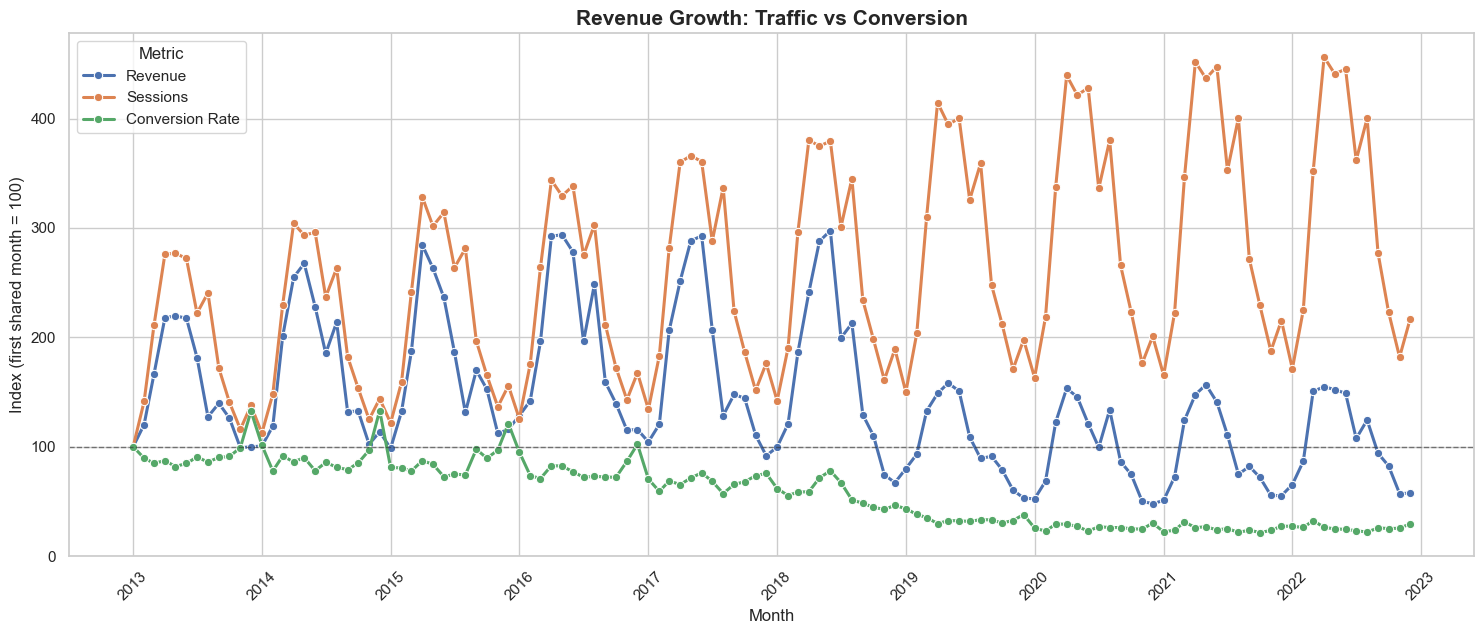

,month,revenue,sessions,valid_orders,conversion_rate
108,2022-01-01,5.966349e+07,505009,1534,0.303757
109,2022-02-01,7.910310e+07,663620,1940,0.292336
110,2022-03-01,1.375379e+08,1037755,3750,0.361357
111,2022-04-01,1.413055e+08,1345666,3961,0.294352
112,2022-05-01,1.390279e+08,1300613,3606,0.277254
113,2022-06-01,1.358124e+08,1313081,3585,0.273022
114,2022-07-01,9.814178e+07,1067671,2761,0.258600
115,2022-08-01,1.135429e+08,1180206,2899,0.245635
116,2022-09-01,8.576429e+07,816742,2346,0.287239
117,2022-10-01,7.519445e+07,657381,1850,0.281420


In [13]:
plot_df = traffic_conversion.melt(
    id_vars="month",
    value_vars=["revenue_index", "sessions_index", "conversion_index"],
    var_name="metric",
    value_name="index_value"
)

metric_labels = {
    "revenue_index": "Revenue",
    "sessions_index": "Sessions",
    "conversion_index": "Conversion Rate"
}
plot_df["metric"] = plot_df["metric"].map(metric_labels)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6.5))
sns.lineplot(
    data=plot_df,
    x="month",
    y="index_value",
    hue="metric",
    marker="o",
    linewidth=2.2
)

plt.axhline(100, color="#333333", linewidth=1, linestyle="--", alpha=0.6)
plt.title("Revenue Growth: Traffic vs Conversion", fontsize=15, weight="bold")
plt.xlabel("Month")
plt.ylabel("Index (first shared month = 100)")
plt.legend(title="Metric")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

traffic_conversion[["month", "revenue", "sessions", "valid_orders", "conversion_rate"]].tail(12)


## Chart 2-3: Traffic và doanh thu theo kênh

Mục tiêu là so sánh từng kênh để tìm ra kênh mang lại nhiều traffic nhưng không tạo ra doanh thu tương xứng.
Traffic được lấy từ `web_traffic.traffic_source`, còn doanh thu được lấy theo `master_table.order_source`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

traffic_path = Path("data/interim/web_traffic.csv")
master_path = Path("data/output/master_table.csv")

if not traffic_path.exists():
    traffic_path = Path("..") / traffic_path
    master_path = Path("..") / master_path

traffic = pd.read_csv(
    traffic_path,
    usecols=["traffic_source", "sessions", "unique_visitors", "page_views", "bounce_rate"]
)

master = pd.read_csv(
    master_path,
    usecols=["order_item_id", "order_source", "line_revenue", "refund_amount", "order_status"]
)

master = master.drop_duplicates(subset=["order_item_id"]).copy()
master["refund_amount"] = master["refund_amount"].fillna(0)
master["net_revenue"] = master["line_revenue"] - master["refund_amount"]

valid_statuses = ["paid", "shipped", "delivered", "returned"]
master = master[master["order_status"].isin(valid_statuses)].copy()

traffic_by_channel = (
    traffic
    .groupby("traffic_source", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        avg_bounce_rate=("bounce_rate", "mean")
    )
    .rename(columns={"traffic_source": "channel"})
)

revenue_by_channel = (
    master
    .groupby("order_source", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        gross_revenue=("line_revenue", "sum"),
        valid_order_items=("order_item_id", "nunique")
    )
    .rename(columns={"order_source": "channel"})
)

channel_summary = (
    traffic_by_channel
    .merge(revenue_by_channel, on="channel", how="outer", validate="one_to_one")
    .fillna(0)
)

channel_summary["traffic_share_pct"] = channel_summary["sessions"] / channel_summary["sessions"].sum() * 100
channel_summary["revenue_share_pct"] = channel_summary["net_revenue"] / channel_summary["net_revenue"].sum() * 100
channel_summary["revenue_per_session"] = channel_summary["net_revenue"] / channel_summary["sessions"].replace(0, pd.NA)
channel_summary["share_gap_pct_point"] = channel_summary["traffic_share_pct"] - channel_summary["revenue_share_pct"]

channel_summary = channel_summary.sort_values("share_gap_pct_point", ascending=False)
channel_summary


,channel,sessions,unique_visitors,page_views,avg_bounce_rate,net_revenue,gross_revenue,valid_order_items,traffic_share_pct,revenue_share_pct,revenue_per_session,share_gap_pct_point
1,email_campaign,12792670,9700462,55477636,0.004458,1.623846e+09,1.687051e+09,77005,13.988316,11.991876,126.935695,1.996440
2,organic_search,27196976,20625107,117606452,0.004504,3.786820e+09,3.931137e+09,179741,29.738897,27.965133,139.236820,1.773764
4,referral,9476845,7220019,41655659,0.004499,1.352324e+09,1.403314e+09,63883,10.362583,9.986723,142.697732,0.375859
3,paid_search,19598271,14922386,85079551,0.004478,2.976735e+09,3.087465e+09,140417,21.429992,21.982768,151.887643,-0.552777
0,direct,6571549,4986650,28771362,0.004511,1.086723e+09,1.127695e+09,51365,7.185748,8.025295,165.367842,-0.839546
5,social_media,15816226,12048065,68072140,0.004476,2.714772e+09,2.815157e+09,128576,17.294464,20.048204,171.644717,-2.753740


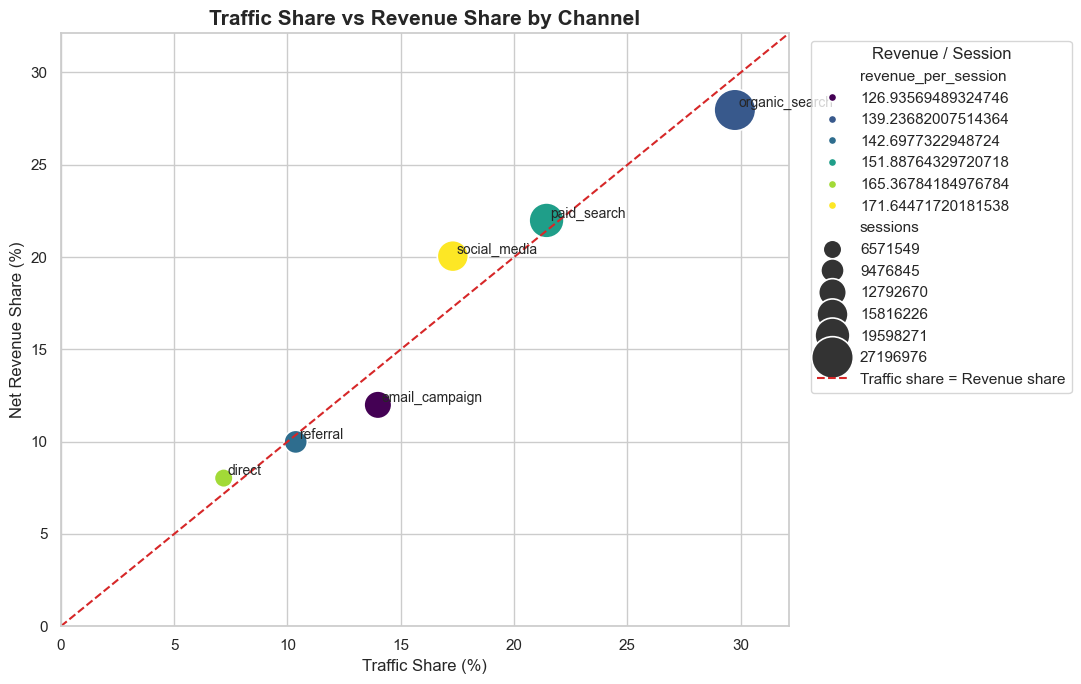

,channel,sessions,traffic_share_pct,net_revenue,revenue_share_pct,revenue_per_session,share_gap_pct_point
2,organic_search,27196976,29.738897,3.786820e+09,27.965133,139.236820,1.773764
3,paid_search,19598271,21.429992,2.976735e+09,21.982768,151.887643,-0.552777
5,social_media,15816226,17.294464,2.714772e+09,20.048204,171.644717,-2.753740
1,email_campaign,12792670,13.988316,1.623846e+09,11.991876,126.935695,1.996440
4,referral,9476845,10.362583,1.352324e+09,9.986723,142.697732,0.375859
0,direct,6571549,7.185748,1.086723e+09,8.025295,165.367842,-0.839546


In [ ]:
plot_df = channel_summary.sort_values("sessions", ascending=False).copy()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=plot_df,
    x="traffic_share_pct",
    y="revenue_share_pct",
    size="sessions",
    hue="revenue_per_session",
    palette="viridis",
    sizes=(180, 900),
    edgecolor="white",
    linewidth=1.2,
    ax=ax
)

limit = max(plot_df["traffic_share_pct"].max(), plot_df["revenue_share_pct"].max()) * 1.08
ax.plot([0, limit], [0, limit], color="#d62728", linestyle="--", linewidth=1.5, label="Traffic share = Revenue share")

for _, row in plot_df.iterrows():
    ax.text(
        row["traffic_share_pct"] + 0.15,
        row["revenue_share_pct"] + 0.15,
        row["channel"],
        fontsize=10
    )

ax.set_title("Traffic Share vs Revenue Share by Channel", fontsize=15, weight="bold")
ax.set_xlabel("Traffic Share (%)")
ax.set_ylabel("Net Revenue Share (%)")
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.legend(title="Revenue / Session", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plot_df[["channel", "sessions", "traffic_share_pct", "net_revenue", "revenue_share_pct", "revenue_per_session", "share_gap_pct_point"]]


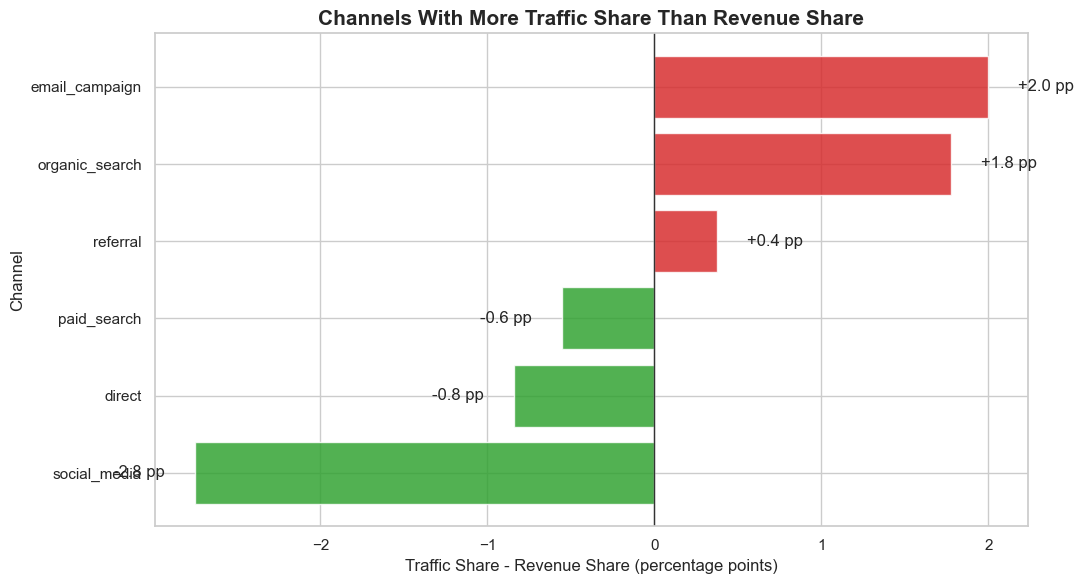

,channel,sessions,unique_visitors,page_views,avg_bounce_rate,net_revenue,gross_revenue,valid_order_items,traffic_share_pct,revenue_share_pct,revenue_per_session,share_gap_pct_point
1,email_campaign,12792670,9700462,55477636,0.004458,1.623846e+09,1.687051e+09,77005,13.988316,11.991876,126.935695,1.996440
2,organic_search,27196976,20625107,117606452,0.004504,3.786820e+09,3.931137e+09,179741,29.738897,27.965133,139.236820,1.773764
4,referral,9476845,7220019,41655659,0.004499,1.352324e+09,1.403314e+09,63883,10.362583,9.986723,142.697732,0.375859
3,paid_search,19598271,14922386,85079551,0.004478,2.976735e+09,3.087465e+09,140417,21.429992,21.982768,151.887643,-0.552777
0,direct,6571549,4986650,28771362,0.004511,1.086723e+09,1.127695e+09,51365,7.185748,8.025295,165.367842,-0.839546
5,social_media,15816226,12048065,68072140,0.004476,2.714772e+09,2.815157e+09,128576,17.294464,20.048204,171.644717,-2.753740


In [ ]:
gap_df = channel_summary.sort_values("share_gap_pct_point", ascending=True).copy()
colors = gap_df["share_gap_pct_point"].map(lambda value: "#d62728" if value > 0 else "#2ca02c")

plt.figure(figsize=(11, 6))
plt.barh(gap_df["channel"], gap_df["share_gap_pct_point"], color=colors, alpha=0.82)
plt.axvline(0, color="#333333", linewidth=1)
plt.title("Channels With More Traffic Share Than Revenue Share", fontsize=15, weight="bold")
plt.xlabel("Traffic Share - Revenue Share (percentage points)")
plt.ylabel("Channel")

for channel, value in zip(gap_df["channel"], gap_df["share_gap_pct_point"]):
    ha = "left" if value >= 0 else "right"
    offset = 0.18 if value >= 0 else -0.18
    plt.text(value + offset, channel, f"{value:+.1f} pp", va="center", ha=ha)

plt.tight_layout()
plt.show()

channel_summary.sort_values("share_gap_pct_point", ascending=False)


**Insight gợi ý:** Kênh nằm dưới đường chéo trong scatter plot hoặc có `share_gap_pct_point` dương lớn là kênh có tỷ trọng traffic cao hơn tỷ trọng doanh thu, tức traffic chưa chuyển thành tiền tương xứng. Nên ưu tiên kiểm tra các kênh này theo bounce rate, landing page, promotion, product mix và conversion funnel.

## Chart 4-5: Hiệu quả chuyển đổi theo kênh

Mục tiêu là xem kênh nào chuyển đổi tốt hoặc tệ bằng cách so sánh `conversion_rate = valid_orders / sessions` theo từng channel. Sessions lấy từ `web_traffic.traffic_source`, đơn hàng lấy từ `orders.order_source`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

traffic_path = Path("data/interim/web_traffic.csv")
orders_path = Path("data/interim/orders.csv")

if not traffic_path.exists():
    traffic_path = Path("..") / traffic_path
    orders_path = Path("..") / orders_path

traffic = pd.read_csv(
    traffic_path,
    usecols=["traffic_source", "sessions", "unique_visitors", "bounce_rate", "avg_session_duration_sec"]
)
orders = pd.read_csv(
    orders_path,
    usecols=["order_id", "order_source", "order_status"]
)

valid_statuses = ["paid", "shipped", "delivered", "returned"]
valid_orders = orders[orders["order_status"].isin(valid_statuses)].copy()

traffic_by_channel = (
    traffic
    .groupby("traffic_source", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        avg_bounce_rate=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean")
    )
    .rename(columns={"traffic_source": "channel"})
)

orders_by_channel = (
    valid_orders
    .groupby("order_source", as_index=False)
    .agg(valid_orders=("order_id", "nunique"))
    .rename(columns={"order_source": "channel"})
)

conversion_efficiency = (
    traffic_by_channel
    .merge(orders_by_channel, on="channel", how="left", validate="one_to_one")
    .fillna({"valid_orders": 0})
)

conversion_efficiency["conversion_rate"] = (
    conversion_efficiency["valid_orders"] / conversion_efficiency["sessions"] * 100
)
conversion_efficiency["orders_per_10k_sessions"] = (
    conversion_efficiency["valid_orders"] / conversion_efficiency["sessions"] * 10_000
)
conversion_efficiency["traffic_share_pct"] = (
    conversion_efficiency["sessions"] / conversion_efficiency["sessions"].sum() * 100
)

conversion_efficiency = conversion_efficiency.sort_values("conversion_rate", ascending=False)
conversion_efficiency


,channel,sessions,unique_visitors,avg_bounce_rate,avg_session_duration_sec,valid_orders,conversion_rate,orders_per_10k_sessions,traffic_share_pct
5,social_media,15816226,12048065,0.004476,210.290190,116397,0.735934,73.593410,17.294464
0,direct,6571549,4986650,0.004511,207.678195,46525,0.707976,70.797616,7.185748
3,paid_search,19598271,14922386,0.004478,209.362117,127114,0.648598,64.859803,21.429992
4,referral,9476845,7220019,0.004499,207.558667,57867,0.610615,61.061461,10.362583
2,organic_search,27196976,20625107,0.004504,211.153945,162765,0.598467,59.846727,29.738897
1,email_campaign,12792670,9700462,0.004458,213.220594,69540,0.543593,54.359254,13.988316


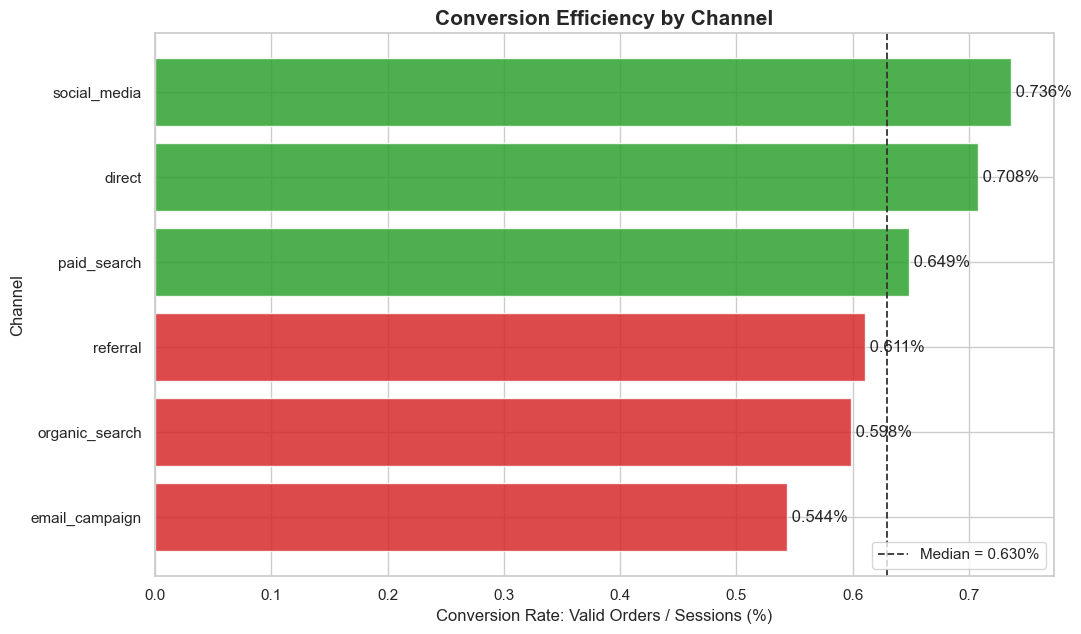

,channel,sessions,valid_orders,conversion_rate,orders_per_10k_sessions,avg_bounce_rate,avg_session_duration_sec,traffic_share_pct
5,social_media,15816226,116397,0.735934,73.593410,0.004476,210.290190,17.294464
0,direct,6571549,46525,0.707976,70.797616,0.004511,207.678195,7.185748
3,paid_search,19598271,127114,0.648598,64.859803,0.004478,209.362117,21.429992
4,referral,9476845,57867,0.610615,61.061461,0.004499,207.558667,10.362583
2,organic_search,27196976,162765,0.598467,59.846727,0.004504,211.153945,29.738897
1,email_campaign,12792670,69540,0.543593,54.359254,0.004458,213.220594,13.988316


In [ ]:
plot_df = conversion_efficiency.sort_values("conversion_rate", ascending=True).copy()
colors = plot_df["conversion_rate"].map(
    lambda value: "#2ca02c" if value >= conversion_efficiency["conversion_rate"].median() else "#d62728"
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6.5))
bars = plt.barh(plot_df["channel"], plot_df["conversion_rate"], color=colors, alpha=0.84)

median_rate = conversion_efficiency["conversion_rate"].median()
plt.axvline(median_rate, color="#333333", linestyle="--", linewidth=1.3, label=f"Median = {median_rate:.3f}%")

plt.title("Conversion Efficiency by Channel", fontsize=15, weight="bold")
plt.xlabel("Conversion Rate: Valid Orders / Sessions (%)")
plt.ylabel("Channel")
plt.legend(loc="lower right")

for bar, value in zip(bars, plot_df["conversion_rate"]):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.3f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

conversion_efficiency[[
    "channel",
    "sessions",
    "valid_orders",
    "conversion_rate",
    "orders_per_10k_sessions",
    "avg_bounce_rate",
    "avg_session_duration_sec",
    "traffic_share_pct"
]]


In [ ]:
plt.figure(figsize=(10, 6.5))
sns.scatterplot(
    data=conversion_efficiency,
    x="traffic_share_pct",
    y="conversion_rate",
    size="sessions",
    hue="avg_bounce_rate",
    palette="rocket_r",
    sizes=(180, 900),
    edgecolor="white",
    linewidth=1.2
)

for _, row in conversion_efficiency.iterrows():
    plt.text(
        row["traffic_share_pct"] + 0.12,
        row["conversion_rate"] + 0.002,
        row["channel"],
        fontsize=10
    )

plt.axhline(conversion_efficiency["conversion_rate"].median(), color="#333333", linestyle="--", linewidth=1)
plt.title("Traffic Scale vs Conversion Efficiency", fontsize=15, weight="bold")
plt.xlabel("Traffic Share (%)")
plt.ylabel("Conversion Rate (%)")
plt.legend(title="Avg Bounce Rate", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Insight gợi ý:** Kênh có `conversion_rate` cao là kênh chuyển đổi tốt, kể cả khi traffic không lớn. Kênh có traffic share cao nhưng conversion rate thấp là nhóm cần tối ưu landing page, target audience, offer/promotion hoặc checkout funnel. Nên so sánh thêm `avg_bounce_rate` và `avg_session_duration_sec` để phân biệt traffic kém chất lượng với vấn đề ở bước mua hàng.

# Chẩn Đoán Kênh Social Media

Tách phân tích thành 3 phần: traffic so với doanh thu, bounce rate và conversion rate theo source/channel. `social_media` được highlight để kiểm tra giả thuyết: traffic cao, doanh thu thấp, bounce cao hoặc conversion kém.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

traffic_path = Path("data/interim/web_traffic.csv")
orders_path = Path("data/interim/orders.csv")
master_path = Path("data/output/master_table.csv")

if not traffic_path.exists():
    traffic_path = Path("..") / traffic_path
    orders_path = Path("..") / orders_path
    master_path = Path("..") / master_path

traffic = pd.read_csv(
    traffic_path,
    usecols=["traffic_source", "sessions", "unique_visitors", "bounce_rate", "avg_session_duration_sec"]
)
orders = pd.read_csv(
    orders_path,
    usecols=["order_id", "order_source", "order_status"]
)
master = pd.read_csv(
    master_path,
    usecols=["order_item_id", "order_source", "line_revenue", "refund_amount", "order_status"]
)

valid_statuses = ["paid", "shipped", "delivered", "returned"]

master = master.drop_duplicates(subset=["order_item_id"]).copy()
master["refund_amount"] = master["refund_amount"].fillna(0)
master["net_revenue"] = master["line_revenue"] - master["refund_amount"]
master = master[master["order_status"].isin(valid_statuses)].copy()

valid_orders = orders[orders["order_status"].isin(valid_statuses)].copy()

traffic_summary = (
    traffic
    .assign(weighted_bounce=traffic["bounce_rate"] * traffic["sessions"])
    .groupby("traffic_source", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        weighted_bounce=("weighted_bounce", "sum"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean")
    )
    .rename(columns={"traffic_source": "source"})
)
traffic_summary["bounce_rate"] = traffic_summary["weighted_bounce"] / traffic_summary["sessions"]

revenue_summary = (
    master
    .groupby("order_source", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        gross_revenue=("line_revenue", "sum"),
        order_items=("order_item_id", "nunique")
    )
    .rename(columns={"order_source": "source"})
)

orders_summary = (
    valid_orders
    .groupby("order_source", as_index=False)
    .agg(valid_orders=("order_id", "nunique"))
    .rename(columns={"order_source": "source"})
)

source_summary = (
    traffic_summary
    .merge(revenue_summary, on="source", how="outer", validate="one_to_one")
    .merge(orders_summary, on="source", how="outer", validate="one_to_one")
    .fillna(0)
)

source_summary["traffic_share_pct"] = source_summary["sessions"] / source_summary["sessions"].sum() * 100
source_summary["revenue_share_pct"] = source_summary["net_revenue"] / source_summary["net_revenue"].sum() * 100
source_summary["revenue_per_session"] = source_summary["net_revenue"] / source_summary["sessions"].replace(0, pd.NA)
source_summary["conversion_rate"] = source_summary["valid_orders"] / source_summary["sessions"].replace(0, pd.NA) * 100
source_summary["orders_per_10k_sessions"] = source_summary["valid_orders"] / source_summary["sessions"].replace(0, pd.NA) * 10_000
source_summary["traffic_minus_revenue_pp"] = source_summary["traffic_share_pct"] - source_summary["revenue_share_pct"]
source_summary["is_social"] = source_summary["source"].eq("social_media")

source_summary.sort_values("traffic_share_pct", ascending=False)


,source,sessions,unique_visitors,weighted_bounce,avg_session_duration_sec,bounce_rate,net_revenue,gross_revenue,order_items,valid_orders,traffic_share_pct,revenue_share_pct,revenue_per_session,conversion_rate,orders_per_10k_sessions,traffic_minus_revenue_pp,is_social
2,organic_search,27196976,20625107,122345.17197,211.153945,0.004498,3.786820e+09,3.931137e+09,179741,162765,29.738897,27.965133,139.236820,0.598467,59.846727,1.773764,False
3,paid_search,19598271,14922386,87787.19618,209.362117,0.004479,2.976735e+09,3.087465e+09,140417,127114,21.429992,21.982768,151.887643,0.648598,64.859803,-0.552777,False
5,social_media,15816226,12048065,70773.83948,210.290190,0.004475,2.714772e+09,2.815157e+09,128576,116397,17.294464,20.048204,171.644717,0.735934,73.593410,-2.753740,True
1,email_campaign,12792670,9700462,56738.72409,213.220594,0.004435,1.623846e+09,1.687051e+09,77005,69540,13.988316,11.991876,126.935695,0.543593,54.359254,1.996440,False
4,referral,9476845,7220019,42899.95017,207.558667,0.004527,1.352324e+09,1.403314e+09,63883,57867,10.362583,9.986723,142.697732,0.610615,61.061461,0.375859,False
0,direct,6571549,4986650,29709.88723,207.678195,0.004521,1.086723e+09,1.127695e+09,51365,46525,7.185748,8.025295,165.367842,0.707976,70.797616,-0.839546,False


## Chart 6: Traffic và doanh thu theo source

Chart này kiểm tra source nào có tỷ trọng traffic cao nhưng tỷ trọng doanh thu thấp. Nếu `social_media` nằm dưới đường chéo hoặc `Traffic Share - Revenue Share` dương, nghĩa là social mang về nhiều traffic hơn doanh thu.

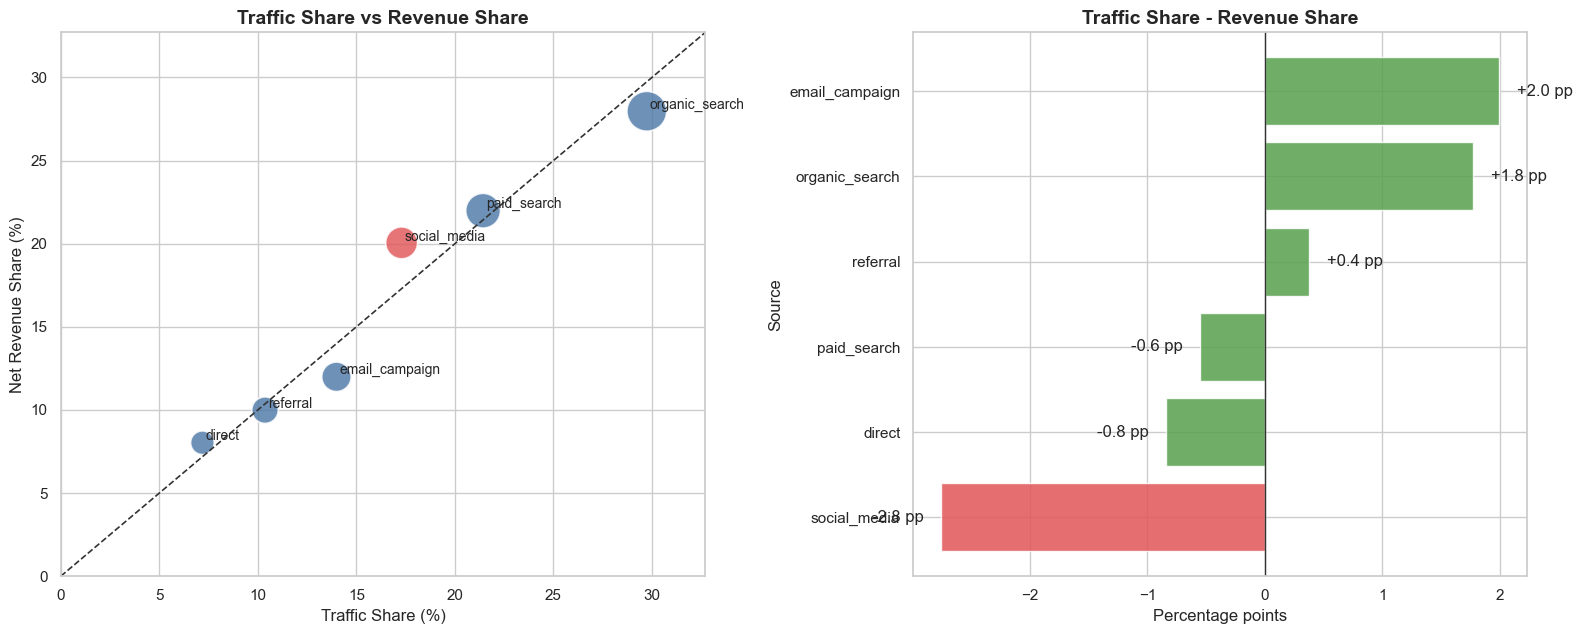

,source,sessions,traffic_share_pct,net_revenue,revenue_share_pct,revenue_per_session,traffic_minus_revenue_pp
2,organic_search,27196976,29.738897,3.786820e+09,27.965133,139.236820,1.773764
3,paid_search,19598271,21.429992,2.976735e+09,21.982768,151.887643,-0.552777
5,social_media,15816226,17.294464,2.714772e+09,20.048204,171.644717,-2.753740
1,email_campaign,12792670,13.988316,1.623846e+09,11.991876,126.935695,1.996440
4,referral,9476845,10.362583,1.352324e+09,9.986723,142.697732,0.375859
0,direct,6571549,7.185748,1.086723e+09,8.025295,165.367842,-0.839546


In [ ]:
plot_df = source_summary.sort_values("traffic_share_pct", ascending=False).copy()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1.05, 1]})

scatter_colors = plot_df["is_social"].map({True: "#e15759", False: "#4e79a7"})
axes[0].scatter(
    plot_df["traffic_share_pct"],
    plot_df["revenue_share_pct"],
    s=plot_df["sessions"] / plot_df["sessions"].max() * 700 + 120,
    c=scatter_colors,
    alpha=0.82,
    edgecolors="white",
    linewidths=1.2
)

limit = max(plot_df["traffic_share_pct"].max(), plot_df["revenue_share_pct"].max()) * 1.1
axes[0].plot([0, limit], [0, limit], color="#333333", linestyle="--", linewidth=1.2)
for _, row in plot_df.iterrows():
    axes[0].text(row["traffic_share_pct"] + 0.15, row["revenue_share_pct"] + 0.15, row["source"], fontsize=10)

axes[0].set_title("Traffic Share vs Revenue Share", fontsize=14, weight="bold")
axes[0].set_xlabel("Traffic Share (%)")
axes[0].set_ylabel("Net Revenue Share (%)")
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)

bar_df = plot_df.sort_values("traffic_minus_revenue_pp", ascending=True)
bar_colors = bar_df["is_social"].map({True: "#e15759", False: "#59a14f"})
axes[1].barh(bar_df["source"], bar_df["traffic_minus_revenue_pp"], color=bar_colors, alpha=0.86)
axes[1].axvline(0, color="#333333", linewidth=1)
axes[1].set_title("Traffic Share - Revenue Share", fontsize=14, weight="bold")
axes[1].set_xlabel("Percentage points")
axes[1].set_ylabel("Source")

for source, value in zip(bar_df["source"], bar_df["traffic_minus_revenue_pp"]):
    ha = "left" if value >= 0 else "right"
    offset = 0.15 if value >= 0 else -0.15
    axes[1].text(value + offset, source, f"{value:+.1f} pp", va="center", ha=ha)

plt.tight_layout()
plt.show()

source_summary[["source", "sessions", "traffic_share_pct", "net_revenue", "revenue_share_pct", "revenue_per_session", "traffic_minus_revenue_pp"]].sort_values("traffic_share_pct", ascending=False)


## Chart 7: Bounce rate theo traffic source

Chart này xem source nào có bounce rate cao. Nếu `social_media` có bounce rate cao, traffic từ social có thể vào rồi thoát nhanh, làm giảm khả năng tạo đơn hàng.

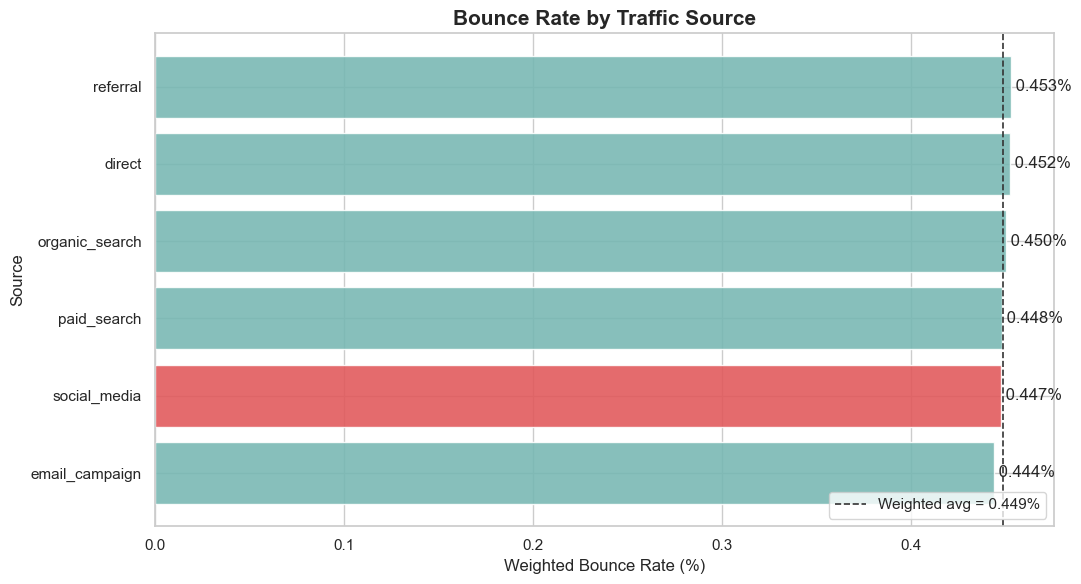

,source,sessions,bounce_rate,avg_session_duration_sec,traffic_share_pct
4,referral,9476845,0.004527,207.558667,10.362583
0,direct,6571549,0.004521,207.678195,7.185748
2,organic_search,27196976,0.004498,211.153945,29.738897
3,paid_search,19598271,0.004479,209.362117,21.429992
5,social_media,15816226,0.004475,210.290190,17.294464
1,email_campaign,12792670,0.004435,213.220594,13.988316


In [ ]:
bounce_df = source_summary.sort_values("bounce_rate", ascending=True).copy()
bounce_colors = bounce_df["is_social"].map({True: "#e15759", False: "#76b7b2"})

plt.figure(figsize=(11, 6))
bars = plt.barh(bounce_df["source"], bounce_df["bounce_rate"] * 100, color=bounce_colors, alpha=0.88)

avg_bounce = (traffic["bounce_rate"] * traffic["sessions"]).sum() / traffic["sessions"].sum() * 100
plt.axvline(avg_bounce, color="#333333", linestyle="--", linewidth=1.2, label=f"Weighted avg = {avg_bounce:.3f}%")

plt.title("Bounce Rate by Traffic Source", fontsize=15, weight="bold")
plt.xlabel("Weighted Bounce Rate (%)")
plt.ylabel("Source")
plt.legend(loc="lower right")

for bar, value in zip(bars, bounce_df["bounce_rate"] * 100):
    plt.text(value, bar.get_y() + bar.get_height() / 2, f" {value:.3f}%", va="center")

plt.tight_layout()
plt.show()

source_summary[["source", "sessions", "bounce_rate", "avg_session_duration_sec", "traffic_share_pct"]].sort_values("bounce_rate", ascending=False)


## Chart 8: Conversion rate từ session sang đơn hàng theo source

Chart này đo hiệu quả chuyển đổi từ session sang đơn hàng hợp lệ: `conversion_rate = valid_orders / sessions`. Source có conversion thấp nhưng traffic cao là nhóm cần ưu tiên tối ưu.

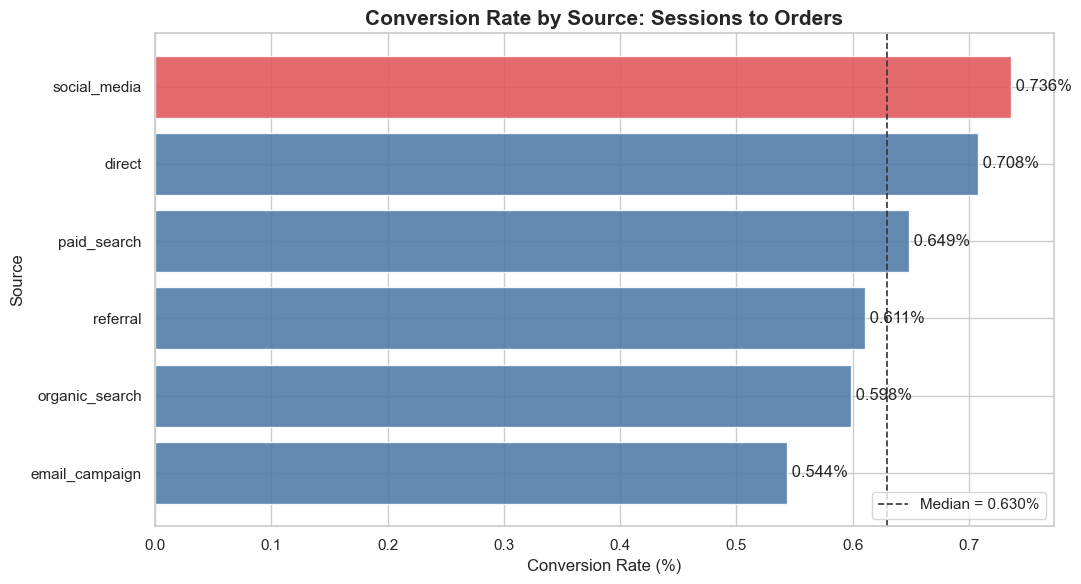

,source,sessions,valid_orders,conversion_rate,orders_per_10k_sessions,traffic_share_pct
5,social_media,15816226,116397,0.735934,73.593410,17.294464
0,direct,6571549,46525,0.707976,70.797616,7.185748
3,paid_search,19598271,127114,0.648598,64.859803,21.429992
4,referral,9476845,57867,0.610615,61.061461,10.362583
2,organic_search,27196976,162765,0.598467,59.846727,29.738897
1,email_campaign,12792670,69540,0.543593,54.359254,13.988316


In [ ]:
conversion_df = source_summary.sort_values("conversion_rate", ascending=True).copy()
conversion_colors = conversion_df["is_social"].map({True: "#e15759", False: "#4e79a7"})

plt.figure(figsize=(11, 6))
bars = plt.barh(conversion_df["source"], conversion_df["conversion_rate"], color=conversion_colors, alpha=0.88)

median_conversion = source_summary["conversion_rate"].median()
plt.axvline(median_conversion, color="#333333", linestyle="--", linewidth=1.2, label=f"Median = {median_conversion:.3f}%")

plt.title("Conversion Rate by Source: Sessions to Orders", fontsize=15, weight="bold")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Source")
plt.legend(loc="lower right")

for bar, value in zip(bars, conversion_df["conversion_rate"]):
    plt.text(value, bar.get_y() + bar.get_height() / 2, f" {value:.3f}%", va="center")

plt.tight_layout()
plt.show()

source_summary[["source", "sessions", "valid_orders", "conversion_rate", "orders_per_10k_sessions", "traffic_share_pct"]].sort_values("conversion_rate", ascending=False)


**Insight gợi ý:** Đọc 3 chart theo thứ tự: nếu `social_media` có traffic share cao nhưng revenue share thấp, vấn đề nằm ở monetization. Nếu bounce rate cao, vấn đề có thể ở chất lượng traffic hoặc landing page. Nếu bounce không cao nhưng conversion thấp, cần kiểm tra offer, product fit, checkout funnel hoặc promotion cho traffic social.

# Promo và Non-promo Revenue Share Theo Thời Gian

Mục tiêu là xem tỷ trọng doanh thu đến từ đơn có promo và không promo thay đổi như thế nào theo thời gian. Nhãn `Promo` được gán khi `promo_id` có giá trị khác `NO_PROMO`; phần còn lại là `Non-promo`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

order_items_path = Path("data/interim/order_items.csv")
orders_path = Path("data/interim/orders.csv")

if not order_items_path.exists():
    order_items_path = Path("..") / order_items_path
    orders_path = Path("..") / orders_path

order_items = pd.read_csv(
    order_items_path,
    usecols=["order_id", "product_id", "quantity", "unit_price", "discount_amount", "promo_id"]
)
orders = pd.read_csv(
    orders_path,
    usecols=["order_id", "order_date", "order_status"]
)

orders["order_date"] = pd.to_datetime(orders["order_date"])
order_items["discount_amount"] = order_items["discount_amount"].fillna(0)
order_items["promo_id"] = order_items["promo_id"].fillna("NO_PROMO")

order_items["line_revenue"] = (
    order_items["quantity"] * order_items["unit_price"] - order_items["discount_amount"]
)
order_items["promo_group"] = order_items["promo_id"].where(
    order_items["promo_id"] != "NO_PROMO",
    "Non-promo"
)
order_items["promo_group"] = order_items["promo_group"].mask(
    order_items["promo_group"] != "Non-promo",
    "Promo"
)

valid_statuses = ["paid", "shipped", "delivered", "returned"]
df = order_items.merge(orders, on="order_id", how="left", validate="many_to_one")
df = df[df["order_status"].isin(valid_statuses)].copy()

monthly_promo_revenue = (
    df
    .assign(month=df["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "promo_group"], as_index=False)
    .agg(revenue=("line_revenue", "sum"))
)

monthly_total = monthly_promo_revenue.groupby("month")["revenue"].transform("sum")
monthly_promo_revenue["revenue_share_pct"] = monthly_promo_revenue["revenue"] / monthly_total * 100

promo_share_wide = (
    monthly_promo_revenue
    .pivot(index="month", columns="promo_group", values="revenue_share_pct")
    .fillna(0)
    .reset_index()
)

for column in ["Promo", "Non-promo"]:
    if column not in promo_share_wide.columns:
        promo_share_wide[column] = 0

promo_share_wide.head()


promo_group,month,Non-promo,Promo
0,2012-07-01,100.0,0.0
1,2012-08-01,100.0,0.0
2,2012-09-01,100.0,0.0
3,2012-10-01,100.0,0.0
4,2012-11-01,100.0,0.0


**Insight gợi ý:** Nếu tỷ trọng `Promo` tăng dần theo thời gian, doanh thu đang phụ thuộc nhiều hơn vào đơn có khuyến mãi. Nếu `Non-promo` vẫn chiếm tỷ trọng lớn và ổn định, doanh thu không bị kéo quá mạnh bởi promo. Các tháng `Promo` tăng đột biến nên được kiểm tra thêm theo campaign, source/channel và discount rate.

# Promo và Non-promo: Margin và AOV

Mục tiêu là kiểm tra promo có đang kéo doanh thu bằng cách đánh đổi margin hay không, đồng thời so sánh AOV giữa đơn Promo và Non-promo.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

master_path = Path("data/output/master_table.csv")
if not master_path.exists():
    master_path = Path("..") / master_path

master = pd.read_csv(
    master_path,
    usecols=[
        "order_id",
        "order_item_id",
        "line_revenue",
        "quantity",
        "line_cogs",
        "discount_amount",
        "promo_id",
        "order_status"
    ]
)

master = master.drop_duplicates(subset=["order_item_id"]).copy()
master["discount_amount"] = master["discount_amount"].fillna(0)
master["promo_id"] = master["promo_id"].fillna("NO_PROMO")
master["promo_group"] = master["promo_id"].where(master["promo_id"].eq("NO_PROMO"), "Promo")
master["promo_group"] = master["promo_group"].replace({"NO_PROMO": "Non-promo"})

valid_statuses = ["paid", "shipped", "delivered", "returned"]
master = master[master["order_status"].isin(valid_statuses)].copy()

promo_profit_summary = (
    master
    .groupby("promo_group", as_index=False)
    .agg(
        revenue=("line_revenue", "sum"),
        cogs=("line_cogs", "sum"),
        discount=("discount_amount", "sum"),
        quantity=("quantity", "sum"),
        order_items=("order_item_id", "nunique"),
        orders=("order_id", "nunique")
    )
)

promo_profit_summary["margin"] = (
    (promo_profit_summary["revenue"] - promo_profit_summary["cogs"] - promo_profit_summary["discount"])
    / promo_profit_summary["revenue"]
    * 100
)

order_level = (
    master
    .groupby(["order_id", "promo_group"], as_index=False)
    .agg(order_revenue=("line_revenue", "sum"))
)

aov_summary = (
    order_level
    .groupby("promo_group", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_revenue", "sum"),
        aov=("order_revenue", "mean"),
        median_order_value=("order_revenue", "median")
    )
)

promo_profit_summary, aov_summary


(  promo_group       revenue          cogs      discount  order_items  orders  \
 0   Non-promo  9.852643e+09  7.885258e+09  0.000000e+00       393273  357918   
 1       Promo  4.199177e+09  4.805416e+09  6.718994e+08       247714  222529   
 
       margin  
 0  19.968094  
 1 -30.437843  ,
   promo_group  orders       revenue           aov  median_order_value
 0   Non-promo  357918  9.852643e+09  27527.653097            20409.04
 1       Promo  222529  4.199177e+09  18870.245567            13435.95)

## Chart 9: Margin theo nhóm promo

Công thức: `margin = (revenue - cogs - discount) / revenue`. Nếu Promo có margin thấp đáng kể hơn Non-promo, có dấu hiệu đang dùng khuyến mãi để mua doanh thu nhưng làm mỏng lợi nhuận.

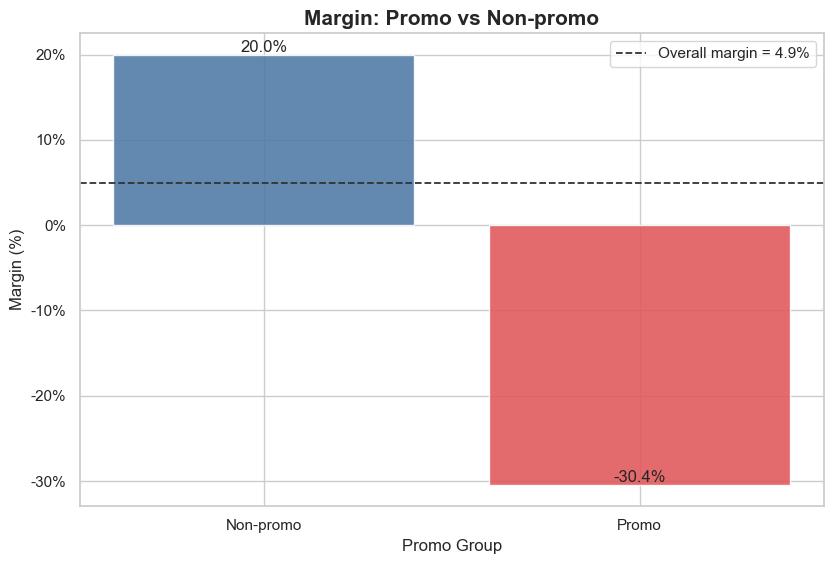

,promo_group,revenue,cogs,discount,order_items,orders,margin
0,Non-promo,9.852643e+09,7.885258e+09,0.000000e+00,393273,357918,19.968094
1,Promo,4.199177e+09,4.805416e+09,6.718994e+08,247714,222529,-30.437843


In [ ]:
margin_plot = promo_profit_summary.sort_values("margin", ascending=False).copy()
colors = margin_plot["promo_group"].map({"Promo": "#e15759", "Non-promo": "#4e79a7"})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8.5, 5.8))
bars = plt.bar(margin_plot["promo_group"], margin_plot["margin"], color=colors, alpha=0.88)

overall_margin = (
    (promo_profit_summary["revenue"].sum() - promo_profit_summary["cogs"].sum() - promo_profit_summary["discount"].sum())
    / promo_profit_summary["revenue"].sum()
    * 100
)
plt.axhline(
    overall_margin,
    color="#333333",
    linestyle="--",
    linewidth=1.3,
    label=f"Overall margin = {overall_margin:.1f}%"
)

plt.title("Margin: Promo vs Non-promo", fontsize=15, weight="bold")
plt.xlabel("Promo Group")
plt.ylabel("Margin (%)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
plt.legend(loc="upper right")

for bar, value in zip(bars, margin_plot["margin"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

promo_profit_summary


## Chart 10: AOV theo nhóm promo

AOV đo giá trị đơn hàng trung bình. Nếu Promo có AOV cao nhưng margin thấp, doanh thu có thể tăng nhờ đơn lớn hơn nhưng lợi nhuận bị bào mòn bởi discount.

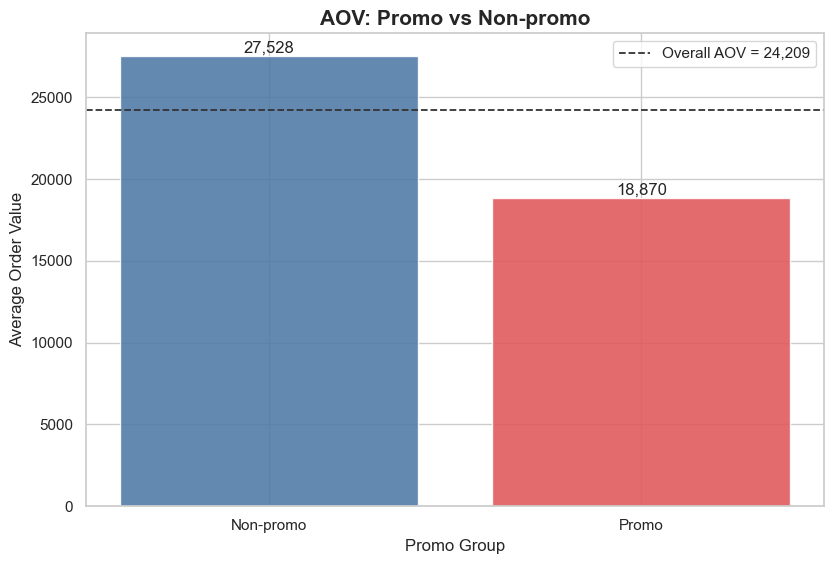

,promo_group,orders,revenue,aov,median_order_value
0,Non-promo,357918,9.852643e+09,27527.653097,20409.04
1,Promo,222529,4.199177e+09,18870.245567,13435.95


In [ ]:
aov_plot = aov_summary.sort_values("aov", ascending=False).copy()
colors = aov_plot["promo_group"].map({"Promo": "#e15759", "Non-promo": "#4e79a7"})

plt.figure(figsize=(8.5, 5.8))
bars = plt.bar(aov_plot["promo_group"], aov_plot["aov"], color=colors, alpha=0.88)

overall_aov = order_level["order_revenue"].mean()
plt.axhline(
    overall_aov,
    color="#333333",
    linestyle="--",
    linewidth=1.3,
    label=f"Overall AOV = {overall_aov:,.0f}"
)

plt.title("AOV: Promo vs Non-promo", fontsize=15, weight="bold")
plt.xlabel("Promo Group")
plt.ylabel("Average Order Value")
plt.legend(loc="upper right")

for bar, value in zip(bars, aov_plot["aov"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

aov_summary


**Insight gợi ý:** Nếu `Promo` có margin thấp hơn rõ rệt so với `Non-promo`, promo đang có dấu hiệu “đốt tiền”. Nếu `Promo` có AOV cao nhưng margin thấp, nên kiểm tra sâu thêm discount rate, campaign, product mix và return/refund để biết phần tăng doanh thu có thật sự đáng giá không.

## Chart 11: Xu hướng margin hằng tháng của Promo và Non-promo

Mục tiêu là theo dõi profitability thực tế theo thời gian, không chỉ nhìn revenue. Trục X là tháng-năm từ 2012 đến 2022, trục Y là margin %, gồm 2 đường: `Non-promo margin` và `Promo margin`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

master_path = Path("data/output/master_table.csv")
if not master_path.exists():
    master_path = Path("..") / master_path

master = pd.read_csv(
    master_path,
    usecols=[
        "order_item_id",
        "order_date",
        "line_revenue",
        "line_cogs",
        "discount_amount",
        "promo_id",
        "order_status"
    ]
)

master = master.drop_duplicates(subset=["order_item_id"]).copy()
master["order_date"] = pd.to_datetime(master["order_date"])
master["discount_amount"] = master["discount_amount"].fillna(0)
master["promo_id"] = master["promo_id"].fillna("NO_PROMO")
master["promo_group"] = master["promo_id"].where(master["promo_id"].eq("NO_PROMO"), "Promo")
master["promo_group"] = master["promo_group"].replace({"NO_PROMO": "Non-promo"})

valid_statuses = ["paid", "shipped", "delivered", "returned"]
master = master[master["order_status"].isin(valid_statuses)].copy()

monthly_margin = (
    master
    .assign(month=master["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "promo_group"], as_index=False)
    .agg(
        revenue=("line_revenue", "sum"),
        cogs=("line_cogs", "sum"),
        discount=("discount_amount", "sum"),
        order_items=("order_item_id", "nunique")
    )
)

monthly_margin["margin_pct"] = (
    (monthly_margin["revenue"] - monthly_margin["cogs"] - monthly_margin["discount"])
    / monthly_margin["revenue"]
    * 100
)

monthly_margin.head()


,month,promo_group,revenue,cogs,discount,order_items,margin_pct
0,2012-07-01,Non-promo,1.173202e+08,9.215159e+07,0.0,5291,21.452929
1,2012-08-01,Non-promo,1.420137e+08,1.119074e+08,0.0,6422,21.199575
2,2012-09-01,Non-promo,1.162562e+08,9.235767e+07,0.0,5320,20.556745
3,2012-10-01,Non-promo,9.945702e+07,7.942535e+07,0.0,4432,20.141037
4,2012-11-01,Non-promo,8.684751e+07,6.890775e+07,0.0,4344,20.656612


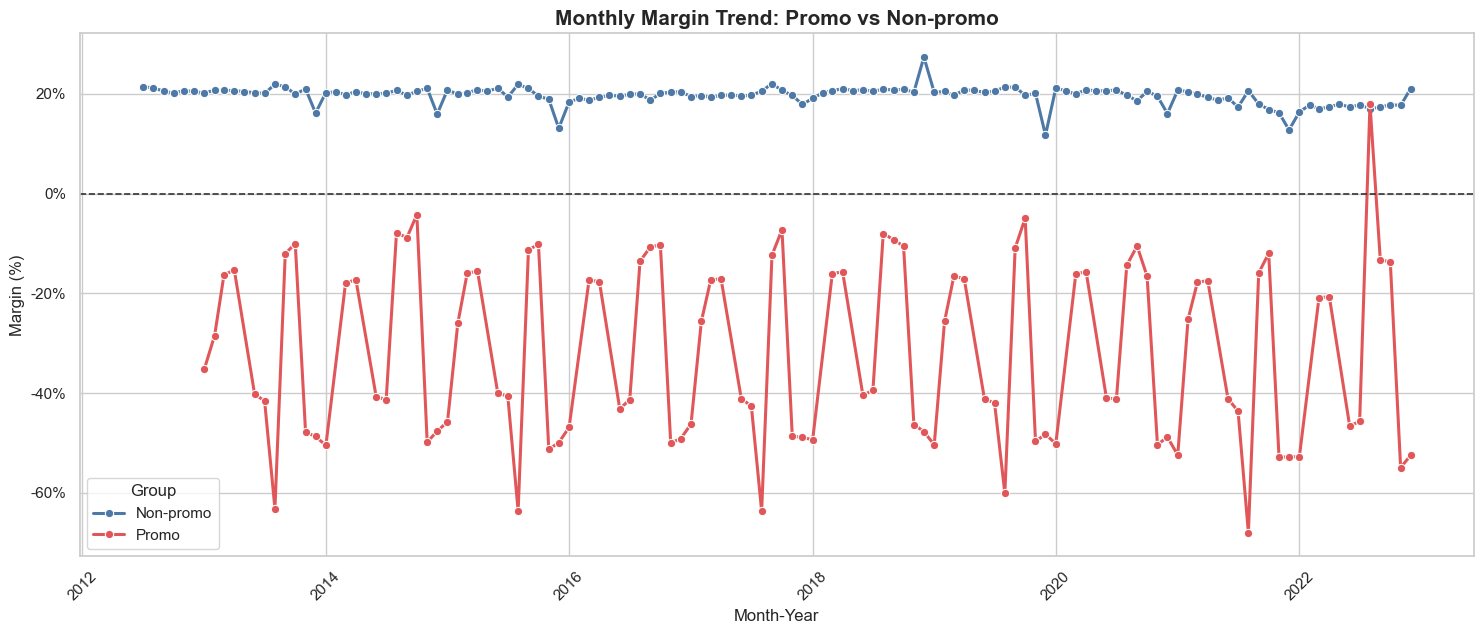

,month,promo_group,revenue,cogs,discount,order_items,margin_pct
219,2022-07-01,Non-promo,36578041.71,3.006930e+07,0.00,1064,17.794109
220,2022-07-01,Promo,41798244.62,5.171412e+07,9175224.39,1816,-45.674398
221,2022-08-01,Non-promo,99919013.39,8.288016e+07,0.00,3036,17.052666
222,2022-08-01,Promo,62429.07,4.427846e+04,6936.56,2,17.962873
223,2022-09-01,Non-promo,5610426.11,4.639065e+06,0.00,181,17.313502
224,2022-09-01,Promo,63459921.15,6.484445e+07,7051102.78,2264,-13.292845
225,2022-10-01,Non-promo,65039083.87,5.342853e+07,0.00,1919,17.851658
226,2022-10-01,Promo,516899.22,5.301901e+05,57433.23,18,-13.682377
227,2022-11-01,Non-promo,30139125.68,2.481023e+07,0.00,920,17.680978
228,2022-11-01,Promo,12833495.06,1.667484e+07,3208373.76,701,-54.932187


In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 6.5))
sns.lineplot(
    data=monthly_margin,
    x="month",
    y="margin_pct",
    hue="promo_group",
    marker="o",
    linewidth=2.2,
    palette={"Non-promo": "#4e79a7", "Promo": "#e15759"}
)

plt.axhline(0, color="#333333", linewidth=1.2, linestyle="--")
plt.title("Monthly Margin Trend: Promo vs Non-promo", fontsize=15, weight="bold")
plt.xlabel("Month-Year")
plt.ylabel("Margin (%)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
plt.xticks(rotation=45)
plt.legend(title="Group")
plt.tight_layout()
plt.show()

monthly_margin.tail(12)


**Insight gợi ý:** Nếu `Promo margin` thường xuyên nằm dưới `Non-promo margin`, promo đang làm mỏng profitability. Nếu `Promo margin` xuống dưới 0% trong nhiều tháng, đây là dấu hiệu đốt tiền. Khoảng cách giữa 2 đường cho biết promo đang ảnh hưởng margin mạnh đến mức nào theo từng giai đoạn và mùa vụ.

## Chart 12-13: Promo revenue share theo thời gian

Mục tiêu là đo doanh thu từ hàng/đơn có promo chiếm bao nhiêu phần trăm tổng doanh thu qua các thời kỳ. Metric chính: `promo_revenue_share_pct = promo_revenue / total_revenue * 100`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

order_items_path = Path("data/interim/order_items.csv")
orders_path = Path("data/interim/orders.csv")

if not order_items_path.exists():
    order_items_path = Path("..") / order_items_path
    orders_path = Path("..") / orders_path

order_items = pd.read_csv(
    order_items_path,
    usecols=["order_id", "quantity", "unit_price", "discount_amount", "promo_id"]
)
orders = pd.read_csv(
    orders_path,
    usecols=["order_id", "order_date", "order_status"]
)

orders["order_date"] = pd.to_datetime(orders["order_date"])
order_items["discount_amount"] = order_items["discount_amount"].fillna(0)
order_items["promo_id"] = order_items["promo_id"].fillna("NO_PROMO")

order_items["revenue"] = (
    order_items["quantity"] * order_items["unit_price"] - order_items["discount_amount"]
)
order_items["is_promo"] = order_items["promo_id"] != "NO_PROMO"

valid_statuses = ["paid", "shipped", "delivered", "returned"]
df = order_items.merge(orders, on="order_id", how="left", validate="many_to_one")
df = df[df["order_status"].isin(valid_statuses)].copy()

promo_share_by_month = (
    df
    .assign(month=df["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        total_revenue=("revenue", "sum"),
        promo_revenue=("revenue", lambda values: values[df.loc[values.index, "is_promo"]].sum()),
        promo_order_items=("is_promo", "sum"),
        total_order_items=("is_promo", "count")
    )
)

promo_share_by_month["non_promo_revenue"] = (
    promo_share_by_month["total_revenue"] - promo_share_by_month["promo_revenue"]
)
promo_share_by_month["promo_revenue_share_pct"] = (
    promo_share_by_month["promo_revenue"] / promo_share_by_month["total_revenue"] * 100
)
promo_share_by_month["non_promo_revenue_share_pct"] = 100 - promo_share_by_month["promo_revenue_share_pct"]

promo_share_by_month.head()


,month,total_revenue,promo_revenue,promo_order_items,total_order_items,non_promo_revenue,promo_revenue_share_pct,non_promo_revenue_share_pct
0,2012-07-01,1.173202e+08,0.0,0,5291,1.173202e+08,0.0,100.0
1,2012-08-01,1.420216e+08,0.0,0,6423,1.420216e+08,0.0,100.0
2,2012-09-01,1.162562e+08,0.0,0,5320,1.162562e+08,0.0,100.0
3,2012-10-01,9.945702e+07,0.0,0,4432,9.945702e+07,0.0,100.0
4,2012-11-01,8.684751e+07,0.0,0,4344,8.684751e+07,0.0,100.0


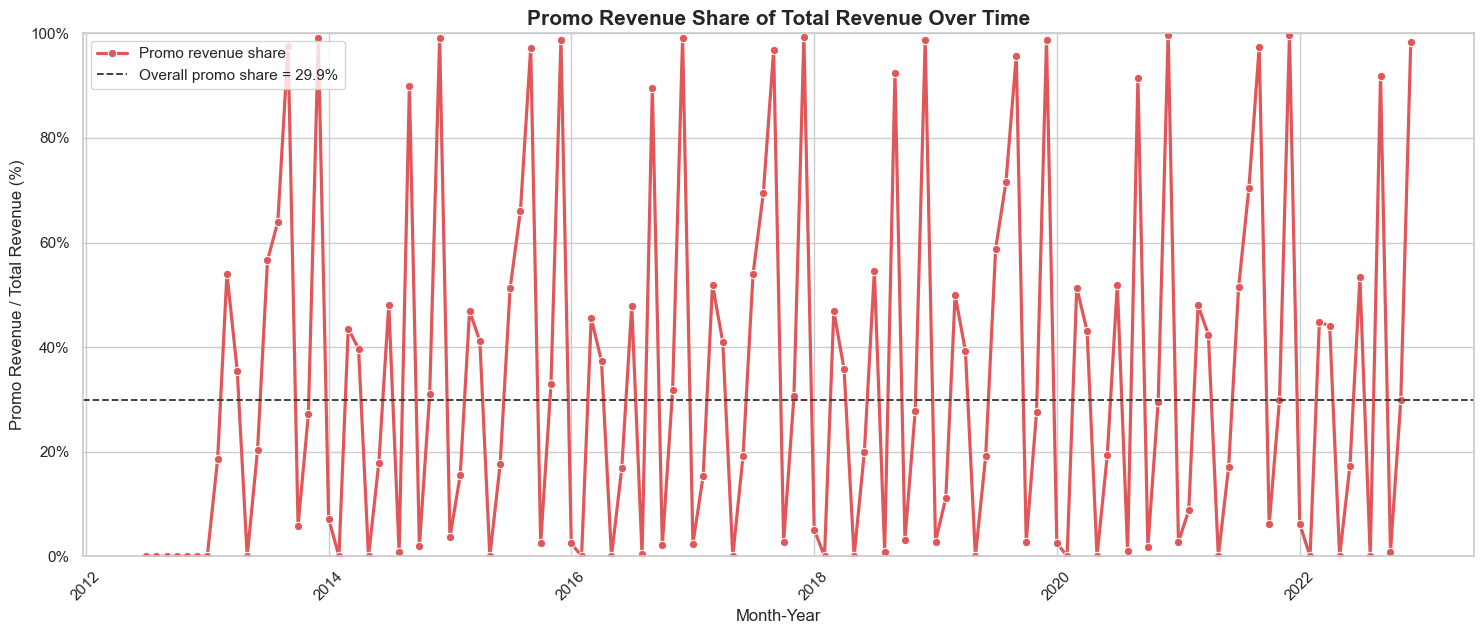

,month,total_revenue,promo_revenue,promo_order_items,total_order_items,non_promo_revenue,promo_revenue_share_pct,non_promo_revenue_share_pct
114,2022-01-01,5.224515e+07,3235223.03,182,1657,4.900993e+07,6.192389,93.807611
115,2022-02-01,7.096314e+07,0.00,0,2069,7.096314e+07,0.000000,100.000000
116,2022-03-01,1.149543e+08,51416567.05,2078,3941,6.353775e+07,44.727825,55.272175
117,2022-04-01,1.179594e+08,52026918.35,2124,4177,6.593252e+07,44.105771,55.894229
118,2022-05-01,1.232811e+08,0.00,0,3788,1.232811e+08,0.000000,100.000000
119,2022-06-01,1.157945e+08,20103813.48,908,3739,9.569066e+07,17.361635,82.638365
120,2022-07-01,7.837629e+07,41798244.62,1816,2880,3.657804e+07,53.330218,46.669782
121,2022-08-01,9.998144e+07,62429.07,2,3038,9.991901e+07,0.062441,99.937559
122,2022-09-01,6.907035e+07,63459921.15,2264,2445,5.610426e+06,91.877229,8.122771
123,2022-10-01,6.555598e+07,516899.22,18,1937,6.503908e+07,0.788485,99.211515


In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 6.5))
sns.lineplot(
    data=promo_share_by_month,
    x="month",
    y="promo_revenue_share_pct",
    marker="o",
    linewidth=2.3,
    color="#e15759",
    label="Promo revenue share"
)

avg_promo_share = (
    promo_share_by_month["promo_revenue"].sum() / promo_share_by_month["total_revenue"].sum() * 100
)
plt.axhline(
    avg_promo_share,
    color="#333333",
    linestyle="--",
    linewidth=1.3,
    label=f"Overall promo share = {avg_promo_share:.1f}%"
)

plt.title("Promo Revenue Share of Total Revenue Over Time", fontsize=15, weight="bold")
plt.xlabel("Month-Year")
plt.ylabel("Promo Revenue / Total Revenue (%)")
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
plt.xticks(rotation=45)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

promo_share_by_month.tail(12)


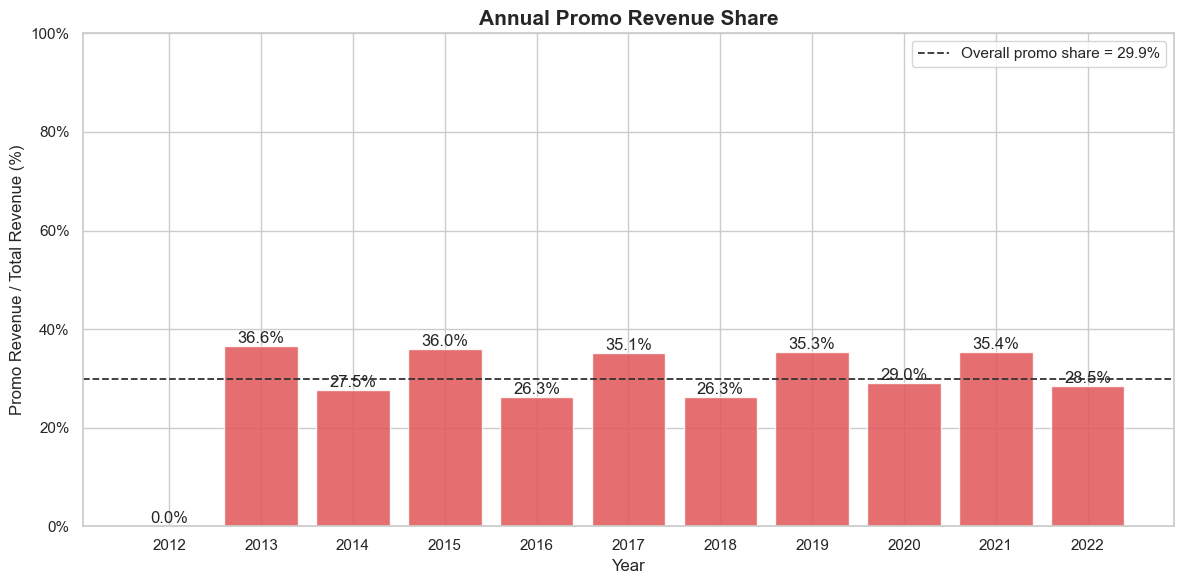

,year,total_revenue,promo_revenue,non_promo_revenue,promo_revenue_share_pct
0,2012,6.648634e+08,0.000000e+00,6.648634e+08,0.000000
1,2013,1.408393e+09,5.158321e+08,8.925610e+08,36.625576
2,2014,1.606203e+09,4.424081e+08,1.163794e+09,27.543731
3,2015,1.608803e+09,5.798423e+08,1.028961e+09,36.041844
4,2016,1.808137e+09,4.753415e+08,1.332795e+09,26.289027
5,2017,1.631255e+09,5.726233e+08,1.058632e+09,35.103231
6,2018,1.587296e+09,4.174476e+08,1.169848e+09,26.299291
7,2019,9.682658e+08,3.414719e+08,6.267939e+08,35.266342
8,2020,9.004414e+08,2.608162e+08,6.396252e+08,28.965371
9,2021,8.803609e+08,3.118099e+08,5.685510e+08,35.418415


In [ ]:
promo_share_by_year = (
    promo_share_by_month
    .assign(year=promo_share_by_month["month"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        total_revenue=("total_revenue", "sum"),
        promo_revenue=("promo_revenue", "sum"),
        non_promo_revenue=("non_promo_revenue", "sum")
    )
)
promo_share_by_year["promo_revenue_share_pct"] = (
    promo_share_by_year["promo_revenue"] / promo_share_by_year["total_revenue"] * 100
)

plt.figure(figsize=(12, 6))
bars = plt.bar(
    promo_share_by_year["year"].astype(str),
    promo_share_by_year["promo_revenue_share_pct"],
    color="#e15759",
    alpha=0.86
)
plt.axhline(
    avg_promo_share,
    color="#333333",
    linestyle="--",
    linewidth=1.3,
    label=f"Overall promo share = {avg_promo_share:.1f}%"
)

plt.title("Annual Promo Revenue Share", fontsize=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("Promo Revenue / Total Revenue (%)")
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
plt.legend(loc="upper right")

for bar, value in zip(bars, promo_share_by_year["promo_revenue_share_pct"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

promo_share_by_year


**Insight gợi ý:** Nếu `promo_revenue_share_pct` tăng qua thời gian, tổng doanh thu đang phụ thuộc nhiều hơn vào đơn có promo. Các tháng hoặc năm vượt xa đường average nên được kiểm tra thêm theo campaign, discount rate, margin và AOV để xem tăng trưởng đó có bền vững hay đang đánh đổi lợi nhuận.

# Traffic Mix, Chất Lượng Source và Doanh Thu So Với Traffic

Bộ 3 chart này kiểm tra traffic tổng đến từ source nào, source nào có chất lượng kém và source nào kéo traffic nhưng không kéo doanh thu tương xứng.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

traffic_path = Path("data/interim/web_traffic.csv")
orders_path = Path("data/interim/orders.csv")
master_path = Path("data/output/master_table.csv")

if not traffic_path.exists():
    traffic_path = Path("..") / traffic_path
    orders_path = Path("..") / orders_path
    master_path = Path("..") / master_path

traffic = pd.read_csv(
    traffic_path,
    usecols=["date", "traffic_source", "sessions", "unique_visitors", "bounce_rate"]
)
orders = pd.read_csv(
    orders_path,
    usecols=["order_id", "order_source", "order_status"]
)
master = pd.read_csv(
    master_path,
    usecols=["order_item_id", "order_source", "line_revenue", "refund_amount", "order_status"]
)

traffic["date"] = pd.to_datetime(traffic["date"])
master = master.drop_duplicates(subset=["order_item_id"]).copy()
master["refund_amount"] = master["refund_amount"].fillna(0)
master["net_revenue"] = master["line_revenue"] - master["refund_amount"]

valid_statuses = ["paid", "shipped", "delivered", "returned"]
valid_orders = orders[orders["order_status"].isin(valid_statuses)].copy()
master = master[master["order_status"].isin(valid_statuses)].copy()

source_palette = {
    "organic_search": "#4e79a7",
    "paid_search": "#f28e2b",
    "social_media": "#e15759",
    "email_campaign": "#76b7b2",
    "referral": "#59a14f",
    "direct": "#edc948"
}

traffic_source_summary = (
    traffic
    .groupby("traffic_source", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        avg_bounce_rate=("bounce_rate", "mean")
    )
)

orders_source_summary = (
    valid_orders
    .groupby("order_source", as_index=False)
    .agg(orders=("order_id", "nunique"))
    .rename(columns={"order_source": "traffic_source"})
)

revenue_source_summary = (
    master
    .groupby("order_source", as_index=False)
    .agg(revenue=("net_revenue", "sum"))
    .rename(columns={"order_source": "traffic_source"})
)

source_quality = (
    traffic_source_summary
    .merge(orders_source_summary, on="traffic_source", how="left", validate="one_to_one")
    .merge(revenue_source_summary, on="traffic_source", how="left", validate="one_to_one")
    .fillna({"orders": 0, "revenue": 0})
)
source_quality["conversion_rate"] = source_quality["orders"] / source_quality["sessions"] * 100
source_quality["revenue_per_session"] = source_quality["revenue"] / source_quality["sessions"]
source_quality["traffic_share_pct"] = source_quality["sessions"] / source_quality["sessions"].sum() * 100
source_quality["revenue_share_pct"] = source_quality["revenue"] / source_quality["revenue"].sum() * 100
source_quality["traffic_minus_revenue_pp"] = source_quality["traffic_share_pct"] - source_quality["revenue_share_pct"]

source_quality.sort_values("sessions", ascending=False)


,traffic_source,sessions,unique_visitors,avg_bounce_rate,orders,revenue,conversion_rate,revenue_per_session,traffic_share_pct,revenue_share_pct,traffic_minus_revenue_pp
2,organic_search,27196976,20625107,0.004504,162765,3.786820e+09,0.598467,139.236820,29.738897,27.965133,1.773764
3,paid_search,19598271,14922386,0.004478,127114,2.976735e+09,0.648598,151.887643,21.429992,21.982768,-0.552777
5,social_media,15816226,12048065,0.004476,116397,2.714772e+09,0.735934,171.644717,17.294464,20.048204,-2.753740
1,email_campaign,12792670,9700462,0.004458,69540,1.623846e+09,0.543593,126.935695,13.988316,11.991876,1.996440
4,referral,9476845,7220019,0.004499,57867,1.352324e+09,0.610615,142.697732,10.362583,9.986723,0.375859
0,direct,6571549,4986650,0.004511,46525,1.086723e+09,0.707976,165.367842,7.185748,8.025295,-0.839546


# Đào Sâu Mức Độ Phụ Thuộc Vào Promo

Mục tiêu là kiểm tra doanh thu có đang phụ thuộc vào promo không, promo đóng góp bao nhiêu revenue, AOV của đơn promo có bị kéo xuống không và discount có tăng qua thời gian không.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

master_path = Path("data/output/master_table.csv")
if not master_path.exists():
    master_path = Path("..") / master_path

promo_base = pd.read_csv(
    master_path,
    usecols=[
        "order_id",
        "order_item_id",
        "order_date",
        "line_revenue",
        "quantity",
        "discount_amount",
        "promo_id",
        "order_status"
    ]
)

promo_base = promo_base.drop_duplicates(subset=["order_item_id"]).copy()
promo_base["order_date"] = pd.to_datetime(promo_base["order_date"])
promo_base["discount_amount"] = promo_base["discount_amount"].fillna(0)
promo_base["promo_id"] = promo_base["promo_id"].fillna("NO_PROMO")
promo_base["has_promo_item"] = promo_base["promo_id"] != "NO_PROMO"

valid_statuses = ["paid", "shipped", "delivered", "returned"]
promo_base = promo_base[promo_base["order_status"].isin(valid_statuses)].copy()

order_promo = (
    promo_base
    .groupby("order_id", as_index=False)
    .agg(
        order_date=("order_date", "min"),
        revenue=("line_revenue", "sum"),
        discount=("discount_amount", "sum"),
        quantity=("quantity", "sum"),
        has_promo=("has_promo_item", "max")
    )
)

order_promo["month"] = order_promo["order_date"].dt.to_period("M").dt.to_timestamp()
order_promo["promo_group"] = order_promo["has_promo"].map({True: "Promo", False: "Non-promo"})
order_promo["gross_before_discount"] = order_promo["revenue"] + order_promo["discount"]
order_promo["discount_pct"] = (
    order_promo["discount"] / order_promo["gross_before_discount"].replace(0, pd.NA) * 100
).fillna(0)

order_promo.head()


,order_id,order_date,revenue,discount,has_promo,month,promo_group,gross_before_discount,discount_pct
0,1,2012-07-04,7967.54,0.0,False,2012-07-01,Non-promo,7967.54,0.0
1,2,2012-07-04,71163.75,0.0,False,2012-07-01,Non-promo,71163.75,0.0
2,3,2012-07-04,33660.99,0.0,False,2012-07-01,Non-promo,33660.99,0.0
3,4,2012-07-04,53196.25,0.0,False,2012-07-01,Non-promo,53196.25,0.0
4,6,2012-07-06,1597.84,0.0,False,2012-07-01,Non-promo,1597.84,0.0


## Chart 14: AOV của Promo và Non-promo

Công thức: `AOV = Revenue / Orders`. Đơn có ít nhất một item dùng promo được xếp vào nhóm Promo.

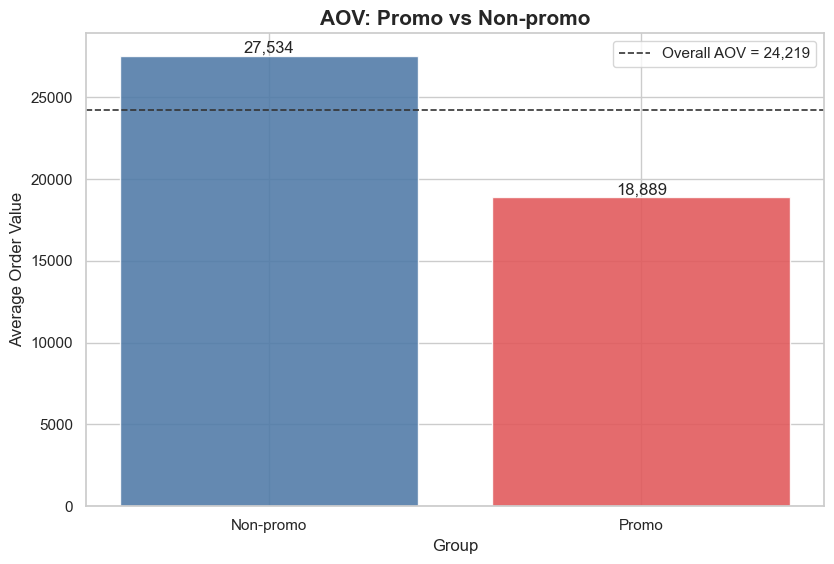

,promo_group,revenue,orders,aov
0,Non-promo,9.848418e+09,357679,27534.234742
1,Promo,4.203402e+09,222529,18889.231825


In [ ]:
aov_by_promo = (
    order_promo
    .groupby("promo_group", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique")
    )
)
aov_by_promo["aov"] = aov_by_promo["revenue"] / aov_by_promo["orders"]

aov_plot = aov_by_promo.sort_values("aov", ascending=False).copy()
colors = aov_plot["promo_group"].map({"Promo": "#e15759", "Non-promo": "#4e79a7"})

overall_aov = order_promo["revenue"].sum() / order_promo["order_id"].nunique()

fig, ax = plt.subplots(figsize=(8.5, 5.8))
bars = ax.bar(aov_plot["promo_group"], aov_plot["aov"], color=colors, alpha=0.88)
ax.axhline(
    overall_aov,
    color="#333333",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall AOV = {overall_aov:,.0f}"
)
ax.set_title("AOV: Promo vs Non-promo", fontsize=15, weight="bold")
ax.set_xlabel("Group")
ax.set_ylabel("Average Order Value")
ax.legend(loc="upper right")

for bar, value in zip(bars, aov_plot["aov"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

aov_by_promo


## Chart 15: Số lượng đơn hàng theo thời gian và trạng thái promo

Mục tiêu là theo dõi số lượng đơn hàng theo thời gian và tách màu theo đơn có promo/không promo để xem order volume có đang được kéo bởi khuyến mãi hay không.

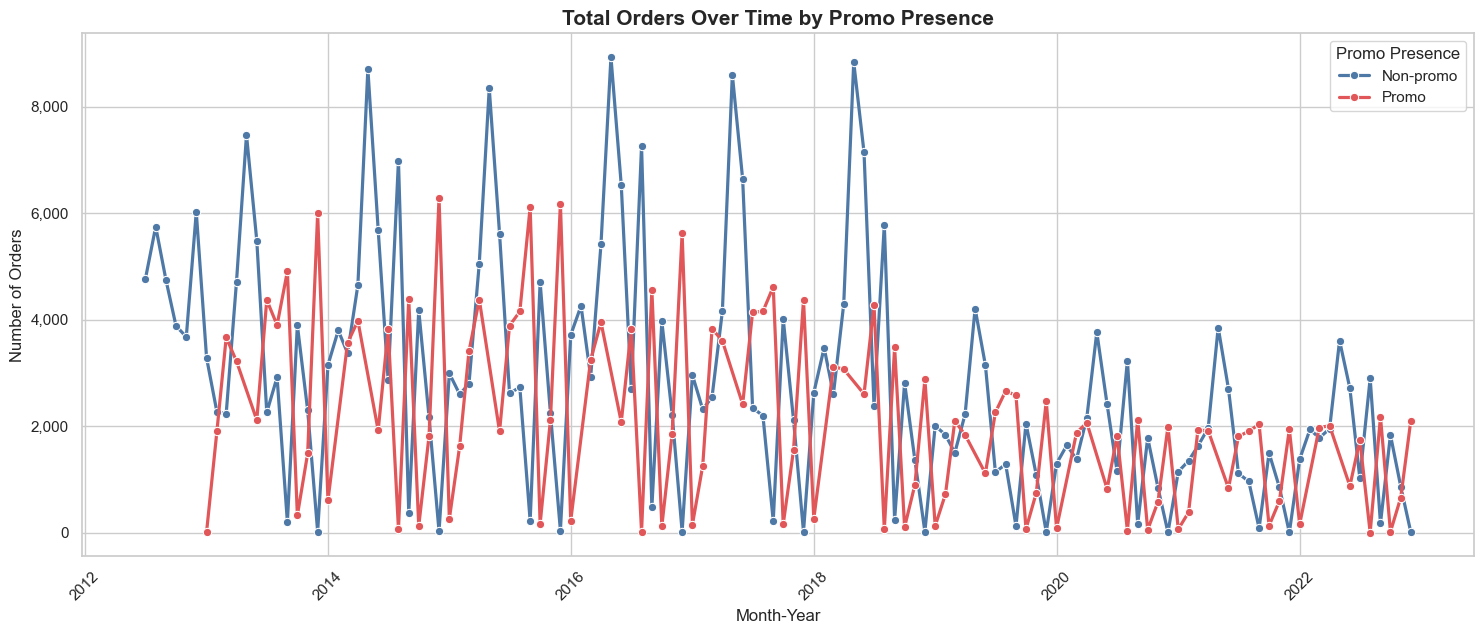

,month,promo_group,orders
219,2022-07-01,Non-promo,1020
220,2022-07-01,Promo,1741
221,2022-08-01,Non-promo,2897
222,2022-08-01,Promo,2
223,2022-09-01,Non-promo,174
224,2022-09-01,Promo,2172
225,2022-10-01,Non-promo,1834
226,2022-10-01,Promo,16
227,2022-11-01,Non-promo,865
228,2022-11-01,Promo,659


In [ ]:
orders_by_promo_monthly = (
    order_promo
    .groupby(["month", "promo_group"], as_index=False)
    .agg(orders=("order_id", "nunique"))
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 6.5))
sns.lineplot(
    data=orders_by_promo_monthly,
    x="month",
    y="orders",
    hue="promo_group",
    marker="o",
    linewidth=2.3,
    palette={"Promo": "#e15759", "Non-promo": "#4e79a7"},
    ax=ax
)

ax.set_title("Total Orders Over Time by Promo Presence", fontsize=15, weight="bold")
ax.set_xlabel("Month-Year")
ax.set_ylabel("Number of Orders")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.legend(title="Promo Presence")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

orders_by_promo_monthly.tail(12)


**Insight gợi ý:** Nếu đường `Promo` tăng nhanh hơn `Non-promo`, tăng trưởng số đơn đang phụ thuộc nhiều hơn vào khuyến mãi. Nếu `Non-promo` vẫn tăng ổn định, demand nền có thể tốt hơn và ít cần discount hơn.

## Chart 16: Quantity per order của Promo và Non-promo

Mục tiêu là xem đơn có promo mua nhiều sản phẩm hơn hay ít hơn. Công thức: `quantity_per_order = total_quantity / orders`.

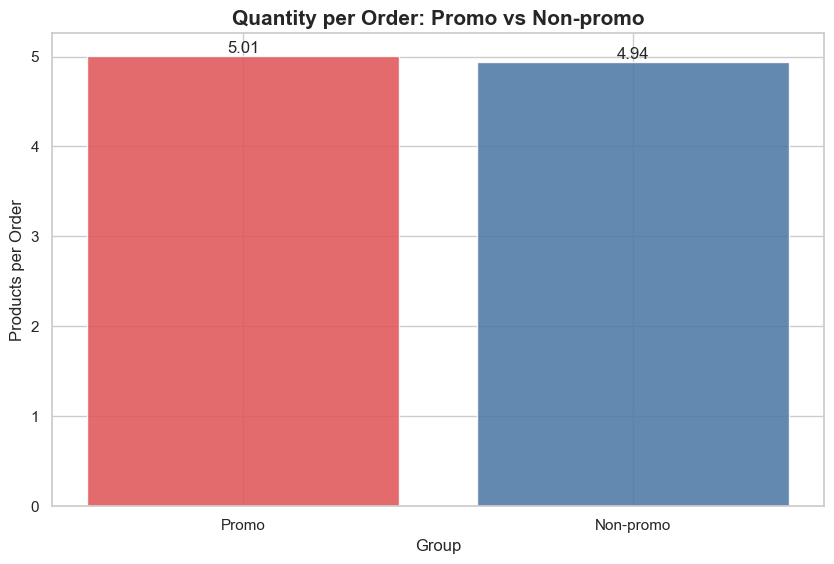

,promo_group,orders,total_quantity,quantity_per_order
0,Non-promo,357679,1766549,4.938923
1,Promo,222529,1114284,5.007365


In [ ]:
if "quantity" not in order_promo.columns:
    quantity_fix = pd.read_csv(
        master_path,
        usecols=["order_id", "order_item_id", "quantity", "order_status"]
    )
    quantity_fix = quantity_fix.drop_duplicates(subset=["order_item_id"]).copy()
    quantity_fix = quantity_fix[quantity_fix["order_status"].isin(valid_statuses)].copy()
    quantity_fix = (
        quantity_fix
        .groupby("order_id", as_index=False)
        .agg(quantity=("quantity", "sum"))
    )
    order_promo = order_promo.merge(quantity_fix, on="order_id", how="left", validate="one_to_one")

quantity_per_order = (
    order_promo
    .groupby("promo_group", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        total_quantity=("quantity", "sum")
    )
)
quantity_per_order["quantity_per_order"] = quantity_per_order["total_quantity"] / quantity_per_order["orders"]

plot_df = quantity_per_order.sort_values("quantity_per_order", ascending=False).copy()
colors = plot_df["promo_group"].map({"Promo": "#e15759", "Non-promo": "#4e79a7"})

fig, ax = plt.subplots(figsize=(8.5, 5.8))
bars = ax.bar(plot_df["promo_group"], plot_df["quantity_per_order"], color=colors, alpha=0.88)
ax.set_title("Quantity per Order: Promo vs Non-promo", fontsize=15, weight="bold")
ax.set_xlabel("Group")
ax.set_ylabel("Products per Order")

for bar, value in zip(bars, plot_df["quantity_per_order"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

quantity_per_order


**Insight gợi ý:** Nếu `Promo` có quantity/order thấp hơn `Non-promo`, khách dùng promo không mua nhiều sản phẩm hơn mà có thể chỉ mua ít hơn với giá được giảm. Đây là dấu hiệu cần đọc tiếp với AOV và ASP.

## Chart 17: Price per item (ASP) của Promo và Non-promo

ASP sau discount được tính bằng `revenue / quantity`. Nếu ASP của Promo thấp hơn, khách promo có xu hướng mua item giá rẻ hơn hoặc giá sau discount bị kéo xuống mạnh.

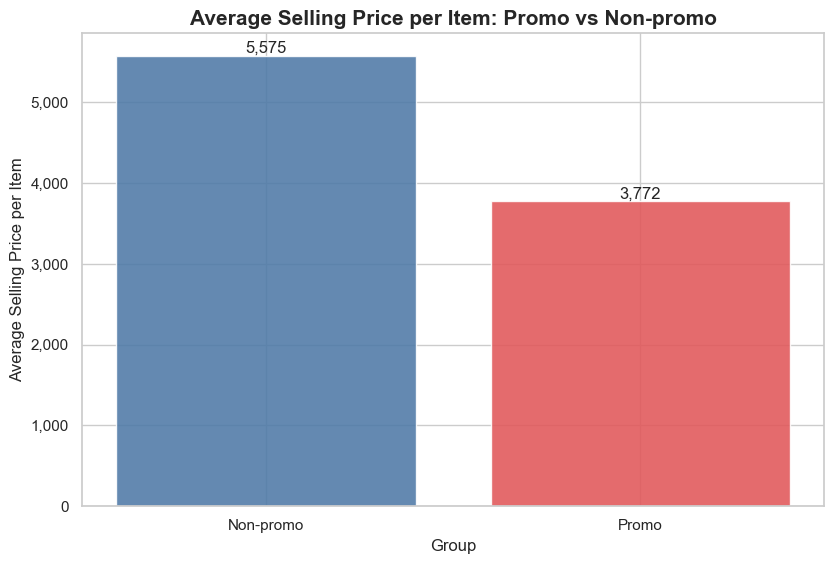

,promo_group,revenue,total_quantity,asp
0,Non-promo,9.848418e+09,1766549,5574.947283
1,Promo,4.203402e+09,1114284,3772.289532


In [ ]:
if "quantity" not in order_promo.columns:
    quantity_fix = pd.read_csv(
        master_path,
        usecols=["order_id", "order_item_id", "quantity", "order_status"]
    )
    quantity_fix = quantity_fix.drop_duplicates(subset=["order_item_id"]).copy()
    quantity_fix = quantity_fix[quantity_fix["order_status"].isin(valid_statuses)].copy()
    quantity_fix = (
        quantity_fix
        .groupby("order_id", as_index=False)
        .agg(quantity=("quantity", "sum"))
    )
    order_promo = order_promo.merge(quantity_fix, on="order_id", how="left", validate="one_to_one")

asp_by_promo = (
    order_promo
    .groupby("promo_group", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        total_quantity=("quantity", "sum")
    )
)
asp_by_promo["asp"] = asp_by_promo["revenue"] / asp_by_promo["total_quantity"]

plot_df = asp_by_promo.sort_values("asp", ascending=False).copy()
colors = plot_df["promo_group"].map({"Promo": "#e15759", "Non-promo": "#4e79a7"})

fig, ax = plt.subplots(figsize=(8.5, 5.8))
bars = ax.bar(plot_df["promo_group"], plot_df["asp"], color=colors, alpha=0.88)
ax.set_title("Average Selling Price per Item: Promo vs Non-promo", fontsize=15, weight="bold")
ax.set_xlabel("Group")
ax.set_ylabel("Average Selling Price per Item")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

for bar, value in zip(bars, plot_df["asp"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

asp_by_promo


**Insight gợi ý:** Nếu `Promo ASP` thấp hơn rõ rệt, khách promo đang mua sản phẩm rẻ hơn hoặc discount làm giá bán trung bình trên sản phẩm bị kéo xuống. Khi ASP và quantity/order cùng giảm, revenue promo có chất lượng thấp hơn.

## Chart 18: AOV trước và sau discount

Chart này so sánh giá trị đơn hàng trước discount và sau discount theo Promo/Non-promo. `AOV before discount = gross_before_discount / orders`; `AOV after discount = revenue / orders`.

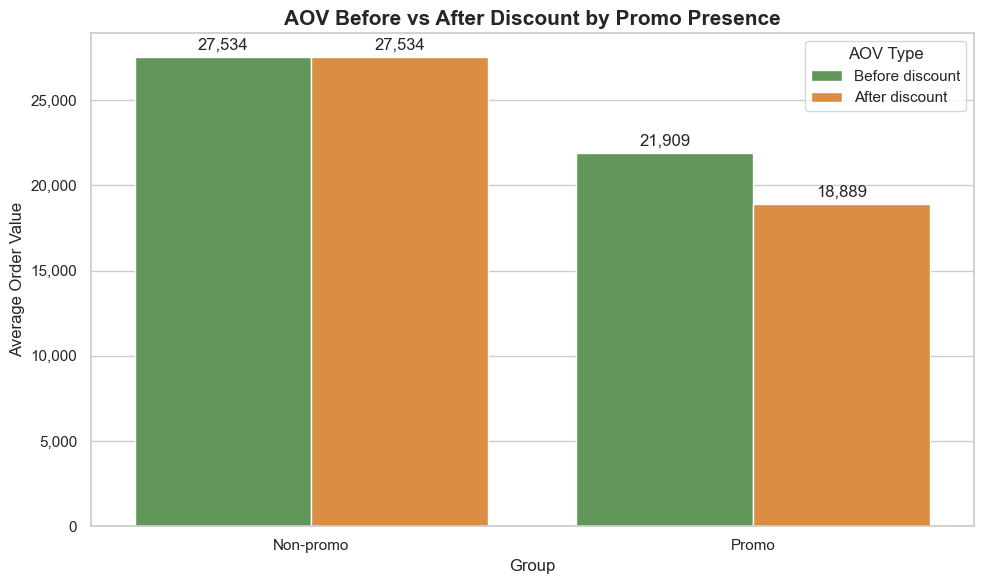

,promo_group,orders,revenue_after_discount,revenue_before_discount,total_discount,aov_before_discount,aov_after_discount,aov_discount_gap
0,Non-promo,357679,9.848418e+09,9.848418e+09,0.000000e+00,27534.234742,27534.234742,0.000000
1,Promo,222529,4.203402e+09,4.875301e+09,6.718994e+08,21908.610899,18889.231825,3019.379075


In [ ]:
aov_discount_comparison = (
    order_promo
    .groupby("promo_group", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue_after_discount=("revenue", "sum"),
        revenue_before_discount=("gross_before_discount", "sum"),
        total_discount=("discount", "sum")
    )
)
aov_discount_comparison["aov_before_discount"] = (
    aov_discount_comparison["revenue_before_discount"] / aov_discount_comparison["orders"]
)
aov_discount_comparison["aov_after_discount"] = (
    aov_discount_comparison["revenue_after_discount"] / aov_discount_comparison["orders"]
)
aov_discount_comparison["aov_discount_gap"] = (
    aov_discount_comparison["aov_before_discount"] - aov_discount_comparison["aov_after_discount"]
)

plot_df = aov_discount_comparison.melt(
    id_vars="promo_group",
    value_vars=["aov_before_discount", "aov_after_discount"],
    var_name="aov_type",
    value_name="aov"
)
plot_df["aov_type"] = plot_df["aov_type"].map({
    "aov_before_discount": "Before discount",
    "aov_after_discount": "After discount"
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="promo_group",
    y="aov",
    hue="aov_type",
    palette={"Before discount": "#59a14f", "After discount": "#f28e2b"},
    ax=ax
)
ax.set_title("AOV Before vs After Discount by Promo Presence", fontsize=15, weight="bold")
ax.set_xlabel("Group")
ax.set_ylabel("Average Order Value")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.legend(title="AOV Type")

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)

plt.tight_layout()
plt.show()

aov_discount_comparison


**Insight gợi ý:** Nếu AOV trước discount của Promo không cao hơn nhiều nhưng AOV sau discount giảm mạnh, promo đang làm mất giá trị đơn hàng thay vì tạo thêm basket size. Nếu khoảng cách before-after lớn, cần đối chiếu với margin để xem discount có đang ăn lợi nhuận không.

# Phân Tích Inventory, Sales và Sell-through

Mục tiêu là kiểm tra mismatch giữa tồn kho và sales, category nào đang giữ nhiều hàng và phân phối sell-through rate để nhận diện hàng chết, trạng thái healthy hoặc nguy cơ thiếu hàng.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

inventory_path = Path("data/raw/inventory.csv")
if not inventory_path.exists():
    inventory_path = Path("..") / inventory_path

inventory = pd.read_csv(
    inventory_path,
    usecols=[
        "snapshot_date",
        "product_id",
        "category",
        "stock_on_hand",
        "units_sold",
        "sell_through_rate"
    ]
)

inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])
inventory["month"] = inventory["snapshot_date"].dt.to_period("M").dt.to_timestamp()

inventory.head()


,snapshot_date,product_id,stock_on_hand,units_sold,sell_through_rate,category,month
0,2022-10-31,1,3,1,0.2500,Casual,2022-10-01
1,2022-11-30,1,3,1,0.2500,Casual,2022-11-01
2,2022-12-31,1,3,1,0.2500,Casual,2022-12-01
3,2016-04-30,3,35,11,0.2391,Casual,2016-04-01
4,2016-05-31,3,36,10,0.2174,Casual,2016-05-01


## Chart 19: Inventory và sales theo thời gian

Line chart này so sánh `total stock_on_hand` và `total units_sold` theo tháng để nhìn macro mismatch giữa tồn kho và sales.

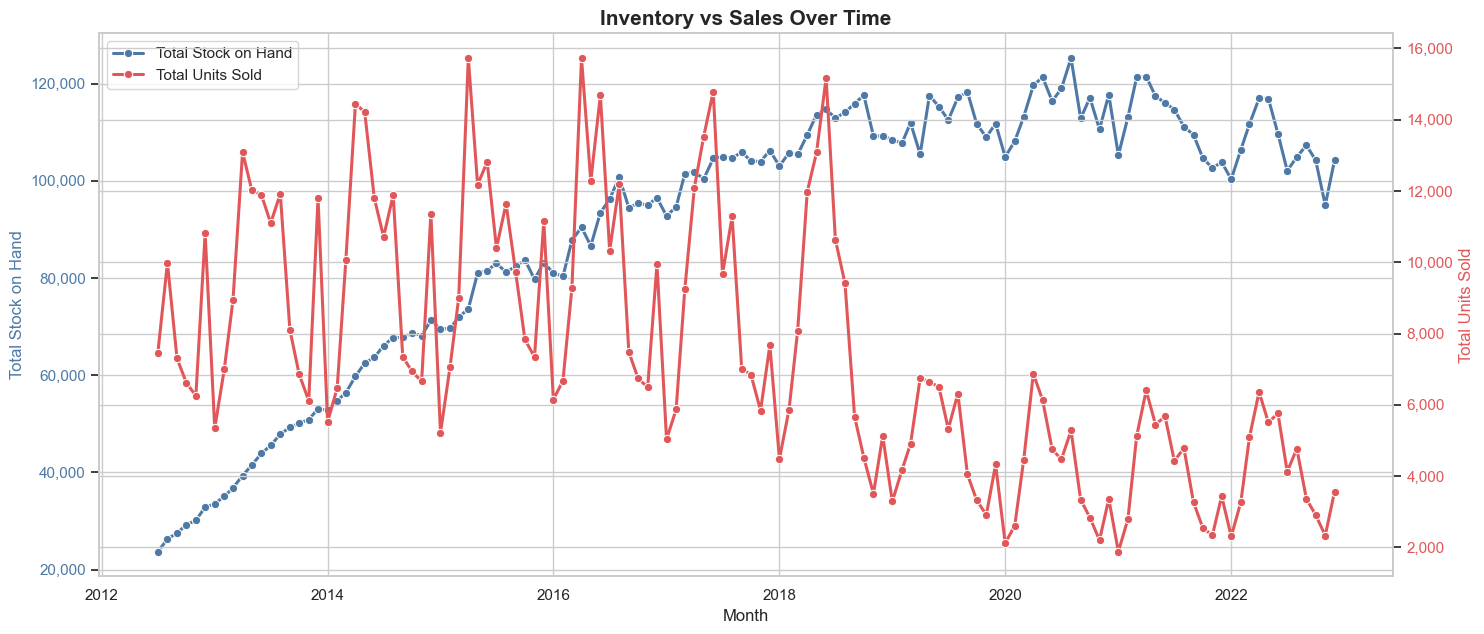

,month,total_stock_on_hand,total_units_sold
114,2022-01-01,100332,2305
115,2022-02-01,106405,3270
116,2022-03-01,111674,5096
117,2022-04-01,116977,6360
118,2022-05-01,116939,5509
119,2022-06-01,109700,5759
120,2022-07-01,102083,4123
121,2022-08-01,104884,4772
122,2022-09-01,107309,3360
123,2022-10-01,104255,2908


In [ ]:
inventory_sales_monthly = (
    inventory
    .groupby("month", as_index=False)
    .agg(
        total_stock_on_hand=("stock_on_hand", "sum"),
        total_units_sold=("units_sold", "sum")
    )
    .sort_values("month")
)

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(15, 6.5))

sns.lineplot(
    data=inventory_sales_monthly,
    x="month",
    y="total_stock_on_hand",
    marker="o",
    linewidth=2.2,
    color="#4e79a7",
    label="Total Stock on Hand",
    ax=ax1
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Stock on Hand", color="#4e79a7")
ax1.tick_params(axis="y", labelcolor="#4e79a7")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

ax2 = ax1.twinx()
sns.lineplot(
    data=inventory_sales_monthly,
    x="month",
    y="total_units_sold",
    marker="o",
    linewidth=2.2,
    color="#e15759",
    label="Total Units Sold",
    ax=ax2
)
ax2.set_ylabel("Total Units Sold", color="#e15759")
ax2.tick_params(axis="y", labelcolor="#e15759")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
ax2.get_legend().remove()

ax1.set_title("Inventory vs Sales Over Time", fontsize=15, weight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

inventory_sales_monthly.tail(12)


**Insight gợi ý:** Nếu `total_stock_on_hand` tăng nhưng `total_units_sold` không tăng tương ứng, có dấu hiệu overstock. Nếu `total_units_sold` tăng nhưng stock không tăng hoặc giảm, cần cảnh báo stockout risk và kiểm tra category/product đang bán nhanh.

## Chart 20: Phân bố tồn kho theo category

Bar chart này tính `avg stock_on_hand` theo category để xem category nào đang giữ nhiều hàng nhất.

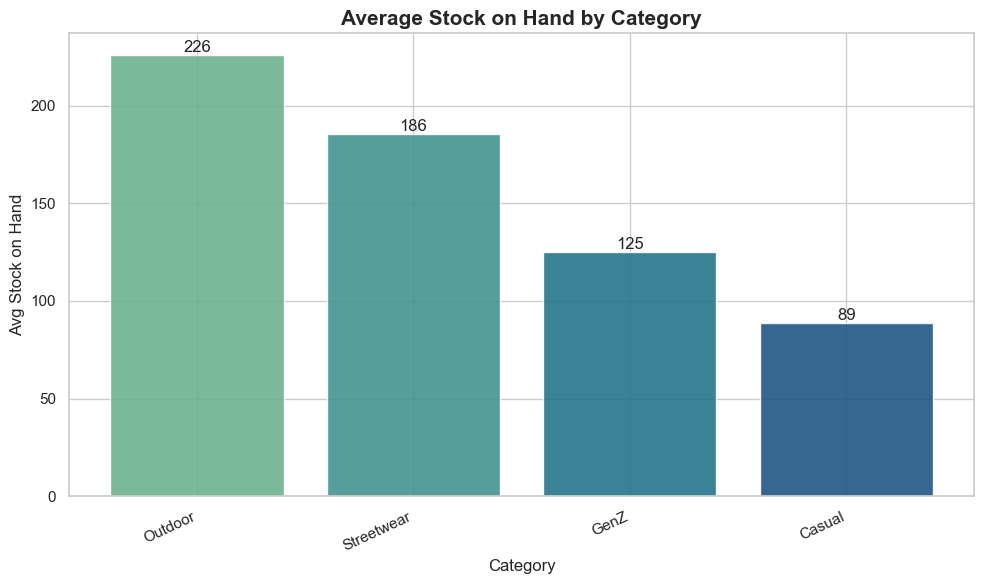

,category,avg_stock_on_hand,total_stock_on_hand,products
2,Outdoor,225.648029,4749891,502
3,Streetwear,185.670342,5759494,890
1,GenZ,125.108472,584757,113
0,Casual,88.644590,310522,119


In [ ]:
category_stock = (
    inventory
    .groupby("category", as_index=False)
    .agg(
        avg_stock_on_hand=("stock_on_hand", "mean"),
        total_stock_on_hand=("stock_on_hand", "sum"),
        products=("product_id", "nunique")
    )
    .sort_values("avg_stock_on_hand", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    category_stock["category"],
    category_stock["avg_stock_on_hand"],
    color=sns.color_palette("crest", n_colors=len(category_stock)),
    alpha=0.9
)

ax.set_title("Average Stock on Hand by Category", fontsize=15, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Avg Stock on Hand")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

for bar, value in zip(bars, category_stock["avg_stock_on_hand"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

category_stock


**Insight gợi ý:** Category có `avg_stock_on_hand` cao nhất là nhóm đang giữ hàng nhiều nhất trên mỗi product/snapshot. Nên đọc cùng `sell_through_rate` và `units_sold` để phân biệt hàng dự trữ hợp lý với overstock.

## Chart 21: Phân phối sell-through rate

Histogram này xem phân phối `sell_through_rate`. Ngưỡng đọc nhanh: `< 0.3` là hàng chết, `0.6-0.8` là healthy, và `>= 0.9` có thể là thiếu hàng / stockout risk.

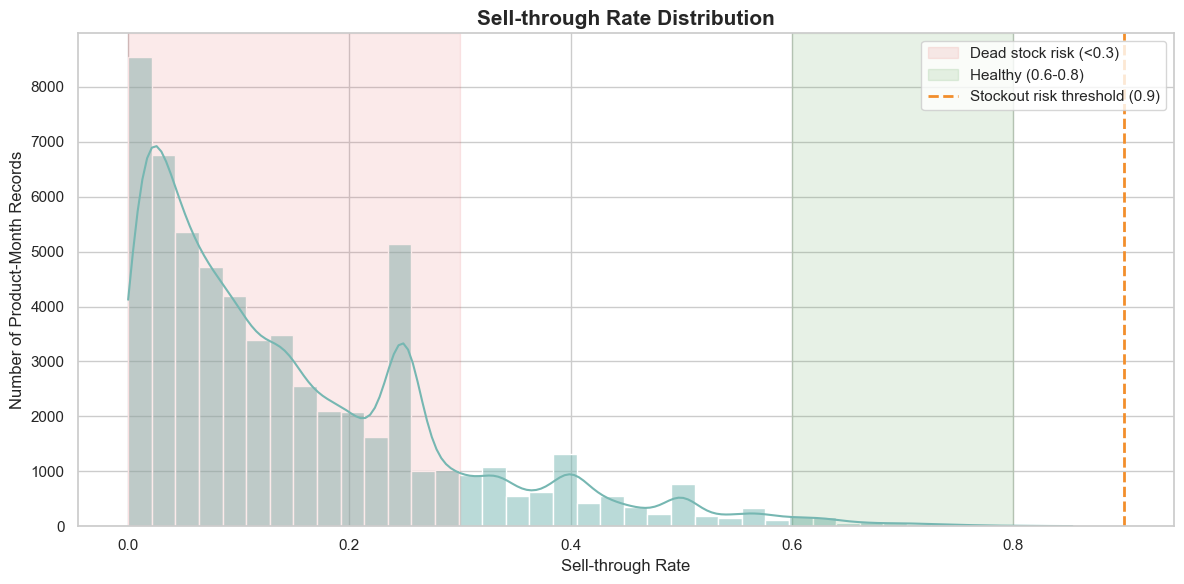

,segment,records,record_share_pct
0,Dead stock risk (<0.3),52007,86.322970
1,Healthy (0.6-0.8),641,1.063953
2,Stockout risk (>=0.9),0,0.000000


In [ ]:
sell_through = inventory["sell_through_rate"].dropna().copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    sell_through,
    bins=40,
    kde=True,
    color="#76b7b2",
    edgecolor="white",
    ax=ax
)

ax.axvspan(0, 0.3, color="#e15759", alpha=0.12, label="Dead stock risk (<0.3)")
ax.axvspan(0.6, 0.8, color="#59a14f", alpha=0.14, label="Healthy (0.6-0.8)")
ax.axvline(0.9, color="#f28e2b", linestyle="--", linewidth=2, label="Stockout risk threshold (0.9)")

ax.set_title("Sell-through Rate Distribution", fontsize=15, weight="bold")
ax.set_xlabel("Sell-through Rate")
ax.set_ylabel("Number of Product-Month Records")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1f}"))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

sell_through_summary = pd.DataFrame({
    "segment": ["Dead stock risk (<0.3)", "Healthy (0.6-0.8)", "Stockout risk (>=0.9)"],
    "records": [
        (sell_through < 0.3).sum(),
        ((sell_through >= 0.6) & (sell_through <= 0.8)).sum(),
        (sell_through >= 0.9).sum()
    ]
})
sell_through_summary["record_share_pct"] = sell_through_summary["records"] / len(sell_through) * 100
sell_through_summary


**Insight gợi ý:** Nếu phần lớn record nằm dưới `0.3`, tồn kho có dấu hiệu chậm quay vòng / hàng chết. Vùng `0.6-0.8` là mức healthy. Nếu nhiều record vượt `0.9`, sản phẩm bán nhanh nhưng có nguy cơ thiếu hàng, nên đối chiếu thêm `stockout_flag` và `stockout_days`.

## Chart 22: Category bán chạy nhất

Mục tiêu là xem category nào bán chạy nhất dựa trên tổng `units_sold`. Chart này giúp ưu tiên category có demand cao để đối chiếu với stock, sell-through và stockout risk.

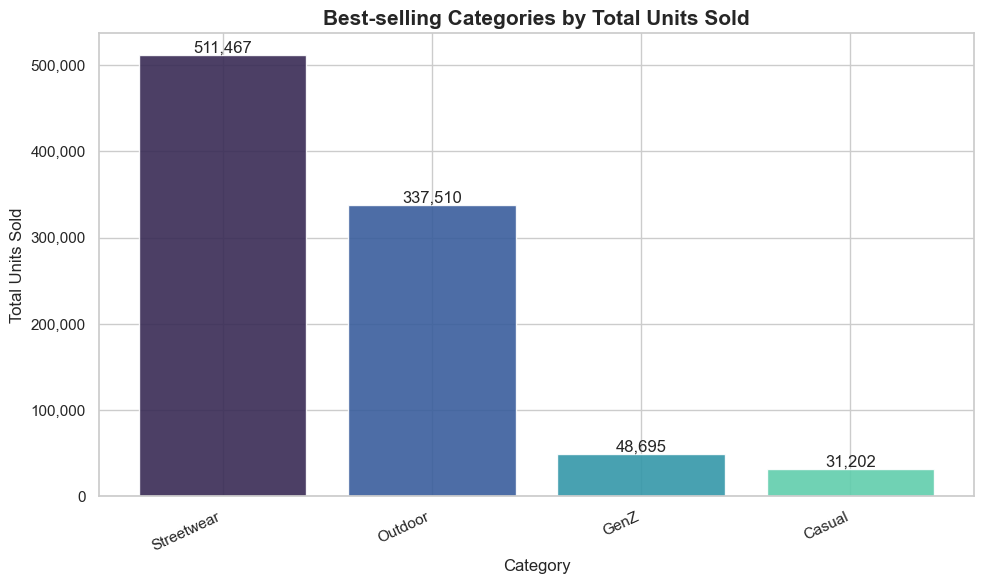

,category,total_units_sold,avg_units_sold,products
3,Streetwear,511467,16.488298,890
2,Outdoor,337510,16.033729,502
1,GenZ,48695,10.418271,113
0,Casual,31202,8.907222,119


In [ ]:
category_sales = (
    inventory
    .groupby("category", as_index=False)
    .agg(
        total_units_sold=("units_sold", "sum"),
        avg_units_sold=("units_sold", "mean"),
        products=("product_id", "nunique")
    )
    .sort_values("total_units_sold", ascending=False)
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    category_sales["category"],
    category_sales["total_units_sold"],
    color=sns.color_palette("mako", n_colors=len(category_sales)),
    alpha=0.9
)

ax.set_title("Best-selling Categories by Total Units Sold", fontsize=15, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Total Units Sold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

for bar, value in zip(bars, category_sales["total_units_sold"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

category_sales


**Insight gợi ý:** Category có `total_units_sold` cao nhất là nhóm bán chạy nhất về volume. Nếu category này đồng thời có sell-through cao và stock thấp, cần ưu tiên replenishment; nếu stock cao nhưng units sold cao tương xứng, đó có thể là tồn kho phục vụ demand thật.

## Chart 23: Sell-through theo category

Mục tiêu là kiểm tra category nào có sell-through thấp, đặc biệt để xác nhận `Outdoor` có đang bị hàng chết hay không.

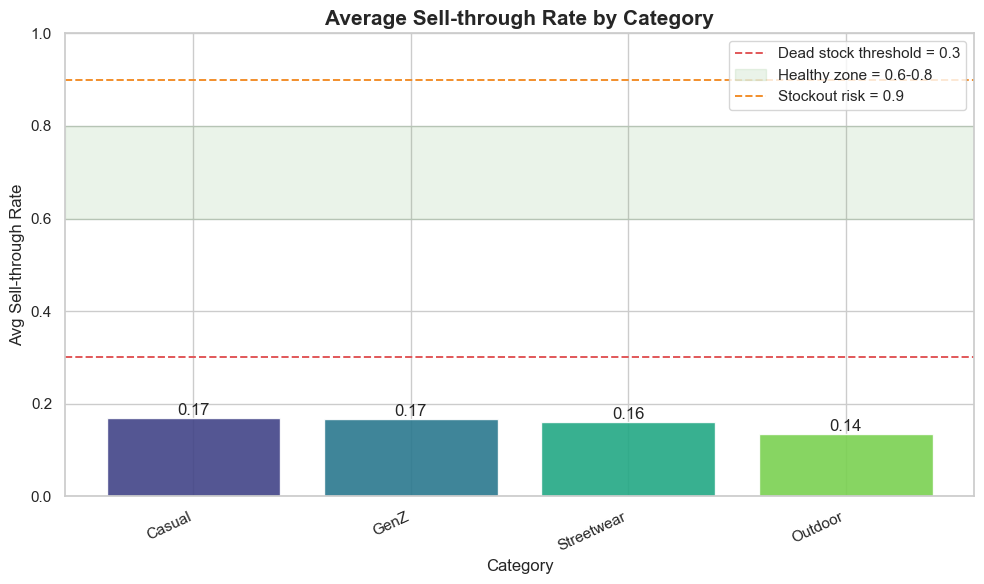

,category,avg_sell_through,median_sell_through,records,total_units_sold,total_stock_on_hand
0,Casual,0.168390,0.1333,3503,31202,310522
1,GenZ,0.167978,0.1250,4674,48695,584757
3,Streetwear,0.159754,0.1205,31020,511467,5759494
2,Outdoor,0.135084,0.0909,21050,337510,4749891


In [ ]:
required_inventory_cols = {
    "snapshot_date",
    "product_id",
    "category",
    "stock_on_hand",
    "units_sold",
    "stockout_days",
    "overstock_flag",
    "sell_through_rate"
}
if "inventory" not in globals() or not required_inventory_cols.issubset(inventory.columns):
    from pathlib import Path

    import matplotlib.pyplot as plt
    import pandas as pd
    import seaborn as sns

    inventory_path = Path("data/raw/inventory.csv")
    if not inventory_path.exists():
        inventory_path = Path("..") / inventory_path

    inventory = pd.read_csv(
        inventory_path,
        usecols=[
            "snapshot_date",
            "product_id",
            "category",
            "stock_on_hand",
            "units_sold",
            "stockout_days",
            "overstock_flag",
            "sell_through_rate"
        ]
    )
    inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])
    inventory["month"] = inventory["snapshot_date"].dt.to_period("M").dt.to_timestamp()

sell_through_by_category = (
    inventory
    .groupby("category", as_index=False)
    .agg(
        avg_sell_through=("sell_through_rate", "mean"),
        median_sell_through=("sell_through_rate", "median"),
        records=("product_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_stock_on_hand=("stock_on_hand", "sum")
    )
    .sort_values("avg_sell_through", ascending=False)
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    sell_through_by_category["category"],
    sell_through_by_category["avg_sell_through"],
    color=sns.color_palette("viridis", n_colors=len(sell_through_by_category)),
    alpha=0.9
)

ax.axhline(0.3, color="#e15759", linestyle="--", linewidth=1.4, label="Dead stock threshold = 0.3")
ax.axhspan(0.6, 0.8, color="#59a14f", alpha=0.12, label="Healthy zone = 0.6-0.8")
ax.axhline(0.9, color="#f28e2b", linestyle="--", linewidth=1.4, label="Stockout risk = 0.9")

ax.set_title("Average Sell-through Rate by Category", fontsize=15, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Avg Sell-through Rate")
ax.set_ylim(0, max(1.0, sell_through_by_category["avg_sell_through"].max() * 1.15))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1f}"))
ax.legend(loc="upper right")

for bar, value in zip(bars, sell_through_by_category["avg_sell_through"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

sell_through_by_category


## Chart 24: Stockout days so với units sold

Kiểm tra liệu có lost demand hay không. Những điểm có `stockout_days` cao và `units_sold` cao là nhóm đang bán tốt nhưng có nguy cơ mất thêm doanh thu do hết hàng.

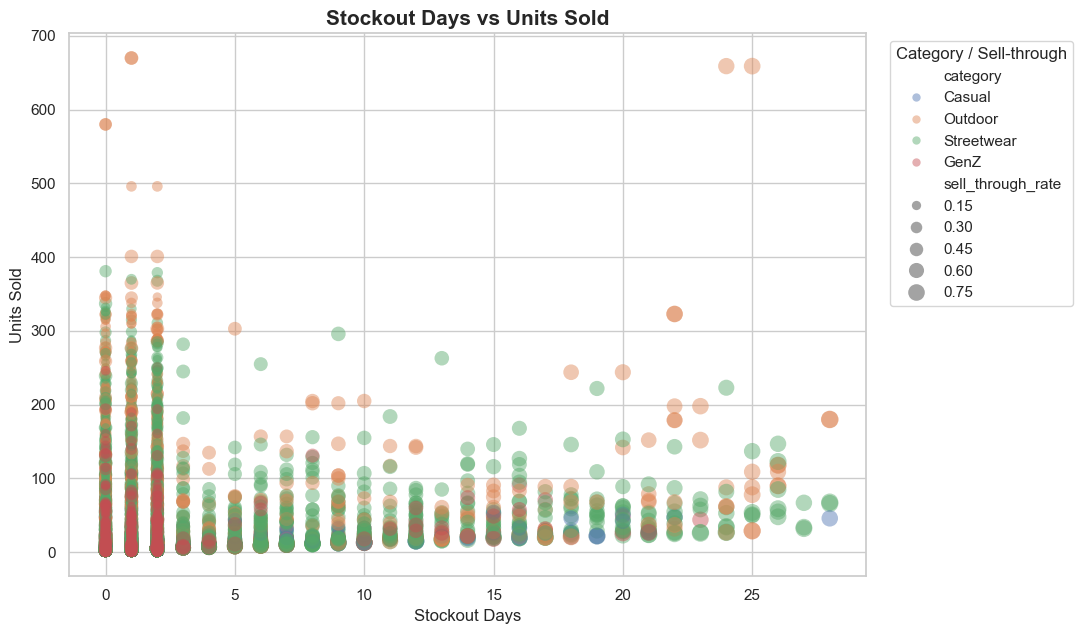

,category,records,stockout_records,total_stockout_days,total_units_sold,avg_units_sold,stockout_record_pct
3,Streetwear,31020,20883,36993,511467,16.488298,67.321083
2,Outdoor,21050,14177,23552,337510,16.033729,67.349169
1,GenZ,4674,3192,5368,48695,10.418271,68.292683
0,Casual,3503,2319,4012,31202,8.907222,66.200400


In [ ]:
required_inventory_cols = {
    "snapshot_date",
    "product_id",
    "category",
    "stock_on_hand",
    "units_sold",
    "stockout_days",
    "overstock_flag",
    "sell_through_rate"
}
if "inventory" not in globals() or not required_inventory_cols.issubset(inventory.columns):
    from pathlib import Path

    import matplotlib.pyplot as plt
    import pandas as pd
    import seaborn as sns

    inventory_path = Path("data/raw/inventory.csv")
    if not inventory_path.exists():
        inventory_path = Path("..") / inventory_path

    inventory = pd.read_csv(
        inventory_path,
        usecols=[
            "snapshot_date",
            "product_id",
            "category",
            "stock_on_hand",
            "units_sold",
            "stockout_days",
            "overstock_flag",
            "sell_through_rate"
        ]
    )
    inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])
    inventory["month"] = inventory["snapshot_date"].dt.to_period("M").dt.to_timestamp()

stockout_sales = inventory[
    ["category", "product_id", "stockout_days", "units_sold", "sell_through_rate"]
].dropna().copy()

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.scatterplot(
    data=stockout_sales,
    x="stockout_days",
    y="units_sold",
    hue="category",
    size="sell_through_rate",
    sizes=(20, 160),
    alpha=0.45,
    edgecolor="none",
    ax=ax
)

ax.set_title("Stockout Days vs Units Sold", fontsize=15, weight="bold")
ax.set_xlabel("Stockout Days")
ax.set_ylabel("Units Sold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.legend(title="Category / Sell-through", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

stockout_risk_summary = (
    stockout_sales
    .assign(high_stockout=stockout_sales["stockout_days"] > 0)
    .groupby("category", as_index=False)
    .agg(
        records=("product_id", "count"),
        stockout_records=("high_stockout", "sum"),
        total_stockout_days=("stockout_days", "sum"),
        total_units_sold=("units_sold", "sum"),
        avg_units_sold=("units_sold", "mean")
    )
)
stockout_risk_summary["stockout_record_pct"] = (
    stockout_risk_summary["stockout_records"] / stockout_risk_summary["records"] * 100
)
stockout_risk_summary.sort_values(["total_stockout_days", "total_units_sold"], ascending=False)


# Đào Sâu Traffic Source và Chất Lượng Channel

Kiểm tra kênh/source nào đang mang về đúng tập khách hàng mục tiêu thông qua các chỉ số như conversion rate, AOV, mức độ engagement, chân dung khách hàng, tỷ lệ quay lại, đóng góp doanh thu và sở thích sản phẩm.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

traffic_path = Path("data/raw/web_traffic.csv")
orders_path = Path("data/raw/orders.csv")
customers_path = Path("data/raw/customers.csv")
master_path = Path("data/output/master_table.csv")

if not traffic_path.exists():
    traffic_path = Path("..") / traffic_path
    orders_path = Path("..") / orders_path
    customers_path = Path("..") / customers_path
    master_path = Path("..") / master_path

traffic = pd.read_csv(
    traffic_path,
    usecols=[
        "date",
        "traffic_source",
        "sessions",
        "page_views",
        "bounce_rate",
        "avg_session_duration_sec"
    ]
)
orders = pd.read_csv(
    orders_path,
    usecols=["order_id", "order_date", "customer_id", "order_status", "order_source"]
)
customers = pd.read_csv(
    customers_path,
    usecols=["customer_id", "gender", "age_group", "acquisition_channel"]
)
master = pd.read_csv(
    master_path,
    usecols=[
        "order_id",
        "order_item_id",
        "customer_id",
        "order_status",
        "order_source",
        "category",
        "segment",
        "quantity",
        "line_revenue"
    ]
)

traffic["date"] = pd.to_datetime(traffic["date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])
master = master.drop_duplicates(subset=["order_item_id"]).copy()

traffic_start = traffic["date"].min()
traffic_end = traffic["date"].max()

valid_statuses = ["paid", "shipped", "delivered", "returned"]
orders_valid = orders[
    orders["order_status"].isin(valid_statuses)
    & orders["order_date"].between(traffic_start, traffic_end)
].copy()
master_valid = master[
    master["order_status"].isin(valid_statuses)
    & master["order_id"].isin(orders_valid["order_id"])
].copy()

traffic["weighted_bounce"] = traffic["bounce_rate"] * traffic["sessions"]
traffic["weighted_duration"] = traffic["avg_session_duration_sec"] * traffic["sessions"]

traffic_source_summary = (
    traffic
    .groupby("traffic_source", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        total_page_views=("page_views", "sum"),
        weighted_bounce=("weighted_bounce", "sum"),
        weighted_duration=("weighted_duration", "sum")
    )
)
traffic_source_summary["bounce_rate"] = traffic_source_summary["weighted_bounce"] / traffic_source_summary["sessions"]
traffic_source_summary["avg_session_duration_sec"] = traffic_source_summary["weighted_duration"] / traffic_source_summary["sessions"]
traffic_source_summary["pages_per_session"] = traffic_source_summary["total_page_views"] / traffic_source_summary["sessions"]

orders_by_source = (
    orders_valid
    .groupby("order_source", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .rename(columns={"order_source": "traffic_source"})
)

order_level_source = (
    master_valid
    .groupby(["order_id", "order_source", "customer_id"], as_index=False)
    .agg(
        order_revenue=("line_revenue", "sum"),
        order_quantity=("quantity", "sum")
    )
)

source_value = (
    order_level_source
    .groupby("order_source", as_index=False)
    .agg(
        revenue=("order_revenue", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique"),
        total_quantity=("order_quantity", "sum")
    )
)
source_value["aov"] = source_value["revenue"] / source_value["orders"]

conversion_by_source = (
    traffic_source_summary
    .merge(orders_by_source, on="traffic_source", how="left", validate="one_to_one")
    .fillna({"orders": 0, "customers": 0})
)
conversion_by_source["conversion_rate"] = conversion_by_source["orders"] / conversion_by_source["sessions"] * 100

repeat_by_source = (
    order_level_source
    .groupby(["order_source", "customer_id"], as_index=False)
    .agg(order_count=("order_id", "nunique"))
)
repeat_by_source["is_repeat"] = repeat_by_source["order_count"] > 1
repeat_summary = (
    repeat_by_source
    .groupby("order_source", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        repeat_customers=("is_repeat", "sum")
    )
)
repeat_summary["repeat_rate_pct"] = repeat_summary["repeat_customers"] / repeat_summary["customers"] * 100

revenue_traffic_share = (
    traffic_source_summary[["traffic_source", "sessions"]]
    .merge(
        source_value[["order_source", "revenue"]].rename(columns={"order_source": "traffic_source"}),
        on="traffic_source",
        how="left",
        validate="one_to_one"
    )
    .fillna({"revenue": 0})
)
revenue_traffic_share["traffic_share_pct"] = revenue_traffic_share["sessions"] / revenue_traffic_share["sessions"].sum() * 100
revenue_traffic_share["revenue_share_pct"] = revenue_traffic_share["revenue"] / revenue_traffic_share["revenue"].sum() * 100
revenue_traffic_share["traffic_minus_revenue_pp"] = (
    revenue_traffic_share["traffic_share_pct"] - revenue_traffic_share["revenue_share_pct"]
)

product_pref = (
    master_valid
    .groupby(["order_source", "category"], as_index=False)
    .agg(quantity=("quantity", "sum"))
)
product_pref["category_share_pct"] = product_pref.groupby("order_source")["quantity"].transform(lambda s: s / s.sum() * 100)

traffic.head(), orders_valid.head(), source_value.head()


(        date  sessions  page_views  bounce_rate  avg_session_duration_sec  \
 0 2013-01-01      9760       39093      0.00514                     102.9   
 1 2013-01-02     10456       47611      0.00406                     120.5   
 2 2013-01-03     10076       36963      0.00401                     263.6   
 3 2013-01-04      9973       53078      0.00562                     151.8   
 4 2013-01-05     10223       36790      0.00525                     168.6   
 
    traffic_source  weighted_bounce  weighted_duration  
 0  organic_search         50.16640          1004304.0  
 1  organic_search         42.45136          1259948.0  
 2          direct         40.40476          2656033.6  
 3          direct         56.04826          1513901.4  
 4        referral         53.67075          1723597.8  ,
        order_id order_date  customer_id order_status    order_source
 30916     39924 2013-01-01        58586    delivered          direct
 30922     39933 2013-01-01        58822    del

## Chart 25: Conversion rate theo traffic source

Metric: `conversion_rate = orders / sessions`. Sessions lấy từ `web_traffic.traffic_source`, orders lấy từ `orders.order_source` với các status hợp lệ.

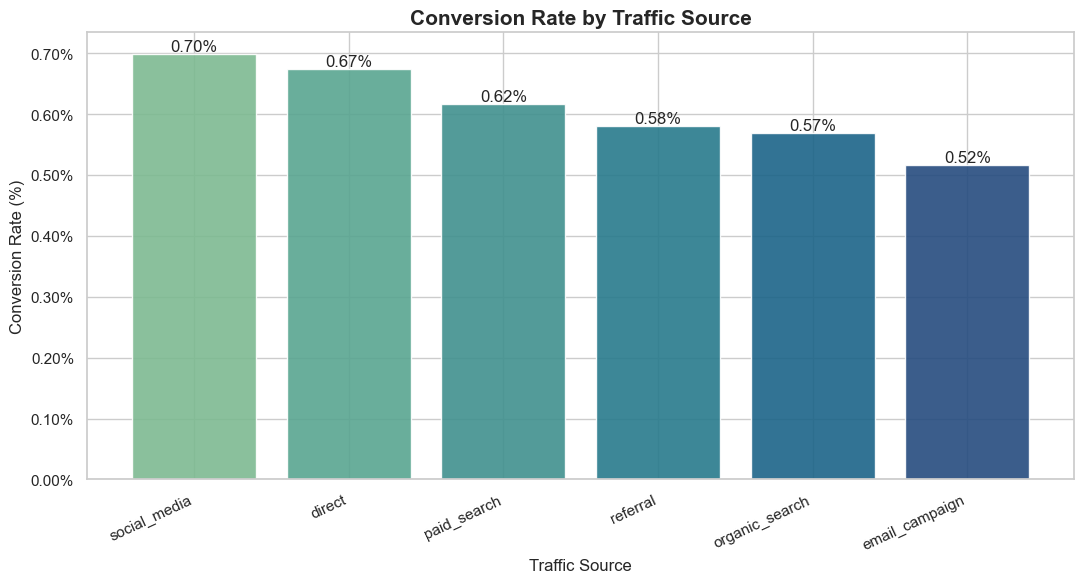

,traffic_source,sessions,orders,conversion_rate
5,social_media,15816226,110593,0.699238
0,direct,6571549,44270,0.673662
3,paid_search,19598271,120828,0.616524
4,referral,9476845,54977,0.580119
2,organic_search,27196976,154647,0.568618
1,email_campaign,12792670,66056,0.516358


In [ ]:
plot_df = conversion_by_source.sort_values("conversion_rate", ascending=False).copy()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(
    plot_df["traffic_source"],
    plot_df["conversion_rate"],
    color=sns.color_palette("crest", n_colors=len(plot_df)),
    alpha=0.9
)

ax.set_title("Conversion Rate by Traffic Source", fontsize=15, weight="bold")
ax.set_xlabel("Traffic Source")
ax.set_ylabel("Conversion Rate (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.2f}%"))

for bar, value in zip(bars, plot_df["conversion_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.2f}%", ha="center", va="bottom")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plot_df[["traffic_source", "sessions", "orders", "conversion_rate"]]


## Chart 26: AOV theo traffic source

Metric: `AOV = revenue / orders` ở mức order, nhóm theo `order_source`.

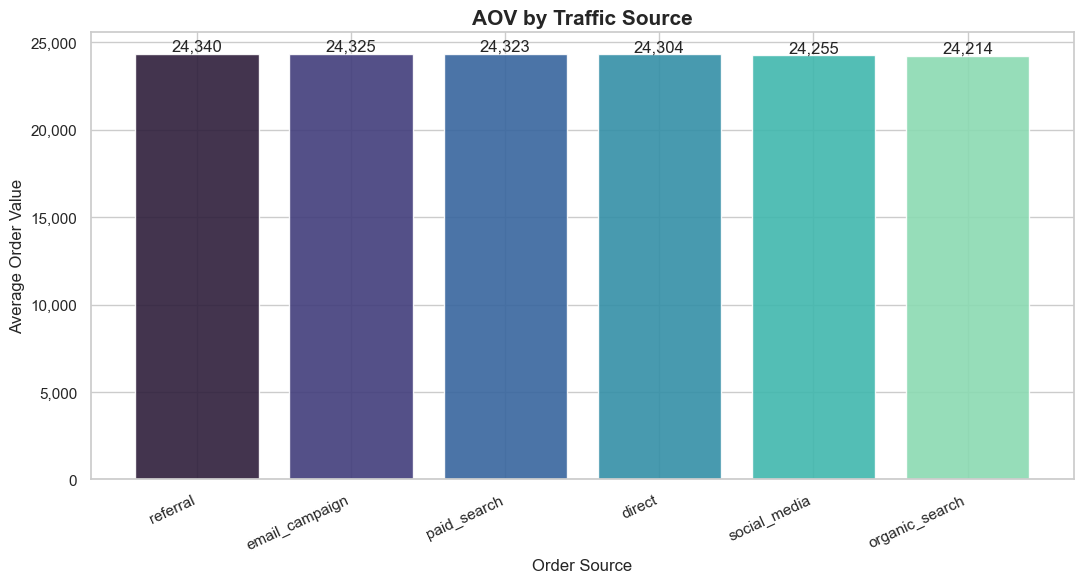

,order_source,revenue,orders,aov
4,referral,1.338123e+09,54977,24339.684068
1,email_campaign,1.606834e+09,66056,24325.333875
3,paid_search,2.938954e+09,120828,24323.451939
0,direct,1.075949e+09,44270,24304.257020
5,social_media,2.682461e+09,110593,24255.248137
2,organic_search,3.744643e+09,154647,24214.130627


In [ ]:
plot_df = source_value.sort_values("aov", ascending=False).copy()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(
    plot_df["order_source"],
    plot_df["aov"],
    color=sns.color_palette("mako", n_colors=len(plot_df)),
    alpha=0.9
)

ax.set_title("AOV by Traffic Source", fontsize=15, weight="bold")
ax.set_xlabel("Order Source")
ax.set_ylabel("Average Order Value")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

for bar, value in zip(bars, plot_df["aov"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:,.0f}", ha="center", va="bottom")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plot_df[["order_source", "revenue", "orders", "aov"]]


## Chart 27: Bounce rate và engagement theo source

Metric: `bounce_rate`, `avg_session_duration_sec` và `pages_per_session = page_views / sessions` theo `traffic_source`.

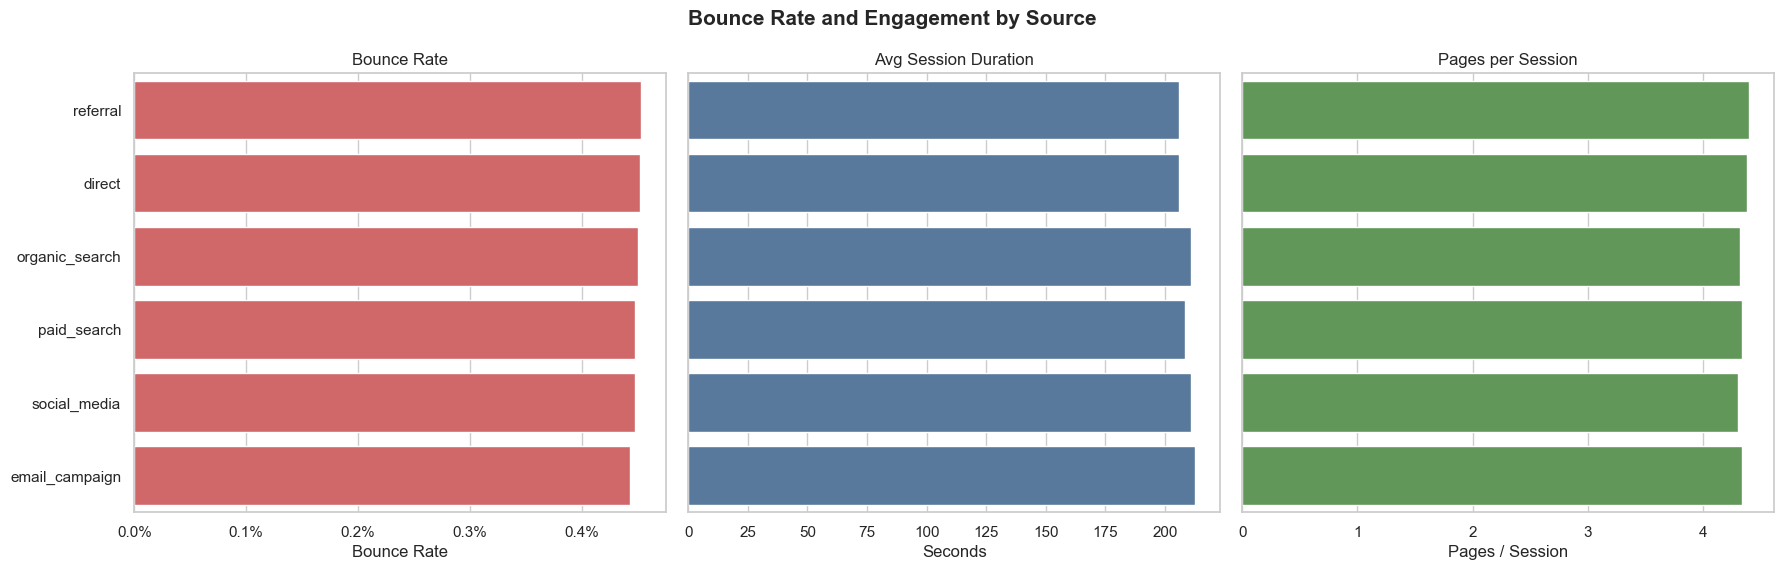

,traffic_source,bounce_rate,avg_session_duration_sec,pages_per_session,total_page_views
4,referral,0.004527,205.884001,4.395520,41655659
0,direct,0.004521,206.063222,4.378171,28771362
2,organic_search,0.004498,211.081127,4.324247,117606452
3,paid_search,0.004479,208.268099,4.341176,85079551
5,social_media,0.004475,210.978902,4.303943,68072140
1,email_campaign,0.004435,212.459891,4.336674,55477636


In [ ]:
engagement_plot = traffic_source_summary.sort_values("bounce_rate", ascending=False).copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), sharey=True)

sns.barplot(data=engagement_plot, x="bounce_rate", y="traffic_source", color="#e15759", ax=axes[0])
axes[0].set_title("Bounce Rate")
axes[0].set_xlabel("Bounce Rate")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}" if value <= 1 else f"{value:.0f}"))

sns.barplot(data=engagement_plot, x="avg_session_duration_sec", y="traffic_source", color="#4e79a7", ax=axes[1])
axes[1].set_title("Avg Session Duration")
axes[1].set_xlabel("Seconds")

sns.barplot(data=engagement_plot, x="pages_per_session", y="traffic_source", color="#59a14f", ax=axes[2])
axes[2].set_title("Pages per Session")
axes[2].set_xlabel("Pages / Session")

for ax in axes:
    ax.set_ylabel("")

fig.suptitle("Bounce Rate and Engagement by Source", fontsize=15, weight="bold")
plt.tight_layout()
plt.show()

engagement_plot[["traffic_source", "bounce_rate", "avg_session_duration_sec", "pages_per_session", "total_page_views"]]


## Chart 28: Customer profile theo acquisition channel

Dùng stacked bar để xem mỗi acquisition_channel đang thu hút tập khách hàng nào theo age_group và gender.

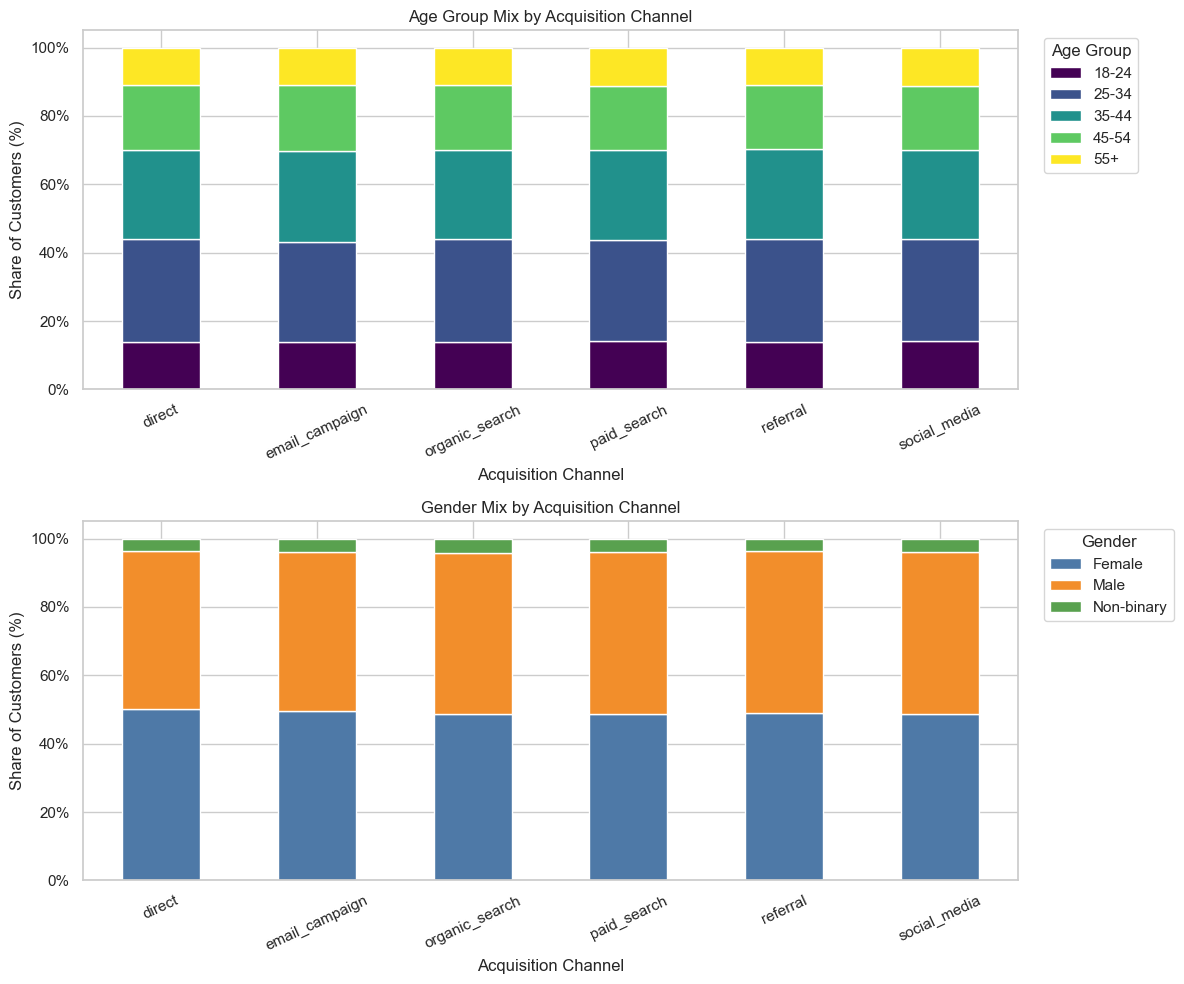

,acquisition_channel,age_group,customers,share_pct
1,direct,25-34,2941,30.001020
2,direct,35-44,2560,26.114455
3,direct,45-54,1848,18.851372
0,direct,18-24,1367,13.944711
4,direct,55+,1087,11.088442
6,email_campaign,25-34,4311,29.378493
7,email_campaign,35-44,3884,26.468584
8,email_campaign,45-54,2835,19.319886
5,email_campaign,18-24,2027,13.813548
9,email_campaign,55+,1617,11.019490


In [ ]:
profile_base = customers.dropna(subset=["acquisition_channel", "age_group", "gender"]).copy()

age_profile = (
    profile_base
    .groupby(["acquisition_channel", "age_group"], as_index=False)
    .agg(customers=("customer_id", "nunique"))
)
age_profile["share_pct"] = age_profile.groupby("acquisition_channel")["customers"].transform(lambda s: s / s.sum() * 100)
age_wide = age_profile.pivot(index="acquisition_channel", columns="age_group", values="share_pct").fillna(0)

gender_profile = (
    profile_base
    .groupby(["acquisition_channel", "gender"], as_index=False)
    .agg(customers=("customer_id", "nunique"))
)
gender_profile["share_pct"] = gender_profile.groupby("acquisition_channel")["customers"].transform(lambda s: s / s.sum() * 100)
gender_wide = gender_profile.pivot(index="acquisition_channel", columns="gender", values="share_pct").fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
age_wide.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("Age Group Mix by Acquisition Channel")
axes[0].set_xlabel("Acquisition Channel")
axes[0].set_ylabel("Share of Customers (%)")
axes[0].legend(title="Age Group", bbox_to_anchor=(1.02, 1), loc="upper left")

gender_wide.plot(kind="bar", stacked=True, ax=axes[1], color=["#4e79a7", "#f28e2b", "#59a14f"])
axes[1].set_title("Gender Mix by Acquisition Channel")
axes[1].set_xlabel("Acquisition Channel")
axes[1].set_ylabel("Share of Customers (%)")
axes[1].legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")

for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

age_profile.sort_values(["acquisition_channel", "share_pct"], ascending=[True, False]).head(20)


## Chart 29: Repeat rate theo channel

Metric: `% khách có >1 order` trong từng `order_source`.

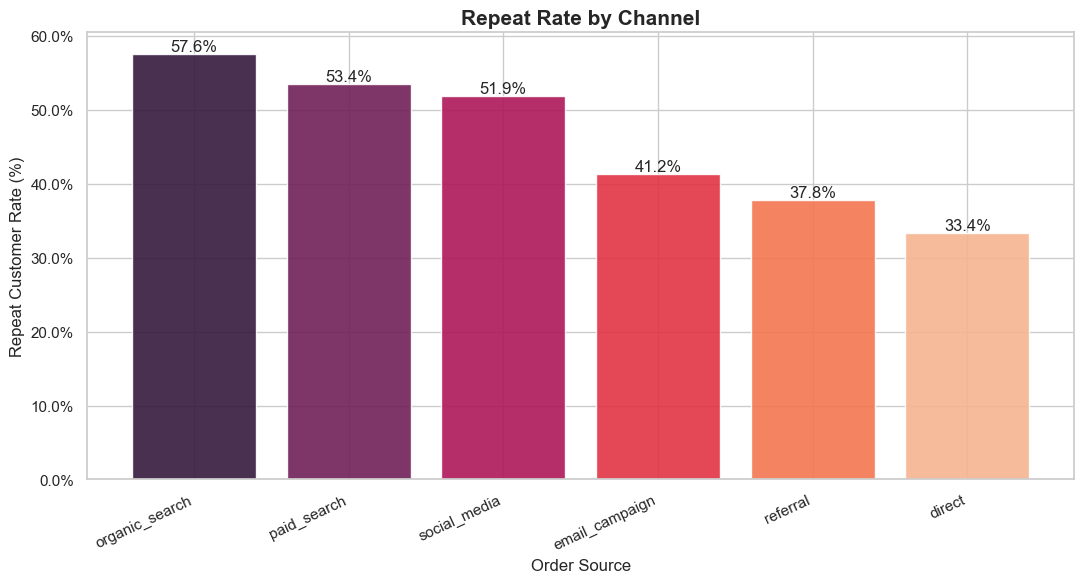

,order_source,customers,repeat_customers,repeat_rate_pct
2,organic_search,56830,32725,57.584023
3,paid_search,50693,27082,53.423550
5,social_media,48683,25253,51.872317
1,email_campaign,36989,15257,41.247398
4,referral,33094,12510,37.801414
0,direct,28775,9606,33.383145


In [ ]:
plot_df = repeat_summary.sort_values("repeat_rate_pct", ascending=False).copy()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(
    plot_df["order_source"],
    plot_df["repeat_rate_pct"],
    color=sns.color_palette("rocket", n_colors=len(plot_df)),
    alpha=0.9
)

ax.set_title("Repeat Rate by Channel", fontsize=15, weight="bold")
ax.set_xlabel("Order Source")
ax.set_ylabel("Repeat Customer Rate (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1f}%"))

for bar, value in zip(bars, plot_df["repeat_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1f}%", ha="center", va="bottom")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plot_df


## Chart 30: Revenue share so với traffic share

So sánh % sessions và % revenue theo từng traffic_source để xác định nguồn nào mang về nhiều traffic nhưng đóng góp doanh thu không tương xứng.

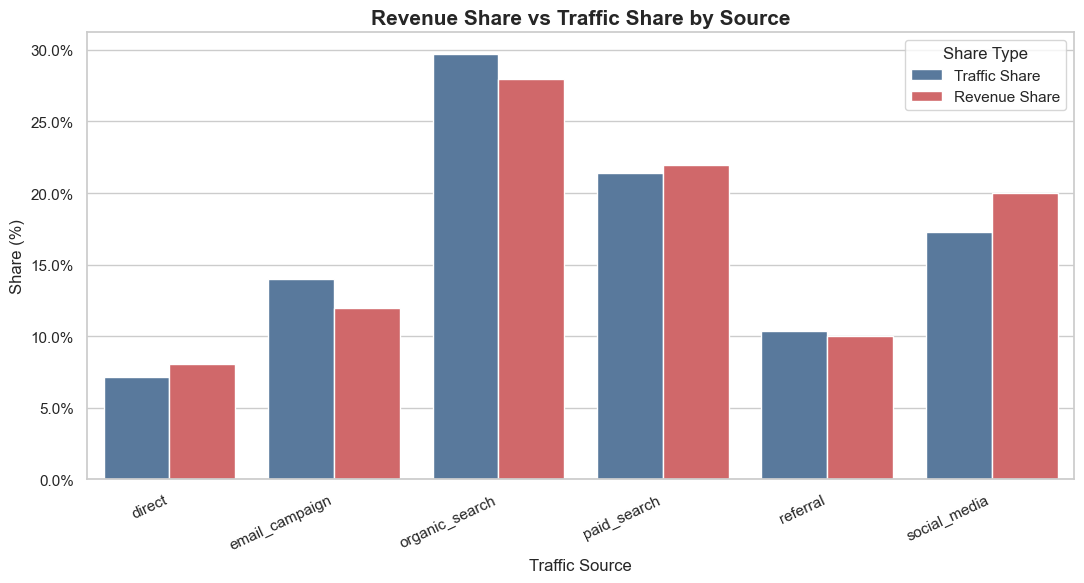

,traffic_source,sessions,revenue,traffic_share_pct,revenue_share_pct,traffic_minus_revenue_pp
1,email_campaign,12792670,1.606834e+09,13.988316,12.002977,1.985339
2,organic_search,27196976,3.744643e+09,29.738897,27.972307,1.766590
4,referral,9476845,1.338123e+09,10.362583,9.995715,0.366868
3,paid_search,19598271,2.938954e+09,21.429992,21.953851,-0.523859
0,direct,6571549,1.075949e+09,7.185748,8.037293,-0.851544
5,social_media,15816226,2.682461e+09,17.294464,20.037857,-2.743393


In [ ]:
plot_df = revenue_traffic_share.melt(
    id_vars="traffic_source",
    value_vars=["traffic_share_pct", "revenue_share_pct"],
    var_name="share_type",
    value_name="share_pct"
)
plot_df["share_type"] = plot_df["share_type"].map({
    "traffic_share_pct": "Traffic Share",
    "revenue_share_pct": "Revenue Share"
})

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=plot_df,
    x="traffic_source",
    y="share_pct",
    hue="share_type",
    palette={"Traffic Share": "#4e79a7", "Revenue Share": "#e15759"},
    ax=ax
)

ax.set_title("Revenue Share vs Traffic Share by Source", fontsize=15, weight="bold")
ax.set_xlabel("Traffic Source")
ax.set_ylabel("Share (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1f}%"))
ax.legend(title="Share Type")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

revenue_traffic_share.sort_values("traffic_minus_revenue_pp", ascending=False)


## Chart 31: Product preference theo channel

Dùng stacked bar theo `order_source` và `category` để xem mỗi kênh đang mua nhiều hơn ở nhóm sản phẩm nào.

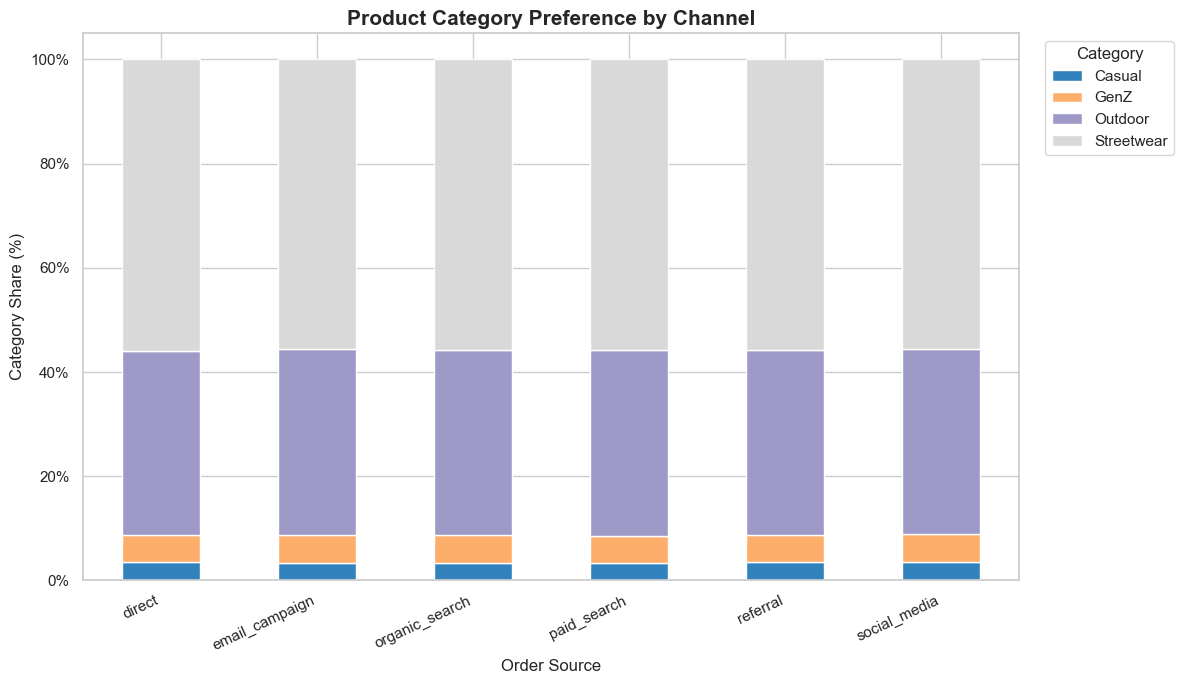

,order_source,category,quantity,category_share_pct
3,direct,Streetwear,122655,56.001991
2,direct,Outdoor,77163,35.231190
1,direct,GenZ,11525,5.262101
0,direct,Casual,7676,3.504719
7,email_campaign,Streetwear,182768,55.607684
6,email_campaign,Outdoor,117402,35.719893
5,email_campaign,GenZ,17346,5.277570
4,email_campaign,Casual,11158,3.394853
11,organic_search,Streetwear,426708,55.717061
10,organic_search,Outdoor,272865,35.629133


In [ ]:
product_pref_wide = (
    product_pref
    .pivot(index="order_source", columns="category", values="category_share_pct")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 7))
product_pref_wide.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab20c"
)

ax.set_title("Product Category Preference by Channel", fontsize=15, weight="bold")
ax.set_xlabel("Order Source")
ax.set_ylabel("Category Share (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

product_pref.sort_values(["order_source", "category_share_pct"], ascending=[True, False]).head(24)


# Đào Sâu Chẩn Đoán Inventory

Mục tiêu là đào sâu phân tích inventory theo category và SKU để xác định overstock đang nằm ở đâu, doanh nghiệp đang overbuy (nhập dư) hay forecast bị lệch, và liệu nhu cầu có đang phụ thuộc vào promo hay không.

In [ ]:
required_inventory_diag_cols = {
    "snapshot_date",
    "product_id",
    "product_name",
    "category",
    "stock_on_hand",
    "units_sold",
    "stockout_flag",
    "overstock_flag",
    "days_of_supply",
    "fill_rate",
    "sell_through_rate"
}

if "inventory_diag" not in globals() or not required_inventory_diag_cols.issubset(inventory_diag.columns):
    from pathlib import Path

    import matplotlib.pyplot as plt
    import pandas as pd
    import seaborn as sns

    inventory_diag_path = Path("data/raw/inventory.csv")
    if not inventory_diag_path.exists():
        inventory_diag_path = Path("..") / inventory_diag_path

    inventory_diag = pd.read_csv(
        inventory_diag_path,
        usecols=[
            "snapshot_date",
            "product_id",
            "product_name",
            "category",
            "stock_on_hand",
            "units_sold",
            "stockout_flag",
            "overstock_flag",
            "days_of_supply",
            "fill_rate",
            "sell_through_rate"
        ]
    )
    inventory_diag["snapshot_date"] = pd.to_datetime(inventory_diag["snapshot_date"])
    inventory_diag["month"] = inventory_diag["snapshot_date"].dt.to_period("M").dt.to_timestamp()

inventory_diag = inventory_diag.dropna(subset=["category", "product_id"]).copy()
inventory_diag["stockout_flag"] = inventory_diag["stockout_flag"].fillna(0)
inventory_diag["overstock_flag"] = inventory_diag["overstock_flag"].fillna(0)

category_diag = (
    inventory_diag
    .groupby("category", as_index=False)
    .agg(
        avg_sell_through_rate=("sell_through_rate", "mean"),
        median_sell_through_rate=("sell_through_rate", "median"),
        avg_stock_on_hand=("stock_on_hand", "mean"),
        avg_units_sold=("units_sold", "mean"),
        total_stock_on_hand=("stock_on_hand", "sum"),
        total_units_sold=("units_sold", "sum"),
        avg_days_of_supply=("days_of_supply", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
        overstock_rate=("overstock_flag", "mean"),
        stockout_rate=("stockout_flag", "mean")
    )
)
category_diag["overstock_rate_pct"] = category_diag["overstock_rate"] * 100
category_diag["stockout_rate_pct"] = category_diag["stockout_rate"] * 100

category_monthly_diag = (
    inventory_diag
    .groupby(["month", "category"], as_index=False)
    .agg(
        stock_on_hand=("stock_on_hand", "sum"),
        units_sold=("units_sold", "sum"),
        avg_sell_through_rate=("sell_through_rate", "mean"),
        avg_days_of_supply=("days_of_supply", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
        overstock_rate=("overstock_flag", "mean"),
        stockout_rate=("stockout_flag", "mean")
    )
)
category_monthly_diag["overstock_rate_pct"] = category_monthly_diag["overstock_rate"] * 100
category_monthly_diag["stockout_rate_pct"] = category_monthly_diag["stockout_rate"] * 100

dead_stock_sku = (
    inventory_diag
    .groupby(["product_id", "product_name", "category"], as_index=False)
    .agg(
        avg_stock_on_hand=("stock_on_hand", "mean"),
        total_stock_on_hand=("stock_on_hand", "sum"),
        avg_sell_through_rate=("sell_through_rate", "mean"),
        avg_days_of_supply=("days_of_supply", "mean"),
        avg_units_sold=("units_sold", "mean")
    )
)
dead_stock_sku["dead_stock_score"] = dead_stock_sku["total_stock_on_hand"] * (1 - dead_stock_sku["avg_sell_through_rate"].clip(upper=1))
dead_stock_sku = dead_stock_sku.sort_values(["dead_stock_score", "avg_sell_through_rate"], ascending=[False, True])

required_master_promo_cols = {
    "order_item_id",
    "order_date",
    "category",
    "quantity",
    "promo_id",
    "order_status"
}
if "inventory_promo_base" not in globals() or not required_master_promo_cols.issubset(inventory_promo_base.columns):
    inventory_promo_master_path = Path("data/output/master_table.csv")
    if not inventory_promo_master_path.exists():
        inventory_promo_master_path = Path("..") / inventory_promo_master_path

    inventory_promo_base = pd.read_csv(
        inventory_promo_master_path,
        usecols=["order_item_id", "order_date", "category", "quantity", "promo_id", "order_status"]
    )
    inventory_promo_base = inventory_promo_base.drop_duplicates(subset=["order_item_id"]).copy()
    inventory_promo_base["order_date"] = pd.to_datetime(inventory_promo_base["order_date"])

valid_statuses = ["paid", "shipped", "delivered", "returned"]
inventory_promo_base = inventory_promo_base[inventory_promo_base["order_status"].isin(valid_statuses)].copy()
inventory_promo_base["month"] = inventory_promo_base["order_date"].dt.to_period("M").dt.to_timestamp()
inventory_promo_base["promo_group"] = inventory_promo_base["promo_id"].notna().map({True: "Promo", False: "Non-promo"})

promo_units_by_category = (
    inventory_promo_base
    .groupby(["category", "promo_group"], as_index=False)
    .agg(units_sold=("quantity", "sum"))
)
promo_units_by_category["units_share_pct"] = promo_units_by_category.groupby("category")["units_sold"].transform(lambda s: s / s.sum() * 100)

category_diag.sort_values("avg_sell_through_rate")


,category,avg_sell_through_rate,median_sell_through_rate,avg_stock_on_hand,avg_units_sold,total_stock_on_hand,total_units_sold,avg_days_of_supply,avg_fill_rate,overstock_rate,stockout_rate,overstock_rate_pct,stockout_rate_pct
2,Outdoor,0.135084,0.0909,225.648029,16.033729,4749891,337510,1068.837815,0.962705,0.798527,0.673492,79.852732,67.349169
3,Streetwear,0.159754,0.1205,185.670342,16.488298,5759494,511467,887.136692,0.960248,0.749259,0.673211,74.925854,67.321083
1,GenZ,0.167978,0.1250,125.108472,10.418271,584757,48695,718.812174,0.961718,0.716303,0.682927,71.630295,68.292683
0,Casual,0.168390,0.1333,88.644590,8.907222,310522,31202,459.132629,0.961823,0.725949,0.662004,72.594919,66.200400


## Chart 32: Sell-through rate theo category

Boxplot quan sát phân bố `sell_through_rate` theo từng category, từ đó phân loại category nào đang “chết”, ổn định (healthy) hay có nguy cơ thiếu hàng.

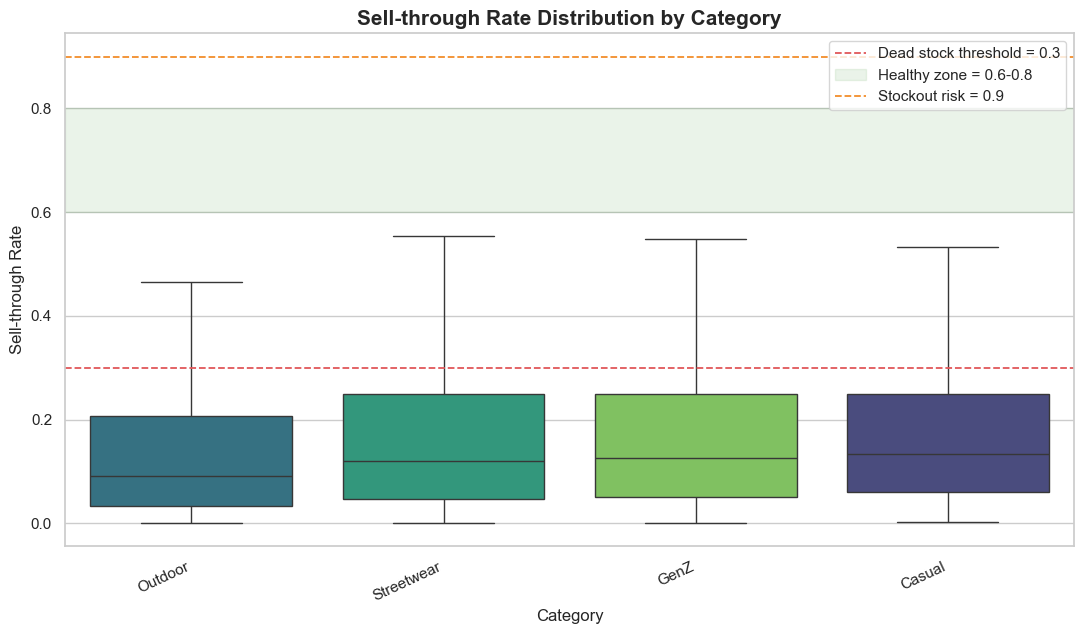

,category,avg_sell_through_rate,median_sell_through_rate
2,Outdoor,0.135084,0.0909
3,Streetwear,0.159754,0.1205
1,GenZ,0.167978,0.1250
0,Casual,0.168390,0.1333


In [ ]:
plot_df = inventory_diag.dropna(subset=["category", "sell_through_rate"]).copy()
category_order = category_diag.sort_values("avg_sell_through_rate")["category"]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.boxplot(
    data=plot_df,
    x="category",
    y="sell_through_rate",
    order=category_order,
    hue="category",
    palette="viridis",
    legend=False,
    showfliers=False,
    ax=ax
)

ax.axhline(0.3, color="#e15759", linestyle="--", linewidth=1.3, label="Dead stock threshold = 0.3")
ax.axhspan(0.6, 0.8, color="#59a14f", alpha=0.12, label="Healthy zone = 0.6-0.8")
ax.axhline(0.9, color="#f28e2b", linestyle="--", linewidth=1.3, label="Stockout risk = 0.9")
ax.set_title("Sell-through Rate Distribution by Category", fontsize=15, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Sell-through Rate")
ax.legend(loc="upper right")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

category_diag[["category", "avg_sell_through_rate", "median_sell_through_rate"]].sort_values("avg_sell_through_rate")


## Chart 33: Stock so với sales theo category

Grouped bar chart theo từng category để so sánh `avg_stock_on_hand` và `avg_units_sold`, từ đó xác định liệu tình trạng overstock xảy ra ở tất cả category hay chỉ tập trung ở một vài nhóm.

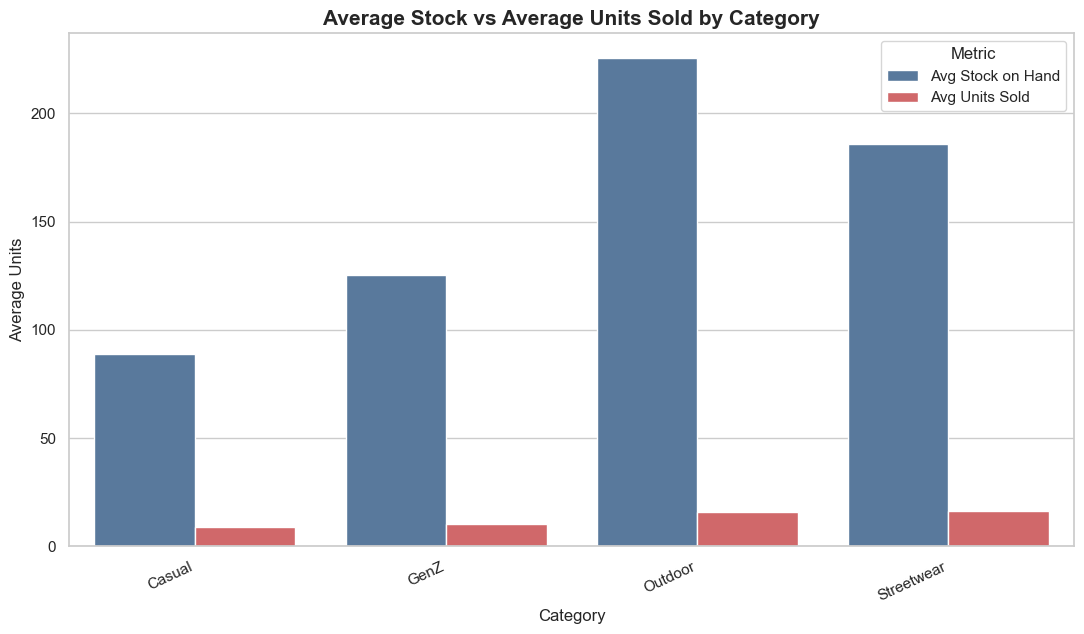

,category,avg_stock_on_hand,avg_units_sold,total_stock_on_hand,total_units_sold
2,Outdoor,225.648029,16.033729,4749891,337510
3,Streetwear,185.670342,16.488298,5759494,511467
1,GenZ,125.108472,10.418271,584757,48695
0,Casual,88.644590,8.907222,310522,31202


In [ ]:
plot_df = category_diag[["category", "avg_stock_on_hand", "avg_units_sold"]].copy()
plot_df = plot_df.melt(id_vars="category", var_name="metric", value_name="value")
plot_df["metric"] = plot_df["metric"].map({
    "avg_stock_on_hand": "Avg Stock on Hand",
    "avg_units_sold": "Avg Units Sold"
})

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(
    data=plot_df,
    x="category",
    y="value",
    hue="metric",
    palette={"Avg Stock on Hand": "#4e79a7", "Avg Units Sold": "#e15759"},
    ax=ax
)

ax.set_title("Average Stock vs Average Units Sold by Category", fontsize=15, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Average Units")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.legend(title="Metric")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

category_diag[["category", "avg_stock_on_hand", "avg_units_sold", "total_stock_on_hand", "total_units_sold"]].sort_values("avg_stock_on_hand", ascending=False)


## Chart 34: Overstock ratio so với stockout ratio

Stacked bar theo từng category để so sánh tỷ lệ % `overstock_flag` và % `stockout_flag`, từ đó xác định doanh nghiệp đang overbuy (nhập dư) hay dự báo nhu cầu bị lệch.

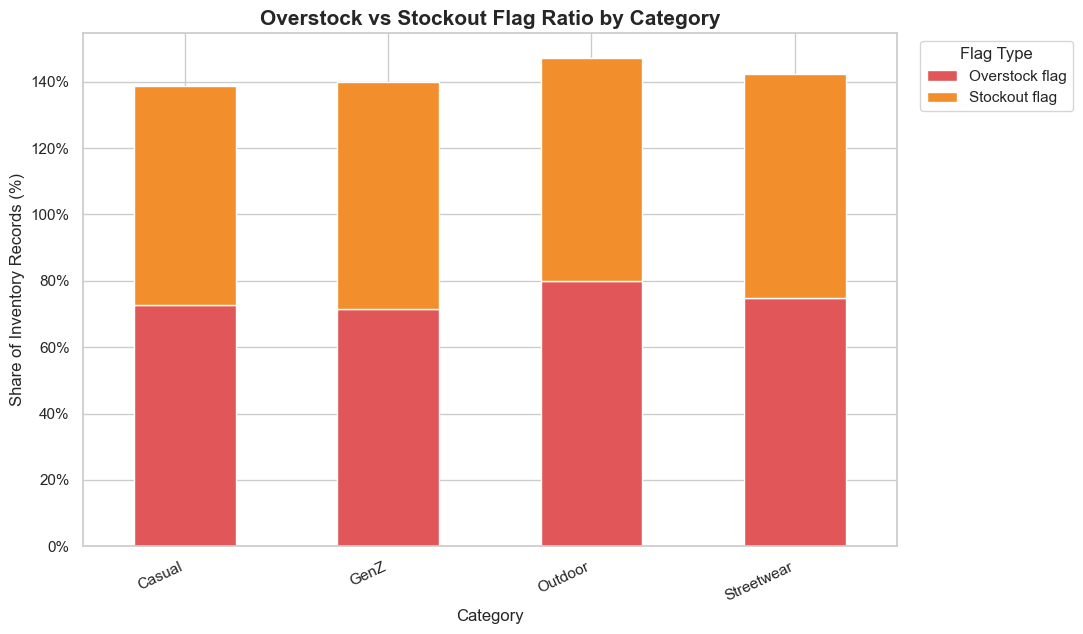

,category,overstock_rate_pct,stockout_rate_pct
2,Outdoor,79.852732,67.349169
3,Streetwear,74.925854,67.321083
0,Casual,72.594919,66.200400
1,GenZ,71.630295,68.292683


In [ ]:
flag_mix = category_diag[["category", "overstock_rate_pct", "stockout_rate_pct"]].copy()
plot_df = flag_mix.melt(id_vars="category", var_name="flag_type", value_name="rate_pct")
plot_df["flag_type"] = plot_df["flag_type"].map({
    "overstock_rate_pct": "Overstock flag",
    "stockout_rate_pct": "Stockout flag"
})

plot_wide = plot_df.pivot(index="category", columns="flag_type", values="rate_pct").fillna(0)
fig, ax = plt.subplots(figsize=(11, 6.5))
plot_wide.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#e15759", "#f28e2b"]
)

ax.set_title("Overstock vs Stockout Flag Ratio by Category", fontsize=15, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Share of Inventory Records (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
ax.legend(title="Flag Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

category_diag[["category", "overstock_rate_pct", "stockout_rate_pct"]].sort_values("overstock_rate_pct", ascending=False)


**Insight gợi ý:** Nếu `overstock_rate_pct` vượt xa `stockout_rate_pct`, doanh nghiệp đang nghiêng về overbuy. Nếu một category vừa có overstock cao vừa có stockout cao, forecasting có dấu hiệu lệch: có SKU dư quá nhiều, có SKU lại thiếu.

## Chart 35: Days of supply theo thời gian

Biểu đồ line chart theo tháng theo dõi hàng tồn kho đang được giữ trong bao lâu, và thêm histogram nhỏ để quan sát phân bố của DOS (Days of Supply).

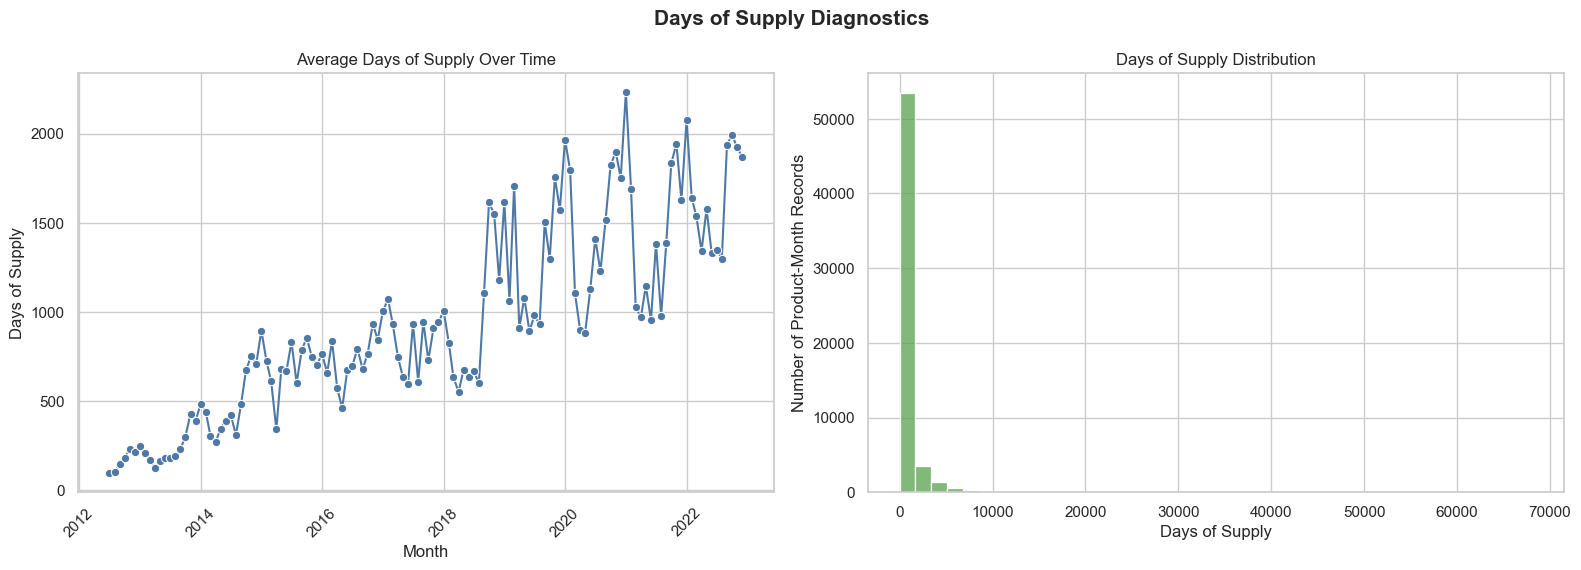

,month,avg_days_of_supply
114,2022-01-01,2078.484021
115,2022-02-01,1637.372770
116,2022-03-01,1535.092616
117,2022-04-01,1340.921169
118,2022-05-01,1576.831959
119,2022-06-01,1327.916379
120,2022-07-01,1347.887805
121,2022-08-01,1296.291323
122,2022-09-01,1937.058711
123,2022-10-01,1992.544254


In [ ]:
dos_monthly = (
    inventory_diag
    .groupby("month", as_index=False)
    .agg(avg_days_of_supply=("days_of_supply", "mean"))
    .sort_values("month")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
sns.lineplot(data=dos_monthly, x="month", y="avg_days_of_supply", marker="o", color="#4e79a7", ax=axes[0])
axes[0].set_title("Average Days of Supply Over Time")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Days of Supply")
axes[0].tick_params(axis="x", rotation=45)

sns.histplot(inventory_diag["days_of_supply"].dropna(), bins=40, color="#59a14f", edgecolor="white", ax=axes[1])
axes[1].set_title("Days of Supply Distribution")
axes[1].set_xlabel("Days of Supply")
axes[1].set_ylabel("Number of Product-Month Records")

fig.suptitle("Days of Supply Diagnostics", fontsize=15, weight="bold")
plt.tight_layout()
plt.show()

dos_monthly.tail(12)


## Chart 36: Fill rate so với sell-through rate

Biểu đồ sử dụng scatter plot theo từng category và theo tháng để phân biệt xem vấn đề đến từ nguồn cung (supply) hay do sản phẩm chưa phù hợp với thị trường (product-market fit).

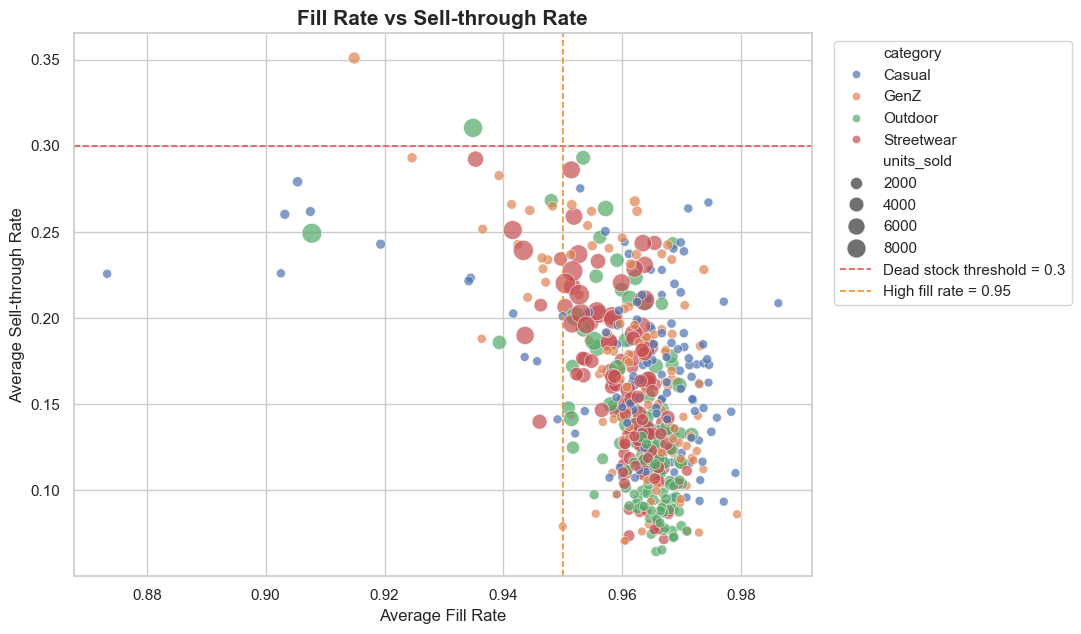

,month,category,stock_on_hand,units_sold,avg_sell_through_rate,avg_days_of_supply,avg_fill_rate,overstock_rate,stockout_rate,overstock_rate_pct,stockout_rate_pct
12,2012-10-01,Casual,559,127,0.208706,204.117647,0.986276,0.705882,0.294118,70.588235,29.411765
209,2016-11-01,GenZ,3933,171,0.086121,708.424138,0.979317,0.931034,0.482759,93.103448,48.275862
408,2021-01-01,Casual,3536,114,0.110069,965.202857,0.979054,0.800000,0.485714,80.000000,48.571429
176,2016-03-01,Casual,1717,267,0.145670,306.665000,0.978335,0.900000,0.450000,90.000000,45.000000
52,2013-08-01,Casual,811,195,0.209600,122.606250,0.977094,0.687500,0.562500,68.750000,56.250000
404,2020-12-01,Casual,3967,121,0.093459,1304.728125,0.977091,0.843750,0.531250,84.375000,53.125000
116,2014-12-01,Casual,1217,157,0.142211,346.300000,0.975928,0.833333,0.500000,83.333333,50.000000
240,2017-07-01,Casual,2505,344,0.134010,283.840000,0.975000,0.850000,0.500000,85.000000,50.000000
244,2017-08-01,Casual,2568,390,0.172962,198.223810,0.974605,0.714286,0.523810,71.428571,52.380952
24,2013-01-01,Casual,620,108,0.162576,211.488235,0.974524,0.823529,0.647059,82.352941,64.705882


In [ ]:
plot_df = category_monthly_diag.dropna(subset=["avg_fill_rate", "avg_sell_through_rate"]).copy()

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.scatterplot(
    data=plot_df,
    x="avg_fill_rate",
    y="avg_sell_through_rate",
    hue="category",
    size="units_sold",
    sizes=(40, 220),
    alpha=0.7,
    ax=ax
)

ax.axhline(0.3, color="#e15759", linestyle="--", linewidth=1.2, label="Dead stock threshold = 0.3")
ax.axvline(0.95, color="#f28e2b", linestyle="--", linewidth=1.2, label="High fill rate = 0.95")
ax.set_title("Fill Rate vs Sell-through Rate", fontsize=15, weight="bold")
ax.set_xlabel("Average Fill Rate")
ax.set_ylabel("Average Sell-through Rate")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plot_df.sort_values(["avg_fill_rate", "avg_sell_through_rate"], ascending=[False, True]).head(20)


## Chart 37: Inventory so với promo

Chart này sử dụng stacked bar chart để xem category nào bán phần lớn số lượng thông qua Promo so với Non-promo.

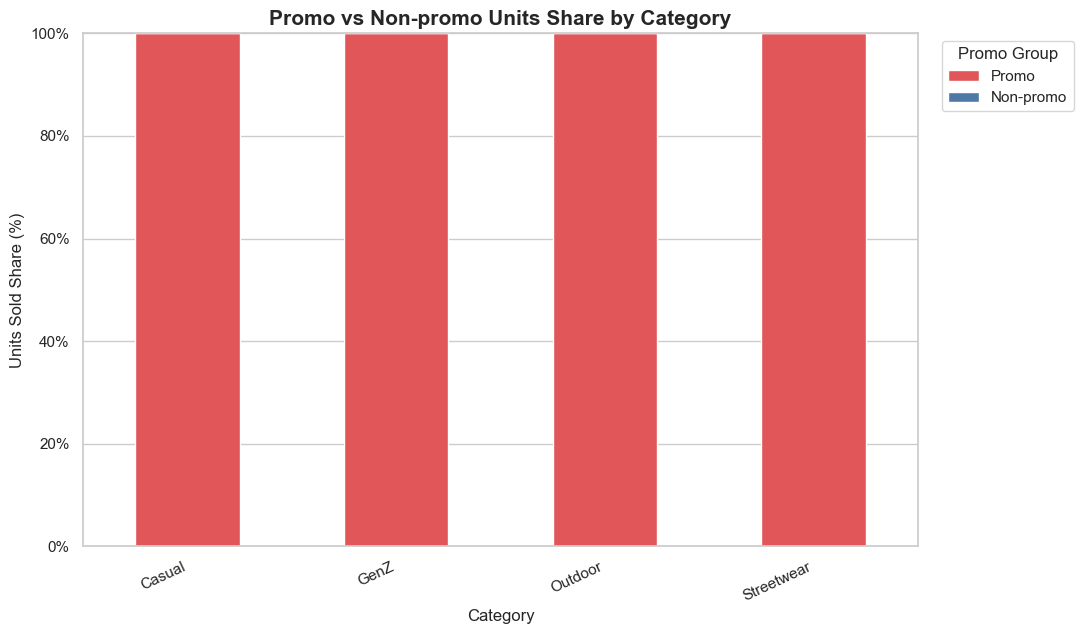

,category,promo_group,units_sold,units_share_pct
0,Casual,Promo,96271,100.0
1,GenZ,Promo,149824,100.0
2,Outdoor,Promo,1048546,100.0
3,Streetwear,Promo,1586192,100.0


In [ ]:
plot_wide = (
    promo_units_by_category
    .pivot(index="category", columns="promo_group", values="units_share_pct")
    .fillna(0)
)

for col in ["Promo", "Non-promo"]:
    if col not in plot_wide.columns:
        plot_wide[col] = 0

plot_wide = plot_wide[["Promo", "Non-promo"]]

fig, ax = plt.subplots(figsize=(11, 6.5))
plot_wide.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#e15759", "#4e79a7"]
)

ax.set_title("Promo vs Non-promo Units Share by Category", fontsize=15, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Units Sold Share (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
ax.legend(title="Promo Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

promo_units_by_category.sort_values(["category", "units_share_pct"], ascending=[True, False])


## Chart 38: Top dead stock SKU

Bar chart này dùng để tìm các SKU có `stock_on_hand` cao nhưng `sell_through_rate` thấp.

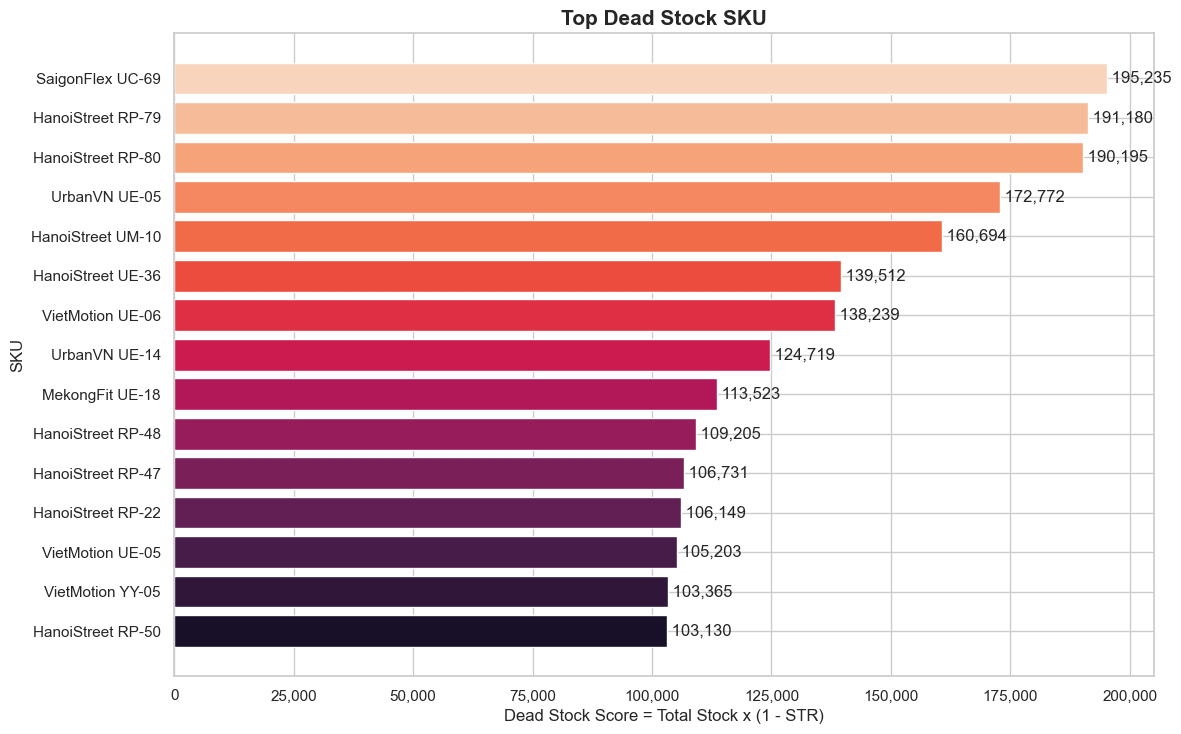

,product_id,product_name,category,total_stock_on_hand,avg_sell_through_rate,avg_days_of_supply,dead_stock_score
418,604,SaigonFlex UC-69,Streetwear,208932,0.065556,2493.050794,195235.346667
550,791,HanoiStreet RP-79,Outdoor,212593,0.100725,2024.527027,191179.522194
551,792,HanoiStreet RP-80,Outdoor,210741,0.097494,1979.324324,190195.081497
1403,2045,UrbanVN UE-05,Streetwear,187873,0.080381,2250.263200,172771.617962
574,826,HanoiStreet UM-10,Streetwear,170769,0.058998,1008.600000,160694.035593
610,927,HanoiStreet UE-36,Streetwear,151245,0.077574,1613.312821,139512.266077
1570,2332,VietMotion UE-06,Streetwear,150312,0.080317,1079.345238,138239.441200
1410,2054,UrbanVN UE-14,Streetwear,134582,0.073289,1979.098413,124718.634756
805,1182,MekongFit UE-18,Streetwear,125053,0.092199,702.634127,113523.212648
527,760,HanoiStreet RP-48,Outdoor,117864,0.073469,1875.211382,109204.637327


In [ ]:
top_dead_stock = dead_stock_sku.head(15).sort_values("dead_stock_score", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7.5))
bars = ax.barh(
    top_dead_stock["product_name"],
    top_dead_stock["dead_stock_score"],
    color=sns.color_palette("rocket", n_colors=len(top_dead_stock))
)

ax.set_title("Top Dead Stock SKU", fontsize=15, weight="bold")
ax.set_xlabel("Dead Stock Score = Total Stock x (1 - STR)")
ax.set_ylabel("SKU")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

for bar, value in zip(bars, top_dead_stock["dead_stock_score"]):
    ax.text(value, bar.get_y() + bar.get_height() / 2, f" {value:,.0f}", va="center")

plt.tight_layout()
plt.show()

dead_stock_sku[["product_id", "product_name", "category", "total_stock_on_hand", "avg_sell_through_rate", "avg_days_of_supply", "dead_stock_score"]].head(15)


## Chart 39: Top SKU theo sell-through và revenue

Biểu đồ này kết hợp tốc độ bán ra (`avg_sell_through_rate`) với `net_revenue` để tìm ra các SKU vừa quay vòng hàng nhanh vừa đóng góp doanh thu lớn.
Điểm xếp hạng được tính bằng trung bình percentile rank của sell-through và revenue.

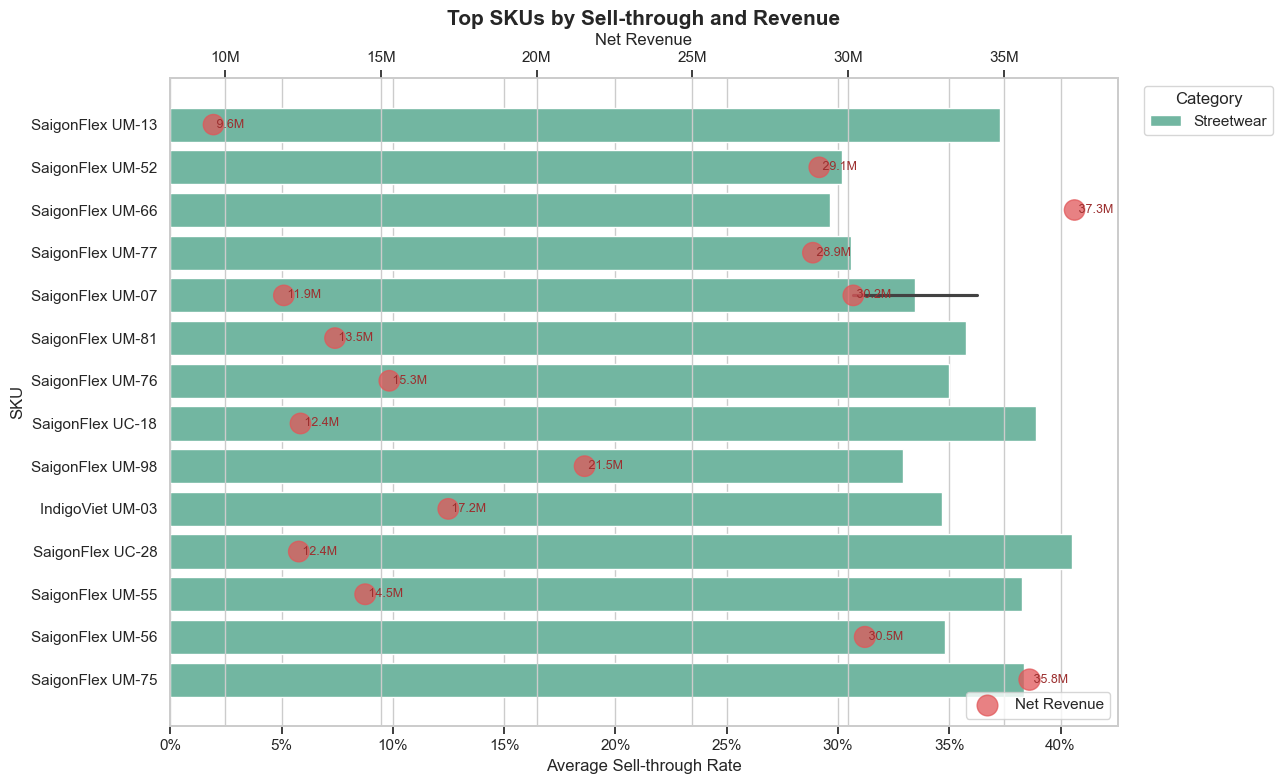

,product_id,product_name,category,avg_sell_through_rate,net_revenue,total_quantity_ordered,avg_stock_on_hand,avg_days_of_supply,combined_score
288,470,SaigonFlex UM-75,Streetwear,0.383407,35829237.26,3418,81.724138,59.193103,0.965528
275,451,SaigonFlex UM-56,Streetwear,0.348156,30541348.01,3356,128.333333,83.050000,0.944023
274,450,SaigonFlex UM-55,Streetwear,0.382564,14492162.63,831,30.071429,159.021429,0.915876
369,563,SaigonFlex UC-28,Streetwear,0.405356,12360541.93,1521,47.555556,62.927778,0.912397
99,201,IndigoViet UM-03,Streetwear,0.346941,17161268.24,1049,28.681818,108.172727,0.910500
308,493,SaigonFlex UM-98,Streetwear,0.329160,21538952.79,2132,73.750000,768.245000,0.909235
448,653,SaigonFlex UC-18,Streetwear,0.388961,12414618.53,1397,46.166667,63.727778,0.908918
289,471,SaigonFlex UM-76,Streetwear,0.349961,15266745.74,1589,60.611111,76.272222,0.906705
293,476,SaigonFlex UM-81,Streetwear,0.357544,13522270.93,669,27.555556,168.438889,0.903226
317,502,SaigonFlex UM-07,Streetwear,0.306890,30169600.86,2621,105.666667,978.819048,0.901328


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def resolve_data_path(relative_path):
    path = Path(relative_path)
    if path.exists():
        return path
    parent_path = Path("..") / relative_path
    if parent_path.exists():
        return parent_path
    raise FileNotFoundError(f"Cannot find {relative_path} from current notebook path")


inventory_path = resolve_data_path("data/interim/inventory.csv")
master_path = resolve_data_path("data/output/master_table.csv")

inventory = pd.read_csv(
    inventory_path,
    usecols=[
        "snapshot_date", "product_id", "product_name", "category",
        "stock_on_hand", "units_sold", "sell_through_rate", "days_of_supply"
    ]
)
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])

sku_sell_through = (
    inventory
    .dropna(subset=["product_id", "sell_through_rate"])
    .groupby(["product_id", "product_name", "category"], as_index=False)
    .agg(
        avg_sell_through_rate=("sell_through_rate", "mean"),
        total_units_sold_inventory=("units_sold", "sum"),
        avg_stock_on_hand=("stock_on_hand", "mean"),
        avg_days_of_supply=("days_of_supply", "mean")
    )
)

master = pd.read_csv(
    master_path,
    usecols=[
        "order_item_id", "product_id", "product_name", "category",
        "quantity", "line_revenue", "refund_amount", "order_status"
    ]
)

master = master.drop_duplicates(subset=["order_item_id"]).copy()
master["refund_amount"] = master["refund_amount"].fillna(0)
master["net_revenue"] = master["line_revenue"] - master["refund_amount"]

valid_statuses = ["paid", "shipped", "delivered", "returned"]
sku_revenue = (
    master[master["order_status"].isin(valid_statuses)]
    .groupby(["product_id", "product_name", "category"], as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        gross_revenue=("line_revenue", "sum"),
        total_quantity_ordered=("quantity", "sum"),
        order_item_count=("order_item_id", "nunique")
    )
)

sku_perf = sku_sell_through.merge(
    sku_revenue,
    on=["product_id", "product_name", "category"],
    how="inner",
    validate="one_to_one"
)

sku_perf["sell_through_rank_pct"] = sku_perf["avg_sell_through_rate"].rank(pct=True)
sku_perf["revenue_rank_pct"] = sku_perf["net_revenue"].rank(pct=True)
sku_perf["combined_score"] = (
    sku_perf["sell_through_rank_pct"] + sku_perf["revenue_rank_pct"]
) / 2

top_sku = (
    sku_perf
    .sort_values(["combined_score", "net_revenue"], ascending=False)
    .head(15)
    .sort_values("combined_score", ascending=True)
)

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(13, 8))

sns.barplot(
    data=top_sku,
    x="avg_sell_through_rate",
    y="product_name",
    hue="category",
    dodge=False,
    palette="Set2",
    ax=ax1
)

ax1.set_title("Top SKUs by Sell-through and Revenue", fontsize=15, weight="bold")
ax1.set_xlabel("Average Sell-through Rate")
ax1.set_ylabel("SKU")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax1.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")

ax2 = ax1.twiny()
ax2.scatter(
    top_sku["net_revenue"],
    top_sku["product_name"],
    s=top_sku["combined_score"] * 240,
    color="#e15759",
    alpha=0.75,
    label="Net Revenue"
)
ax2.set_xlabel("Net Revenue")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value/1_000_000:.0f}M"))
ax2.legend(loc="lower right")

for _, row in top_sku.iterrows():
    ax2.text(
        row["net_revenue"],
        row["product_name"],
        f" {row['net_revenue']/1_000_000:.1f}M",
        va="center",
        fontsize=9,
        color="#9c2f2f"
    )

plt.tight_layout()
plt.show()

columns_to_show = [
    "product_id", "product_name", "category",
    "avg_sell_through_rate", "net_revenue", "total_quantity_ordered",
    "avg_stock_on_hand", "avg_days_of_supply", "combined_score"
]

sku_perf.sort_values(["combined_score", "net_revenue"], ascending=False)[columns_to_show].head(15)


## Chart 40: Giá trị tồn kho theo aging bucket

Chart này ước tính giá trị tồn kho theo nhóm `Days of Supply` để nhìn bucket nào đang khóa vốn nhiều nhất. Inventory value được tính bằng `stock_on_hand * cogs` sau khi merge inventory với product cost.

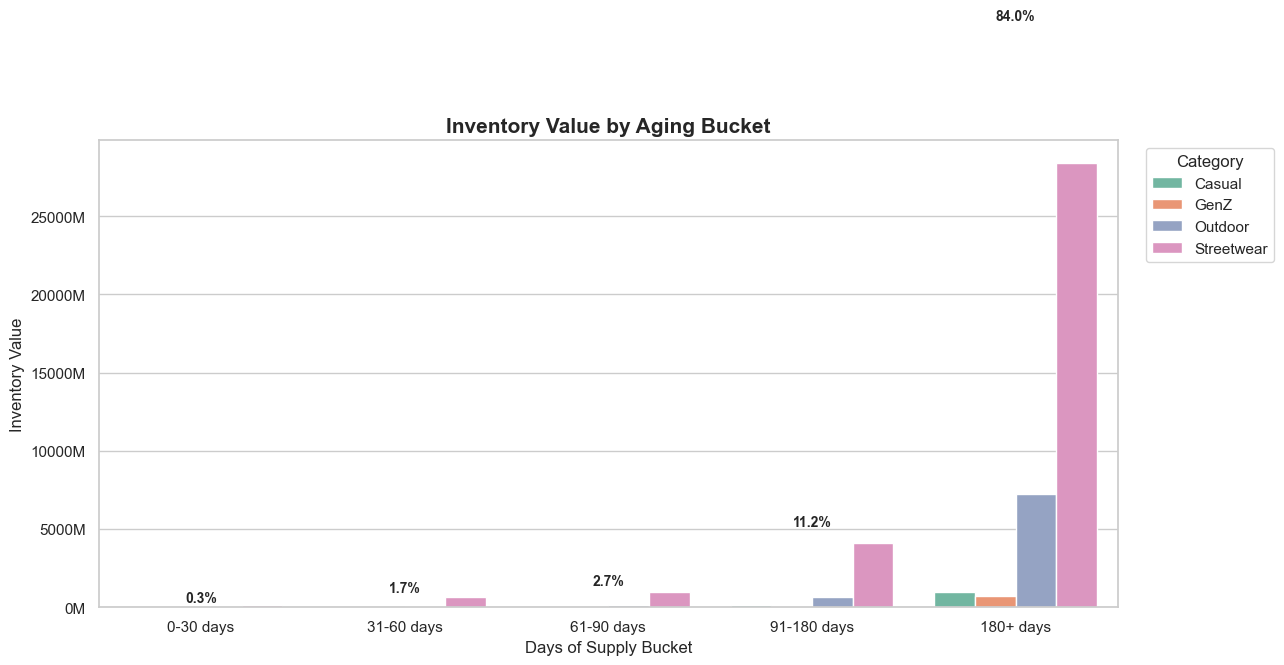

,aging_bucket,total_inventory_value,value_share_pct,sku_month_records,overstock_records
0,0-30 days,1.544693e+08,0.347359,2188,0
1,31-60 days,7.722154e+08,1.736503,4920,0
2,61-90 days,1.203487e+09,2.706315,7197,0
3,91-180 days,4.997272e+09,11.237510,11304,11304
4,180+ days,3.734212e+10,83.972312,34638,34638


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def resolve_data_path(relative_path):
    path = Path(relative_path)
    if path.exists():
        return path
    parent_path = Path("..") / relative_path
    if parent_path.exists():
        return parent_path
    raise FileNotFoundError(f"Cannot find {relative_path} from current notebook path")


inventory_path = resolve_data_path("data/interim/inventory.csv")
products_path = resolve_data_path("data/interim/products.csv")

inventory = pd.read_csv(
    inventory_path,
    usecols=[
        "snapshot_date", "product_id", "product_name", "category",
        "stock_on_hand", "days_of_supply", "overstock_flag"
    ]
)
products = pd.read_csv(products_path, usecols=["product_id", "cogs"])

inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])

inventory_value = inventory.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one"
)

inventory_value = inventory_value.dropna(subset=["cogs", "days_of_supply"]).copy()
inventory_value["inventory_value"] = inventory_value["stock_on_hand"] * inventory_value["cogs"]
inventory_value["aging_bucket"] = pd.cut(
    inventory_value["days_of_supply"],
    bins=[0, 30, 60, 90, 180, float("inf")],
    labels=["0-30 days", "31-60 days", "61-90 days", "91-180 days", "180+ days"],
    include_lowest=True
)

bucket_order = ["0-30 days", "31-60 days", "61-90 days", "91-180 days", "180+ days"]

aging_value = (
    inventory_value
    .groupby(["aging_bucket", "category"], observed=False, as_index=False)
    .agg(
        inventory_value=("inventory_value", "sum"),
        avg_stock_on_hand=("stock_on_hand", "mean"),
        sku_month_records=("product_id", "count"),
        overstock_records=("overstock_flag", "sum")
    )
)

aging_value["aging_bucket"] = pd.Categorical(
    aging_value["aging_bucket"],
    categories=bucket_order,
    ordered=True
)
aging_value = aging_value.sort_values("aging_bucket")

bucket_summary = (
    aging_value
    .groupby("aging_bucket", observed=False, as_index=False)
    .agg(total_inventory_value=("inventory_value", "sum"))
)
bucket_summary["value_share_pct"] = (
    bucket_summary["total_inventory_value"] / bucket_summary["total_inventory_value"].sum() * 100
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 7))

sns.barplot(
    data=aging_value,
    x="aging_bucket",
    y="inventory_value",
    hue="category",
    palette="Set2",
    ax=ax
)

ax.set_title("Inventory Value by Aging Bucket", fontsize=15, weight="bold")
ax.set_xlabel("Days of Supply Bucket")
ax.set_ylabel("Inventory Value")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value/1_000_000:.0f}M"))
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")

for idx, row in bucket_summary.iterrows():
    ax.text(
        idx,
        row["total_inventory_value"],
        f"{row['value_share_pct']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold"
    )

plt.tight_layout()
plt.show()

bucket_summary.merge(
    aging_value.groupby("aging_bucket", observed=False, as_index=False).agg(
        sku_month_records=("sku_month_records", "sum"),
        overstock_records=("overstock_records", "sum")
    ),
    on="aging_bucket",
    how="left"
)
